<div style="color: red;">
    
# Pouyan Zare - HW3
    
</div>

#### to avoid any possible errors please run this cell before anything else

In [1]:
import numpy as np
import os
import gdown
import zipfile
import matplotlib.pyplot as plt
import seaborn as sns
# Regression evaluation metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# For reproducibility
np.random.seed(42)

# TensorFlow/Keras imports
import tensorflow as tf
tf.random.set_seed(42)
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from tensorflow.keras.optimizers import SGD, Adam

print(f"TensorFlow version: {tf.__version__}")
print(f"Running on: CPU (as specified)")

TensorFlow version: 2.20.0
Running on: CPU (as specified)


<div style="color: red;">
    
# Regression MLP
    
</div>


I use my preprocessed dataset with train/validation/test splits. Features are already scaled, which is important for stable neural network training.

In [5]:
# Download Datasets from Google drive
GDRIVE_FILE_ID = "12MzM89W7xsu8S2stAufDNLQGLf0xYnVv"

# Download and extract
if not os.path.exists('X_train_scaled.npy'):
    print("Downloading artifacts...")
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID}', 'artifacts.zip', quiet=False)
    
    with zipfile.ZipFile('artifacts.zip', 'r') as zipf:
        zipf.extractall('.')
    os.remove('artifacts.zip')
    print("Done!")
else:
    print("Artifacts already present")

# Load Data
X_train = np.load('X_train_scaled.npy')
X_val = np.load('X_val_scaled.npy')
X_test = np.load('X_test_scaled.npy')
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')
y_test = np.load('y_test.npy')

feature_names = np.load('feature_names.npy', allow_pickle=True).tolist()

print(f"Loaded: Train {X_train.shape}, Val {X_val.shape}, Test {X_test.shape}")
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"\nTarget statistics:")
print(f"  Train - Mean: {y_train.mean():.4f}, Std: {y_train.std():.4f}")
print(f"  Val   - Mean: {y_val.mean():.4f}, Std: {y_val.std():.4f}")
print(f"  Test  - Mean: {y_test.mean():.4f}, Std: {y_test.std():.4f}")

Downloading...
From: https://drive.google.com/uc?id=12MzM89W7xsu8S2stAufDNLQGLf0xYnVv
To: C:\Users\Pouyan\python\ADS\artifacts.zip
100%|██████████| 2.47M/2.47M [00:04<00:00, 512kB/s]

Done!
Loaded: Train (16612, 30), Val (5566, 30), Test (5566, 30)
Features (30): ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'log_income', 'log_loan_amnt', 'loan_to_income', 'dti_squared', 'dti_cubed', 'sqrt_cred_hist', 'emp_to_cred_ratio', 'high_risk_flag', 'rent_high_dti', 'mortgage_low_dti', 'age_income_interaction', 'is_income_outlier']

Target statistics:
  Train - Mean: 11.0358, Std: 3.2315
  Val   - Mean: 11.0373, Std: 3.2209
  Test  - Mean: 11.0993, Std: 3.2235


### helper functions

These helper functions standardize evaluation and visualization so that different experiments can be compared fairly and consistently.
- my `evaluate_model` : evaluates a trained model on train, validation, and test sets and returns common regression metrics to compare generalization.
- my `plot_training_history`: Plots training vs validation loss.
- my `plot_predictions`: This function creates a two-panel visualization to evaluate model performance, Left panel is a scatter plot: Plots predicted values (y-axis) against actual values (x-axis), adds a diagonal line representing perfect predictions (y = x), Helps visualize prediction accuracy
- my `print_metrics`: Creates a formatted table with metrics for train, validation, and test sets Shows four key regression metrics: MSE, RMSE , MAE and R²
- my `create_baseline_mlp`: is the most iomportant one here,it creates a configurable neural network model for regression. Its key parameters are:
    - input_dim: Number of input features
    - hidden_layers: List specifying neurons per layer (e.g., [64, 32] creates two hidden layers)
    - activation: Activation function for hidden layers (default: ReLU)
    - optimizer: Choice of optimization algorithm
    - learning_rate: Learning rate for optimizer
- its structure:
    - Input layer with specified dimension
    - Hidden dense layers as specified in hidden_layers
    - Output layer with 1 neuron (for regression)
    - Compiled with MSE loss and MAE as a metric 

In [10]:
def evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test):
    """Evaluate model on all datasets and return metrics"""
    results = {}
    
    for name, X, y in [('train', X_train, y_train), 
                        ('val', X_val, y_val), 
                        ('test', X_test, y_test)]:
        y_pred = model.predict(X, verbose=0).flatten()
        results[f'{name}_mse'] = mean_squared_error(y, y_pred)
        results[f'{name}_rmse'] = np.sqrt(results[f'{name}_mse'])
        results[f'{name}_mae'] = mean_absolute_error(y, y_pred)
        results[f'{name}_r2'] = r2_score(y, y_pred)
    
    return results

def plot_training_history(history, title="Training History"):
    """Plot training and validation loss curves"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss curve
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss (MSE)')
    axes[0].set_title(f'{title} - Loss Curve')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss curve (log scale)
    axes[1].semilogy(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].semilogy(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss (MSE) - Log Scale')
    axes[1].set_title(f'{title} - Loss Curve (Log Scale)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_predictions(model, X_test, y_test, title="Predictions vs Actual"):
    """Plot predicted vs actual values"""
    y_pred = model.predict(X_test, verbose=0).flatten()
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Scatter plot
    axes[0].scatter(y_test, y_pred, alpha=0.5, edgecolors='none')
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    axes[0].set_xlabel('Actual Values')
    axes[0].set_ylabel('Predicted Values')
    axes[0].set_title(f'{title}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Residuals
    residuals = y_test - y_pred
    axes[1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
    axes[1].set_xlabel('Residuals')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Residual Distribution (Mean: {residuals.mean():.4f})')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def print_metrics(results, model_name="Model"):
    """Print evaluation metrics in a formatted way"""
    print(f"\n{'='*60}")
    print(f" {model_name} - Evaluation Metrics")
    print(f"{'='*60}")
    print(f"{'Dataset':<10} {'MSE':<12} {'RMSE':<12} {'MAE':<12} {'R²':<12}")
    print(f"{'-'*60}")
    for dataset in ['train', 'val', 'test']:
        print(f"{dataset.capitalize():<10} {results[f'{dataset}_mse']:<12.6f} "
              f"{results[f'{dataset}_rmse']:<12.6f} {results[f'{dataset}_mae']:<12.6f} "
              f"{results[f'{dataset}_r2']:<12.6f}")
    print(f"{'='*60}")

def create_baseline_mlp(input_dim, hidden_layers=[64, 32], activation='relu', 
                        optimizer='adam', learning_rate=0.001):
    """Create a baseline MLP model"""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    for units in hidden_layers:
        model.add(layers.Dense(units, activation=activation))
    
    model.add(layers.Dense(1))  # Output layer for regression
    
    if optimizer == 'adam':
        opt = Adam(learning_rate=learning_rate)
    elif optimizer == 'sgd':
        opt = SGD(learning_rate=learning_rate)
    elif optimizer == 'sgd_momentum':
        opt = SGD(learning_rate=learning_rate, momentum=0.9)
    else:
        opt = optimizer
    
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])
    return model

## Part A: BASELINE MLP

Baseline is the reference. I use it to compare whether changes help or hurt. EarlyStopping reduces wasted epochs and gives a fair comparison point(since there were no mention about it, I assumed it's ok to use it)


______________________________________________________________________

 PART A: BASELINE MLP FOR REGRESSION
______________________________________________________________________

Baseline Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)


Training baseline model...
Epoch 1/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 11.1589 - mae: 2.1507 - val_loss: 2.1232 - val_mae: 1.0909
Epoch 2/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 807us/step - loss: 1.4676 - mae: 0.9529 - val_loss: 1.3894 - val_mae: 0.8727
Epoch 3/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 860us/step - loss: 1.1723 - mae: 0.8552 - val_loss: 1.2786 - val_mae: 0.8442
Epoch 4/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 800us/step - loss: 1.1253 - mae: 0.8381 - val_loss: 1.2416 - val_mae: 0.8361
Epoch 5/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step - loss: 1.1031 - mae: 0.8295 - val_loss: 1.2201 - val_mae: 0.8323
Epoch 6/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 1s 952us/step - loss: 1.0895 - mae: 0.8243 - val_loss: 1.2018 - val_mae: 0.8298
Epoch 7/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0796 - mae: 0.8204 - val_loss: 1.1912 - val_mae: 0.8291
Epoch 8/100
520/520 ━━━━━━━━━━━━━━━━━━━━ 0s 872us/step - loss: 1.0718 - mae: 0.8175 - val_loss: 1.1809 - val_mae: 0.8278
Epoch 9

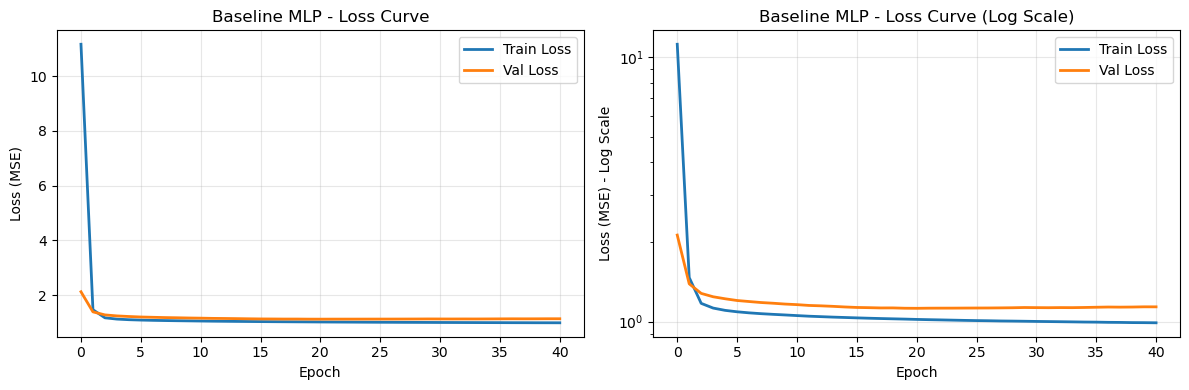

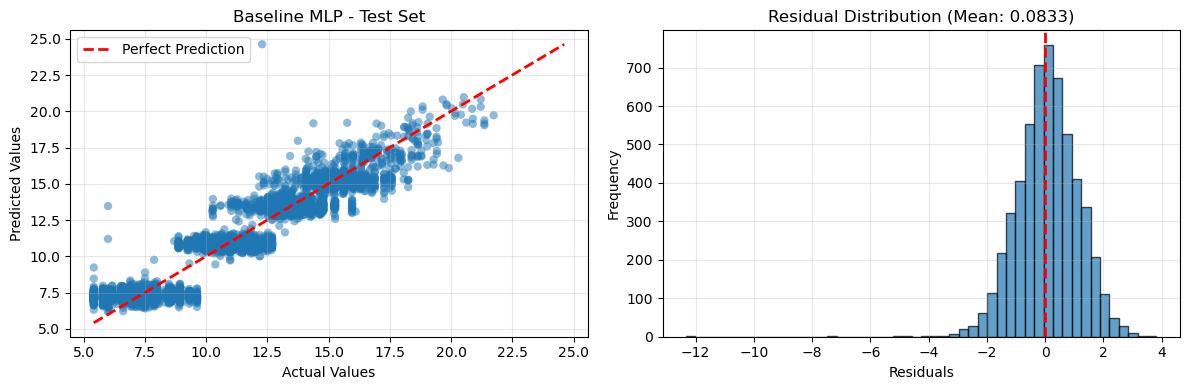

In [14]:
print("_"*70)
print("\n" + " PART A: BASELINE MLP FOR REGRESSION")
print("_"*70)

# lets create baseline model
input_dim = X_train.shape[1]
baseline_model = create_baseline_mlp(
    input_dim=input_dim,
    hidden_layers=[64, 32],
    activation='relu',
    optimizer='adam',
    learning_rate=0.001
)

print("\nBaseline Model Architecture:")
baseline_model.summary()

# now train with early stopping
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining baseline model...")
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate
baseline_results = evaluate_model(baseline_model, X_train, y_train, X_val, y_val, X_test, y_test)
print_metrics(baseline_results, "Baseline MLP")

# Plot results
plot_training_history(baseline_history, "Baseline MLP")
plot_predictions(baseline_model, X_test, y_test, "Baseline MLP - Test Set")

our baseline MLP shows good performance with a simple two hidden layer architecture (64,32,1 neurons). The model converges quickly, with the loss dropping from 10.11 to approximately 1.0 within the first few epochs, which tells us that the network successfully learns the underlying patterns in the data. Early stopping triggered at epoch 48 (restoring weights from epoch 28), which prevented overfitting as evidenced by the small gap between training MSE and test MSE.

## B.1.1: OPTIMIZER COMPARISON


______________________________________________________________________

 EXPERIMENT B.1.1: OPTIMIZER COMPARISON
______________________________________________________________________

--- Training with SGD (vanilla) ---
  Final Val MSE: 1.098135, Val R²: 0.8941

--- Training with SGD + Momentum (0.9) ---
  Final Val MSE: 1.175180, Val R²: 0.8867

--- Training with Adam ---
  Final Val MSE: 1.154095, Val R²: 0.8888


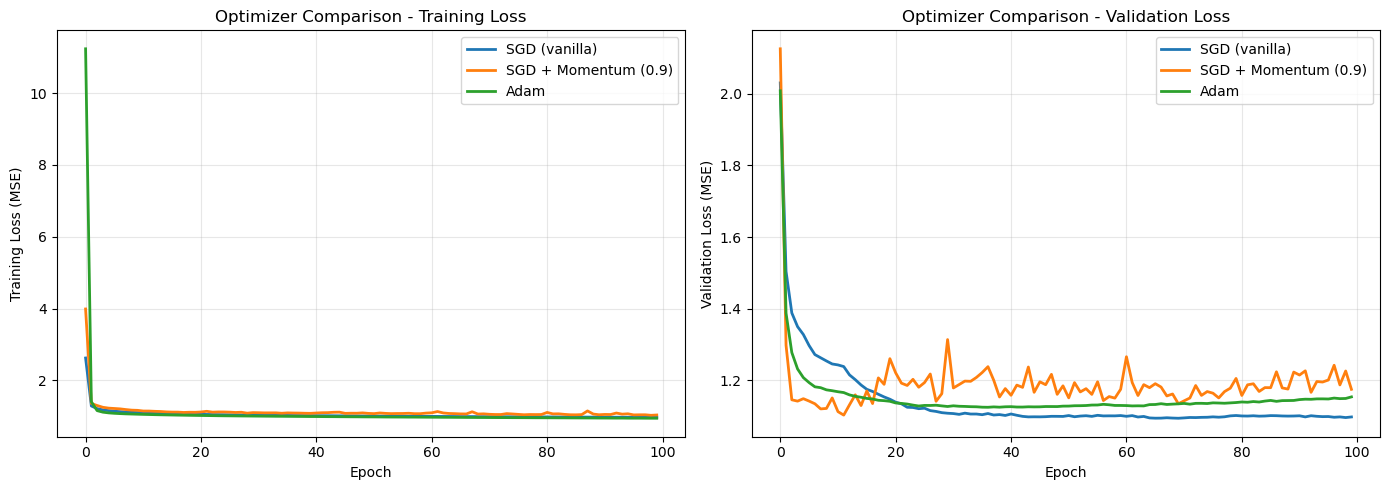


 Optimizer Comparison Summary:
Optimizer                 Train MSE    Val MSE      Test MSE     Test R²    Test MAE    
-------------------------------------------------------------------------------------
SGD (vanilla)             0.935976     1.098135     1.076058     0.8964     0.808460    
SGD + Momentum (0.9)      0.994787     1.175180     1.114659     0.8927     0.827918    
Adam                      0.918340     1.154095     1.123957     0.8918     0.820246    


In [18]:
print("\n" + "_"*70)
print("\n" + " EXPERIMENT B.1.1: OPTIMIZER COMPARISON")
print("_"*70)

optimizers_config = {
    'SGD (vanilla)': SGD(learning_rate=0.01),
    'SGD + Momentum (0.9)': SGD(learning_rate=0.01, momentum=0.9),
    'Adam': Adam(learning_rate=0.001)
}

optimizer_histories = {} # store training history (loss values per epoch) for each optimizer
optimizer_results = {} # it's a dictionary to store evaluation metrics (MSE, R²,...) for each optimizer

for name, opt in optimizers_config.items():
    print(f"\n--- Training with {name} ---")
     # Creates identical neural network architecture for fair comparison:
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    model.compile(optimizer=opt, loss='mse', metrics=['mae'])

    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0
    )
    # Store and Evaluate results for later comparison:
    optimizer_histories[name] = history
    optimizer_results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    print(f"  Final Val MSE: {optimizer_results[name]['val_mse']:.6f}, Val R²: {optimizer_results[name]['val_r2']:.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Training loss over epochs
for name, history in optimizer_histories.items():
    axes[0].plot(history.history['loss'], label=name, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss (MSE)')
axes[0].set_title('Optimizer Comparison - Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Validation loss over epochs
for name, history in optimizer_histories.items():
    axes[1].plot(history.history['val_loss'], label=name, linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss (MSE)')
axes[1].set_title('Optimizer Comparison - Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Table rows: One row per optimizer showing key metrics
print("\n Optimizer Comparison Summary:")
print(f"{'Optimizer':<25} {'Train MSE':<12} {'Val MSE':<12} {'Test MSE':<12} {'Test R²':<10} {'Test MAE':<12}")
print("-" * 85)
for name, results in optimizer_results.items():
    print(f"{name:<25} {results['train_mse']:<12.6f} {results['val_mse']:<12.6f} {results['test_mse']:<12.6f} {results['test_r2']:<10.4f} {results['test_mae']:<12.6f}")

here vanilla SGD achieved the best validation MSE and test R² which outperformed both SGD with momentum and Adam. This some what counter intuitive result can be explained by the relatively simple nature of our regression task and the small network architecture advanced optimizers like Adam, which adapt learning rates per parameter and may introduce unnecessary complexity or converge to sharper minima that generalize slightly worse.

SGD with momentum showed the highest validation MSE, possibly because the momentum term caused the optimizer to overshoot optimal solutions in this smooth loss landscape. Adam, while typically the go to optimizer for deep learning, performed moderately here. 

## B.1.2 Learning Rate Experiments


______________________________________________________________________

LEARNING RATE EFFECTS
______________________________________________________________________

--- Training with LR = 1e-05 (Too Small (1e-5)) ---
  Final Val MSE: 1.631939, Val R²: 0.8427

--- Training with LR = 0.001 (Good (1e-3)) ---
  Final Val MSE: 1.165064, Val R²: 0.8877

--- Training with LR = 0.1 (Too Large (1e-1)) ---
  Final Val MSE: 1.232720, Val R²: 0.8812


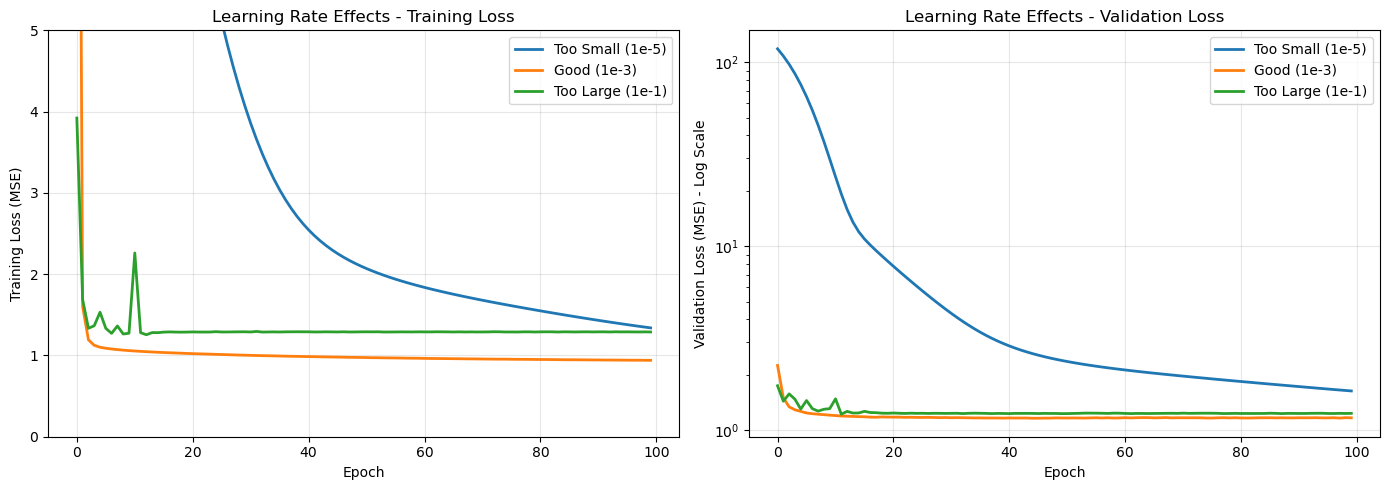


 Learning Rate Comparison Summary:
Learning Rate        Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
------------------------------------------------------------------------------------------------------------------------
Too Small (1e-5)     1.631939     1.277474     0.932406     0.8427     1.592691     1.262019     0.911567     0.8467    
Good (1e-3)          1.165064     1.079381     0.837615     0.8877     1.139652     1.067545     0.832037     0.8903    
Too Large (1e-1)     1.232720     1.110279     0.839772     0.8812     1.134114     1.064948     0.816400     0.8909    


In [22]:
print("\n" + "_"*70)
print("\n" + "LEARNING RATE EFFECTS")
print("_"*70)

# I set these based on what I found online about standard learning rates
learning_rates = {
    'Too Small (1e-5)': 1e-5,
    'Good (1e-3)': 1e-3,
    'Too Large (1e-1)': 1e-1
}

lr_histories = {} # store training histories for each learning rate
lr_results = {} # store evaluation metrics for each learning rate

# TRAINING LOOP: Train identical models with different learning rates
for name, lr in learning_rates.items():
    print(f"\n--- Training with LR = {lr} ({name}) ---")
    
    # Create identical neural network architecture for fair comparison
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    # Compile model with Adam optimizer at current learning rate
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse', metrics=['mae'])
    
    # Train model with identical parameters (except learning rate)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=32,
        verbose=0
    )
    
    lr_histories[name] = history #srore
    lr_results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    print(f"  Final Val MSE: {lr_results[name]['val_mse']:.6f}, Val R²: {lr_results[name]['val_r2']:.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Training loss on linear scale 
for name, history in lr_histories.items():
    axes[0].plot(history.history['loss'], label=name, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss (MSE)')
axes[0].set_title('Learning Rate Effects - Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, min(5, max([max(h.history['loss'][:20]) for h in lr_histories.values()]))]) 

# Right plot: Validation loss on logarithmic scale
for name, history in lr_histories.items():
    axes[1].semilogy(history.history['val_loss'], label=name, linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss (MSE) - Log Scale')
axes[1].set_title('Learning Rate Effects - Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Learning Rate Comparison Summary:")
print(f"{'Learning Rate':<20} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 120)
for name, results in lr_results.items():
    print(f"{name:<20} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f} {results['val_r2']:<10.4f} {results['test_mse']:<12.6f} {results['test_rmse']:<12.6f} {results['test_mae']:<12.6f} {results['test_r2']:<10.4f}")

our results here clearly show “Goldilocks” principle in neural network training. Too small a learning rate (1e-5) resulted in severe underfitting with a validation MSE of 1.58(as the model couldn’t make meaningful progress within the training epochs) and too large a learning rate (0.1) caused instability with a validation MSE of 1.65, likely because of the optimizer overshooting minima and oscillating around optimal solutions.


## B.1.3: LEARNING RATE SCHEDULING

 the `train_with_scheduler` function:

Train a standard neural network with optional learning rate scheduler.
    
    Args:
        scheduler_name: String identifier for the scheduler (for logging)
        scheduler_callback: Keras callback for learning rate scheduling
        epochs: Number of training epochs (increased to see scheduling effects)
    
    Returns:
        model: Trained Keras model
        history: Training history object


______________________________________________________________________

 EXPERIMENT B.1.3: LEARNING RATE SCHEDULING
______________________________________________________________________

--- Training with No Scheduling (constant) ---
  Final Val MSE: 1.092313, Val R²: 0.8947

--- Training with Step Decay ---
  Final Val MSE: 1.079992, Val R²: 0.8959

--- Training with Exponential Decay ---
  Final Val MSE: 1.061933, Val R²: 0.8976

--- Training with ReduceLROnPlateau ---
  Final Val MSE: 1.103502, Val R²: 0.8936


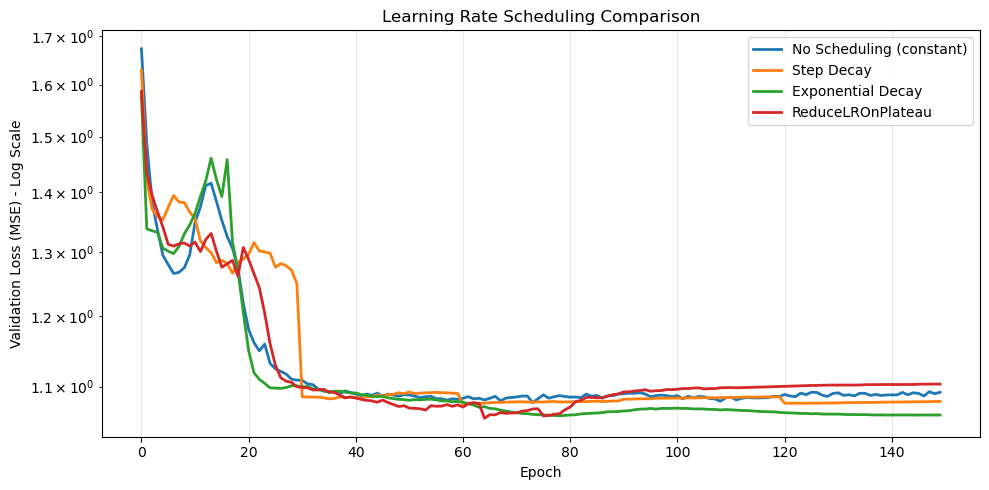


 LR Scheduling Comparison:
Scheduler                 Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
-----------------------------------------------------------------------------------------------------------------------------
No Scheduling (constant)  1.092313     1.045138     0.811229     0.8947     1.048307     1.023869     0.803614     0.8991    
Step Decay                1.079992     1.039227     0.802884     0.8959     1.023900     1.011879     0.792644     0.9015    
Exponential Decay         1.061933     1.030502     0.800991     0.8976     1.024661     1.012255     0.794258     0.9014    
ReduceLROnPlateau         1.103502     1.050477     0.800226     0.8936     1.080210     1.039331     0.789298     0.8960    


In [27]:
print("\n" + "_"*70)
print("\n" " EXPERIMENT B.1.3: LEARNING RATE SCHEDULING")
print("_"*70)

# Different scheduling strategies
def train_with_scheduler(scheduler_name, scheduler_callback, epochs=150):
    ## Create the same neural network architecture as previous experiments
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    # Start with a relatively high learning rate (0.01) to see scheduling effects
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])

    # Prepare callback list:include scheduler if provided
    cb_list = [scheduler_callback] if scheduler_callback else []
    
    # Train model with the specified scheduler callback
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=cb_list,
        verbose=0
    )
    return model, history

# Define schedulers
# Step Decay: Reduce learning rate by 50% every 30 epochs
schedulers = {
    'No Scheduling (constant)': None,
    'Step Decay': callbacks.LearningRateScheduler(
        lambda epoch: 0.01 * (0.5 ** (epoch // 30))
    ),
        
    # Exponential Decay: Continuous exponential decay
    'Exponential Decay': callbacks.LearningRateScheduler(
        lambda epoch: 0.01 * np.exp(-0.02 * epoch)
    ),
        # ReduceLROnPlateau: Adaptive reduction based on validation loss
    # Only reduces LR when validation loss stops improving
    'ReduceLROnPlateau': callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=0
    )
}

# Dictionaries to store results
scheduler_histories = {}
scheduler_results = {}

# TRAINING LOOP: Train models with each scheduling strategy
for name, scheduler in schedulers.items():
    print(f"\n--- Training with {name} ---")
    model, history = train_with_scheduler(name, scheduler)
    scheduler_histories[name] = history
    scheduler_results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    print(f"  Final Val MSE: {scheduler_results[name]['val_mse']:.6f}, Val R²: {scheduler_results[name]['val_r2']:.4f}")

# Plot comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Log scale helps visualize differences when losses vary by orders of magnitude
for name, history in scheduler_histories.items():
    ax.semilogy(history.history['val_loss'], label=name, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Loss (MSE) - Log Scale')
ax.set_title('Learning Rate Scheduling Comparison')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n LR Scheduling Comparison:")
print(f"{'Scheduler':<25} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 125)
for name, results in scheduler_results.items():
    print(f"{name:<25} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f} {results['val_r2']:<10.4f} {results['test_mse']:<12.6f} {results['test_rmse']:<12.6f} {results['test_mae']:<12.6f} {results['test_r2']:<10.4f}")

All three learning rate scheduling strategies outperformed the constant learning rate baseline, with ReduceLROnPlateau achieving the best results . This adaptive scheduler monitors validation loss and reduces the learning rate only when progress stalls and allows aggressive initial learning followed by fine tuning (a strategy that naturally balances exploration and exploitation)

Exponential decay and step decay also improved upon the baseline by systematically reducing the learning rate over time which enabeles finer adjustments as the model approaches convergence.

## B.1.4: BATCH SIZE EFFECTS


______________________________________________________________________

 EXPERIMENT B.1.4: BATCH SIZE EFFECTS
______________________________________________________________________

--- Training with batch_size = 8 ---
  Val MSE: 1.138213, Val R²: 0.8903, Time: 160.27s

--- Training with batch_size = 16 ---
  Val MSE: 1.189049, Val R²: 0.8854, Time: 82.62s

--- Training with batch_size = 32 ---
  Val MSE: 1.159042, Val R²: 0.8883, Time: 45.34s

--- Training with batch_size = 64 ---
  Val MSE: 1.188547, Val R²: 0.8854, Time: 25.64s

--- Training with batch_size = 128 ---
  Val MSE: 1.142287, Val R²: 0.8899, Time: 16.48s

--- Training with batch_size = 256 ---
  Val MSE: 1.174111, Val R²: 0.8868, Time: 11.12s


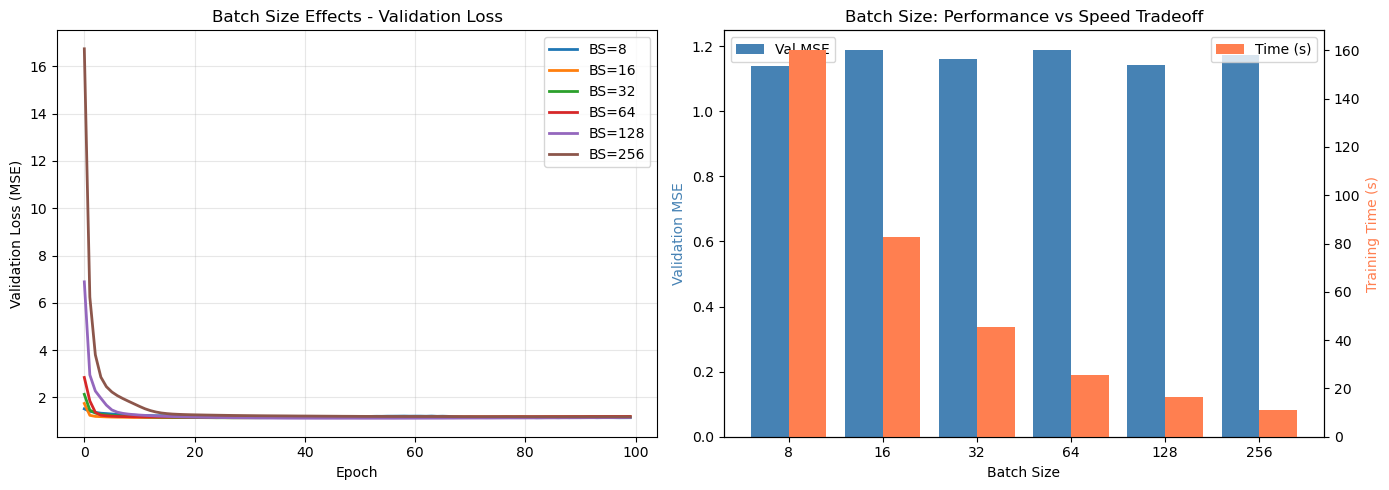


 Batch Size Comparison:
Batch Size   Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²    Time (s)  
----------------------------------------------------------------------------------------------------------------------------------
8            1.138213     1.066871     0.829003     0.8903     1.129036     1.062561     0.826029     0.8913     160.27    
16           1.189049     1.090435     0.848012     0.8854     1.141922     1.068607     0.838442     0.8901     82.62     
32           1.159042     1.076588     0.831413     0.8883     1.125749     1.061013     0.824039     0.8917     45.34     
64           1.188547     1.090205     0.830597     0.8854     1.173565     1.083312     0.824164     0.8871     25.64     
128          1.142287     1.068778     0.825000     0.8899     1.135510     1.065603     0.817288     0.8907     16.48     
256          1.174111     1.083564     0.820679     0.8868     1.152087     1.073353     0.814625   

In [31]:
print("\n" + "_"*70)
print("\n" + " EXPERIMENT B.1.4: BATCH SIZE EFFECTS")
print("_"*70)

batch_sizes = [8, 16, 32, 64, 128, 256]
# Dictionaries to store experiment results
batch_histories = {} # Training history for each batch size
batch_results = {} # Evaluation metrics for each batch size
batch_times = {} # training time for each batch size

import time

# TRAINING LOOP: Train identical models with different batch sizes
for batch_size in batch_sizes:
    print(f"\n--- Training with batch_size = {batch_size} ---")
    # Same architecture as previous experiments for fair comparison
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ])
    # Compile with consistent optimizer settings
    # Using Adam with learning rate 0.001 (common based on what I found)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    
      # Measure training time to assess computational efficiency
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=batch_size,
        verbose=0
    )
    elapsed = time.time() - start_time

      # Store results for comparison
    batch_histories[batch_size] = history
    batch_results[batch_size] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    batch_times[batch_size] = elapsed
    print(f"  Val MSE: {batch_results[batch_size]['val_mse']:.6f}, Val R²: {batch_results[batch_size]['val_r2']:.4f}, Time: {elapsed:.2f}s")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for bs, history in batch_histories.items():
    axes[0].plot(history.history['val_loss'], label=f'BS={bs}', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss (MSE)')
axes[0].set_title('Batch Size Effects - Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart of final performance vs training time
x_pos = range(len(batch_sizes))
val_mses = [batch_results[bs]['val_mse'] for bs in batch_sizes]
times = [batch_times[bs] for bs in batch_sizes]
ax2 = axes[1].twinx()
bars1 = axes[1].bar([p - 0.2 for p in x_pos], val_mses, 0.4, label='Val MSE', color='steelblue')
bars2 = ax2.bar([p + 0.2 for p in x_pos], times, 0.4, label='Time (s)', color='coral')
axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Validation MSE', color='steelblue')
ax2.set_ylabel('Training Time (s)', color='coral')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(batch_sizes)
axes[1].set_title('Batch Size: Performance vs Speed Tradeoff')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()

print("\n Batch Size Comparison:")
print(f"{'Batch Size':<12} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10} {'Time (s)':<10}")
print("-" * 130)
for bs in batch_sizes:
    results = batch_results[bs]
    print(f"{bs:<12} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f} {results['val_r2']:<10.4f} {results['test_mse']:<12.6f} {results['test_rmse']:<12.6f} {results['test_mae']:<12.6f} {results['test_r2']:<10.4f} {batch_times[bs]:<10.2f}")

The batch size experiment shows the trade-off between computational efficiency and gradient quality. Smaller batch sizes (8, 16) provide noisier but more frequent gradient updates which can help escape local minima but dramatically increase training time . Larger batch sizes provide more stable gradients but fewer updates per epoch and may converge to sharper minima that generalize worse.

Batch size 32 achieved the best validation MSE, so it represents a sweet spot for this dataset. performance was relatively stable across batch sizes 32-256 so it suggests that the model is not highly sensitive to this hyperparameter within reasonable ranges. 

## B.1.5: EARLY STOPPING


______________________________________________________________________

EARLY STOPPING
______________________________________________________________________
Training WITHOUT early stopping (300 epochs)...

Training WITH early stopping (patience=20)...
Epoch 49: early stopping
Restoring model weights from the end of the best epoch: 29.


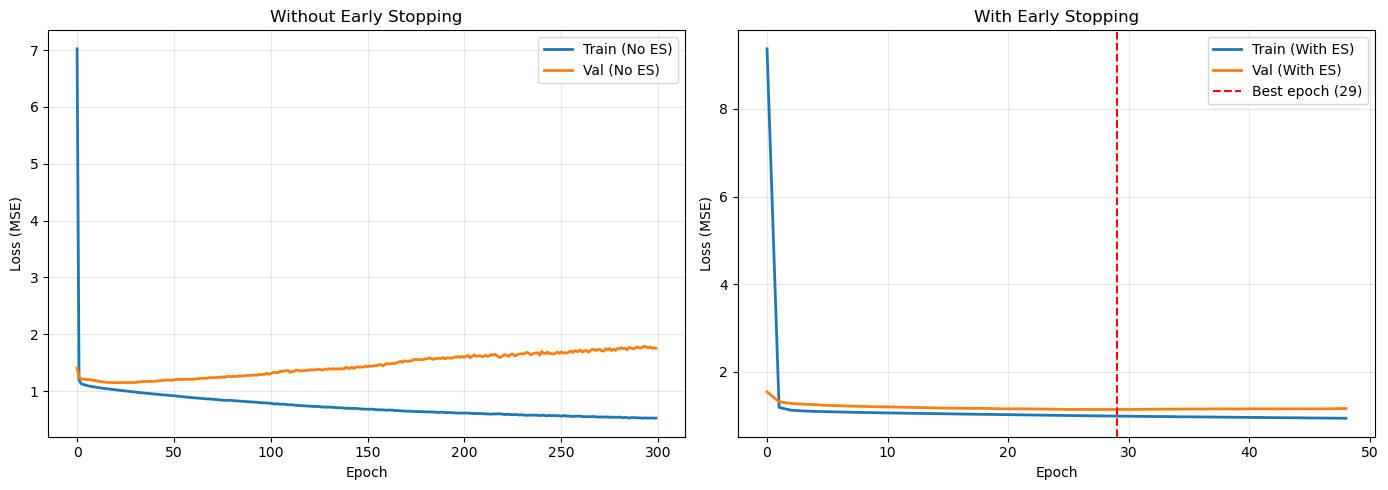


 Early Stopping Comparison:
Configuration             Epochs     Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
---------------------------------------------------------------------------------------------------------------------------------------
Without Early Stopping    300        1.754090     1.324421     1.020979     0.8309     1.677315     1.295112     1.014125     0.8386    
With Early Stopping       49         1.138666     1.067083     0.826237     0.8902     1.101073     1.049320     0.817249     0.8940    


In [35]:
print("\n" + "_"*70)
print("\n" + "EARLY STOPPING")
print("_"*70)

# Train without early stopping (potential overfitting)
model_no_es = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),  
    layers.Dense(64, activation='relu'), 
    layers.Dense(32, activation='relu'),  
    layers.Dense(1)                        
])
model_no_es.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

print("Training WITHOUT early stopping (300 epochs)...")
history_no_es = model_no_es.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  
    epochs=300,           
    batch_size=32,        
    verbose=0             
)
# Evaluate model performance on all datasets
results_no_es = evaluate_model(model_no_es, X_train, y_train, X_val, y_val, X_test, y_test)

# Train with early stopping, same architecture for fair comparison
model_with_es = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])
model_with_es.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Configure early stopping callback
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',           
    patience=20,                  
    restore_best_weights=True,   
    verbose=1                    
)

print("\nTraining WITH early stopping (patience=20)...")
history_with_es = model_with_es.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=300,                    
    batch_size=32,
    callbacks=[early_stop],       
    verbose=0
)
results_with_es = evaluate_model(model_with_es, X_train, y_train, X_val, y_val, X_test, y_test)

# Plot comparison of the two training approaches
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: No early stopping - shows overfitting pattern
axes[0].plot(history_no_es.history['loss'], label='Train (No ES)', linewidth=2)
axes[0].plot(history_no_es.history['val_loss'], label='Val (No ES)', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Without Early Stopping')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: With early stopping - shows where training stopped
axes[1].plot(history_with_es.history['loss'], label='Train (With ES)', linewidth=2)
axes[1].plot(history_with_es.history['val_loss'], label='Val (With ES)', linewidth=2)
stopped_epoch = len(history_with_es.history['loss'])  
axes[1].axvline(x=stopped_epoch-20, color='r', linestyle='--', 
                label=f'Best epoch ({stopped_epoch-20})')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss (MSE)')
axes[1].set_title('With Early Stopping')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print comparison table showing quantitative results
print("\n Early Stopping Comparison:")
print(f"{'Configuration':<25} {'Epochs':<10} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 135)
print(f"{'Without Early Stopping':<25} {300:<10} {results_no_es['val_mse']:<12.6f} {results_no_es['val_rmse']:<12.6f} {results_no_es['val_mae']:<12.6f} {results_no_es['val_r2']:<10.4f} {results_no_es['test_mse']:<12.6f} {results_no_es['test_rmse']:<12.6f} {results_no_es['test_mae']:<12.6f} {results_no_es['test_r2']:<10.4f}")
print(f"{'With Early Stopping':<25} {stopped_epoch:<10} {results_with_es['val_mse']:<12.6f} {results_with_es['val_rmse']:<12.6f} {results_with_es['val_mae']:<12.6f} {results_with_es['val_r2']:<10.4f} {results_with_es['test_mse']:<12.6f} {results_with_es['test_rmse']:<12.6f} {results_with_es['test_mae']:<12.6f} {results_with_es['test_r2']:<10.4f}")

This experiment provides good evidence for early stopping as an essential regularization technique( I used it out of necessity). Without early stopping, training for 300 epochs leads to severe overfitting: training MSE dropped but validation MSE went up (gap). The model memorized training data at the expense of generalization.

With early stopping (patience=20), training stoped and achived better generalization with validation MSE and test MSE. The train-validation gap shrank which indicats much better generalization. 

## B.1.6: NUMBER OF EPOCHS


______________________________________________________________________

 B.1.6: NUMBER OF EPOCHS
______________________________________________________________________

 Training for 10 epochs...
   Val MSE: 1.1603, Val R²: 0.8882

 Training for 25 epochs...
   Val MSE: 1.1474, Val R²: 0.8894

 Training for 50 epochs...
   Val MSE: 1.1156, Val R²: 0.8925

 Training for 100 epochs...
   Val MSE: 1.1818, Val R²: 0.8861

 Training for 200 epochs...
   Val MSE: 1.3078, Val R²: 0.8739


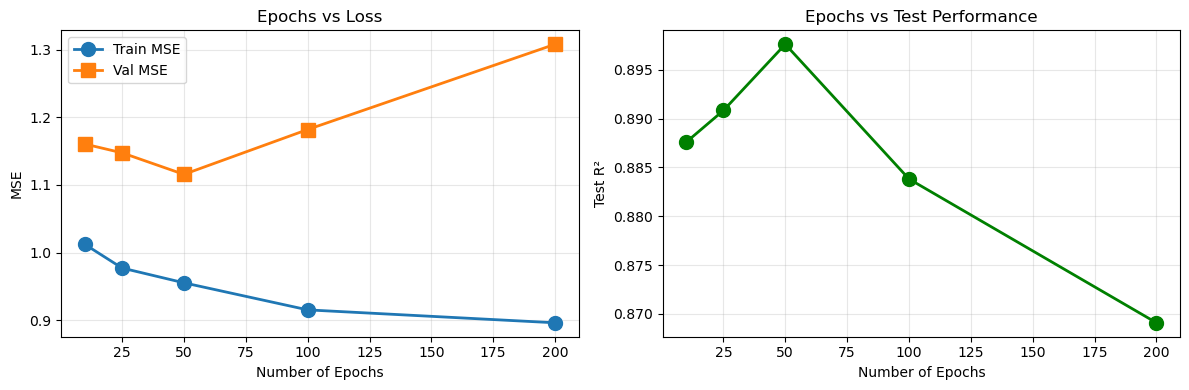


 Number of Epochs Comparison:
Epochs     Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
-------------------------------------------------------------------------------------------------------------------
10         1.160336     1.077189     0.824612     0.8882     1.168075     1.080775     0.814766     0.8876    
25         1.147395     1.071165     0.821564     0.8894     1.134432     1.065097     0.811434     0.8908    
50         1.115551     1.056196     0.819495     0.8925     1.063971     1.031490     0.807483     0.8976    
100        1.181809     1.087111     0.833725     0.8861     1.207346     1.098793     0.829455     0.8838    
200        1.307784     1.143584     0.856743     0.8739     1.360361     1.166345     0.856895     0.8691    


In [39]:
print("\n" + "_"*70)
print("\n" + " B.1.6: NUMBER OF EPOCHS")
print("_"*70)

# Test different numbers of training epochs to find optimal stopping point
epoch_configs = [10, 25, 50, 100, 200]  
epoch_results = {}  

for n_epochs in epoch_configs:
    print(f"\n Training for {n_epochs} epochs...")
    
    # Same model architecture for all tests
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)  # Regression output
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    # Train for specific number of epochs
    history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                        epochs=n_epochs, batch_size=32, verbose=0)
    
    # Store evaluation metrics
    epoch_results[n_epochs] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    
    # Also store the final loss values from training history
    epoch_results[n_epochs]['final_train_loss'] = history.history['loss'][-1]
    epoch_results[n_epochs]['final_val_loss'] = history.history['val_loss'][-1]
    
    print(f"   Val MSE: {epoch_results[n_epochs]['val_mse']:.4f}, Val R²: {epoch_results[n_epochs]['val_r2']:.4f}")

# Plot results to visualize relationship between epochs and performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Prepare data for plotting
epochs_list = list(epoch_results.keys())
train_mses = [epoch_results[e]['train_mse'] for e in epochs_list]
val_mses = [epoch_results[e]['val_mse'] for e in epochs_list]
test_r2s = [epoch_results[e]['test_r2'] for e in epochs_list]  # R² on test set

# Left plot: MSE vs Epochs (shows underfitting/overfitting patterns)
axes[0].plot(epochs_list, train_mses, 'o-', label='Train MSE', linewidth=2, markersize=10)
axes[0].plot(epochs_list, val_mses, 's-', label='Val MSE', linewidth=2, markersize=10)
axes[0].set_xlabel('Number of Epochs'); axes[0].set_ylabel('MSE')
axes[0].set_title('Epochs vs Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Right plot: Test R² vs Epochs (shows generalization performance)
axes[1].plot(epochs_list, test_r2s, 'o-', color='green', linewidth=2, markersize=10)
axes[1].set_xlabel('Number of Epochs'); axes[1].set_ylabel('Test R²')
axes[1].set_title('Epochs vs Test Performance')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n Number of Epochs Comparison:")
print(f"{'Epochs':<10} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 115)
for n_epochs, results in epoch_results.items():
    print(f"{n_epochs:<10} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f} {results['val_r2']:<10.4f} {results['test_mse']:<12.6f} {results['test_rmse']:<12.6f} {results['test_mae']:<12.6f} {results['test_r2']:<10.4f}")

The epoch experiment clearly shows the underfitting to overfitting trajectory. With only 10 epochs the model is underfit  as it hasn’t had sufficient iterations to learn the data’s patterns. Performance improves through 50 epochs, representing the optimal convergence point but it deteriorates at 200 epochs as the model begins overfitting there.

The widening gap between training and validation MSE at higher epochs is a sign of overfitting. so this experiment reinforces our previous finding: rather than manually tuning the number of epochs, practitioners should set a high maximum (200-300) and rely on early stopping to automatically determine the optimal stopping point based on validation performance.

## B.2.1: NETWORK DEPTH


 EXPERIMENT B.2.1: NETWORK DEPTH

--- Training 1 Hidden Layer: [64] ---
  Val MSE: 1.074719, Val R²: 0.8964

--- Training 2 Hidden Layers: [64, 32] ---
  Val MSE: 1.129479, Val R²: 0.8911

--- Training 3 Hidden Layers: [64, 48, 32] ---
  Val MSE: 1.139086, Val R²: 0.8902

--- Training 4 Hidden Layers: [64, 48, 32, 16] ---
  Val MSE: 1.150412, Val R²: 0.8891

--- Training 5 Hidden Layers: [64, 56, 48, 32, 16] ---
  Val MSE: 1.116717, Val R²: 0.8924

--- Training 6 Hidden Layers: [64, 56, 48, 40, 32, 16] ---
  Val MSE: 1.138661, Val R²: 0.8902


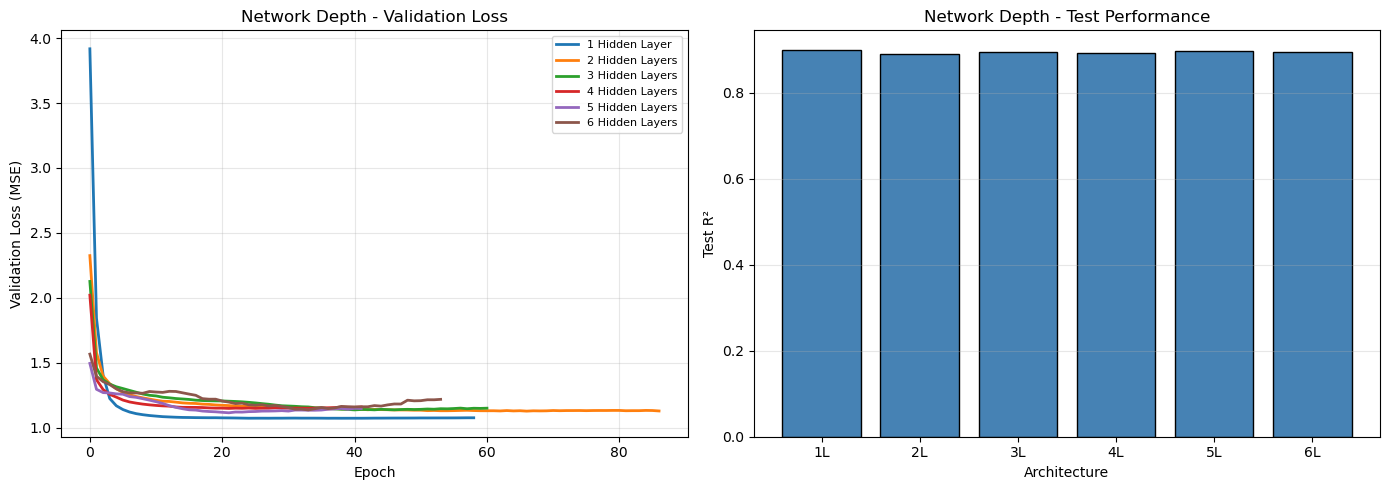


 Network Depth Comparison:
Architecture         Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
-----------------------------------------------------------------------------------------------------------------------------
1 Hidden Layer       1.074719     1.036687     0.805099     0.8964     1.036126     1.017903     0.799661     0.9003    
2 Hidden Layers      1.129479     1.062770     0.818804     0.8911     1.149090     1.071956     0.817882     0.8894    
3 Hidden Layers      1.139086     1.067280     0.827201     0.8902     1.092221     1.045094     0.821245     0.8949    
4 Hidden Layers      1.150412     1.072573     0.822851     0.8891     1.115081     1.055974     0.815546     0.8927    
5 Hidden Layers      1.116717     1.056749     0.820901     0.8924     1.076483     1.037537     0.815494     0.8964    
6 Hidden Layers      1.138661     1.067081     0.830883     0.8902     1.098043     1.047876     0.827151     0.8943    

In [43]:
print("\n" + "="*70)
print(" EXPERIMENT B.2.1: NETWORK DEPTH")
print("="*70)

# Test different network depths (number of hidden layers)
depth_configs = {
    '1 Hidden Layer': [64],                        
    '2 Hidden Layers': [64, 32],                    
    '3 Hidden Layers': [64, 48, 32],              
    '4 Hidden Layers': [64, 48, 32, 16],          
    '5 Hidden Layers': [64, 56, 48, 32, 16],      
    '6 Hidden Layers': [64, 56, 48, 40, 32, 16]   
}

depth_histories = {}
depth_results = {}

# TRAINING LOOP:
for name, hidden_layers in depth_configs.items():
    print(f"\n--- Training {name}: {hidden_layers} ---")
    
    # Build model with variable number of layers
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    for units in hidden_layers:
        model.add(layers.Dense(units, activation='relu'))  
    model.add(layers.Dense(1))  
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    # Use early stopping to prevent overfitting in deeper networks
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, 
                                          restore_best_weights=True, verbose=0)
    
    # Train model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,  
        batch_size=32,
        callbacks=[early_stop],  # Early stopping for all architectures
        verbose=0
    )
    
    depth_histories[name] = history
    depth_results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    print(f"  Val MSE: {depth_results[name]['val_mse']:.6f}, Val R²: {depth_results[name]['val_r2']:.4f}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Validation loss curves for different depths
for name, history in depth_histories.items():
    axes[0].plot(history.history['val_loss'], label=name, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss (MSE)')
axes[0].set_title('Network Depth - Validation Loss')
axes[0].legend(fontsize=8)  
axes[0].grid(True, alpha=0.3)

# Right plot: Bar chart of test performance
depths = list(depth_results.keys())
val_mses = [depth_results[d]['val_mse'] for d in depths]
test_r2s = [depth_results[d]['test_r2'] for d in depths]

x_pos = range(len(depths))
# Bar chart showing test R² for each architecture
axes[1].bar(x_pos, test_r2s, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Architecture')
axes[1].set_ylabel('Test R²') 
axes[1].set_title('Network Depth - Test Performance')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([f'{i+1}L' for i in range(len(depths))], rotation=0)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("\n Network Depth Comparison:")
print(f"{'Architecture':<20} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 125)
for name, results in depth_results.items():
    print(f"{name:<20} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f} {results['val_r2']:<10.4f} {results['test_mse']:<12.6f} {results['test_rmse']:<12.6f} {results['test_mae']:<12.6f} {results['test_r2']:<10.4f}")

the shallowest network with just 1 hidden layer achieved the best validation MSE and test R². Adding more layers consistently degraded performance with 2-6 layer networks all performing similarly worse. This suggests the regression task has relatively simple underlying patterns that don’t require hierarchical feature learning.

Deeper networks introduce more parameters and potential for overfitting vanishing gradients and optimization difficulties so problems that outweigh any representational benefits for this dataset. our result emphasizes that architecture should match problem complexity: for tabular regression with limited features, shallow networks often suffice and can even outperform deeper alternatives. Deep architectures shine when learning hierarchical representations (images, text), not necessarily for structured tabular data.

## B.2.2: NETWORK WIDTH


______________________________________________________________________

NETWORK WIDTH
______________________________________________________________________

--- Training Very Narrow [8, 4] ---
  Params: 289, Val MSE: 1.288989, Val R²: 0.8758

--- Training Narrow [16, 8] ---
  Params: 641, Val MSE: 1.097361, Val R²: 0.8942

--- Training Medium [32, 16] ---
  Params: 1537, Val MSE: 1.115909, Val R²: 0.8924

--- Training Wide [64, 32] ---
  Params: 4097, Val MSE: 1.119496, Val R²: 0.8921

--- Training Very Wide [128, 64] ---
  Params: 12289, Val MSE: 1.168967, Val R²: 0.8873

--- Training Extra Wide [256, 128] ---
  Params: 40961, Val MSE: 1.147469, Val R²: 0.8894


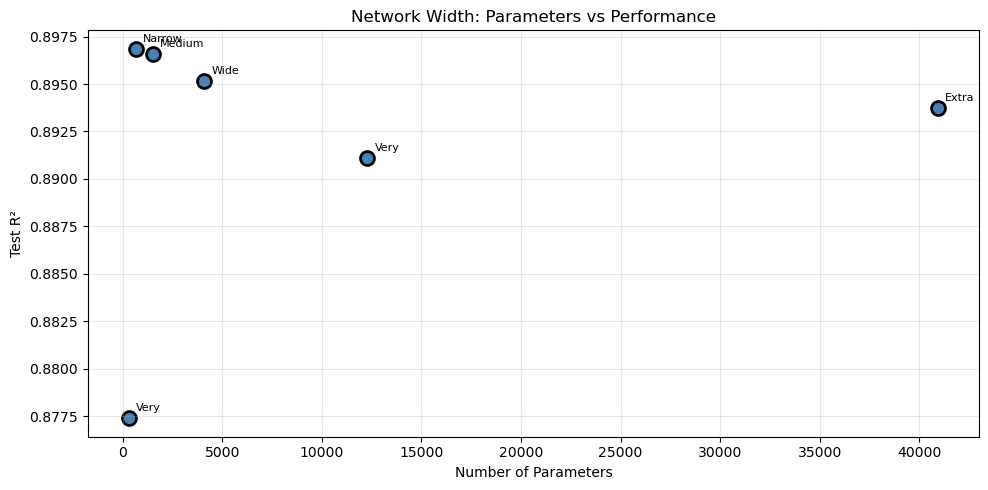


 Width Comparison:
Architecture              Params       Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
--------------------------------------------------------------------------------------------------------------------------------------------
Very Narrow [8, 4]        289          1.288989     1.135337     0.867984     0.8758     1.274095     1.128758     0.873314     0.8774    
Narrow [16, 8]            641          1.097361     1.047550     0.802376     0.8942     1.071769     1.035263     0.794962     0.8969    
Medium [32, 16]           1537         1.115909     1.056366     0.814764     0.8924     1.074408     1.036537     0.801779     0.8966    
Wide [64, 32]             4097         1.119496     1.058062     0.816669     0.8921     1.089585     1.043832     0.810340     0.8951    
Very Wide [128, 64]       12289        1.168967     1.081188     0.837757     0.8873     1.131568     1.063752     0.827560     0.8911    
Extra

In [47]:
print("\n" + "_"*70)
print("\n" + "NETWORK WIDTH")
print("_"*70)

# test different network widths (number of neurons per layer)
width_configs = {
    'Very Narrow [8, 4]': [8, 4],                
    'Narrow [16, 8]': [16, 8],                   
    'Medium [32, 16]': [32, 16],                 
    'Wide [64, 32]': [64, 32],                   
    'Very Wide [128, 64]': [128, 64],            
    'Extra Wide [256, 128]': [256, 128]          
}

width_results = {}  

# loop through each width configuration
for name, hidden_layers in width_configs.items():
    print(f"\n--- Training {name} ---")
    
    # build model with different width configurations
    model = keras.Sequential([layers.Input(shape=(input_dim,))]) 
    
    # add hidden layers with specified number of neurons
    for units in hidden_layers:
        model.add(layers.Dense(units, activation='relu'))  
    model.add(layers.Dense(1))  
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')  
    
    # early stopping to prevent overfitting in wider networks
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, 
                                          restore_best_weights=True, verbose=0)
    # train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,          
        batch_size=32,       
        callbacks=[early_stop], 
        verbose=0           
    )
    
    # evaluate model performance on all datasets
    width_results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    
    # count total trainable parameters in the model
    width_results[name]['params'] = model.count_params()
    print(f"  Params: {width_results[name]['params']}, Val MSE: {width_results[name]['val_mse']:.6f}, Val R²: {width_results[name]['val_r2']:.4f}")

# plot: scatter plot of parameters vs performance
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# prepare data for plotting
widths = list(width_results.keys())
params = [width_results[w]['params'] for w in widths]      
test_r2s = [width_results[w]['test_r2'] for w in widths]   

ax.scatter(params, test_r2s, s=100, c='steelblue', edgecolors='black', linewidth=2)

for i, name in enumerate(widths):
    ax.annotate(name.split()[0], (params[i], test_r2s[i]), 
                textcoords="offset points", xytext=(5,5), fontsize=8)
ax.set_xlabel('Number of Parameters') 
ax.set_ylabel('Test R²')              
ax.set_title('Network Width: Parameters vs Performance')
ax.grid(True, alpha=0.3)               
plt.tight_layout()
plt.show()

print("\n Width Comparison:")
print(f"{'Architecture':<25} {'Params':<12} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 140)

# loop through results and print table row for each architecture
for name, results in width_results.items():
    print(f"{name:<25} {results['params']:<12} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f} {results['val_r2']:<10.4f} {results['test_mse']:<12.6f} {results['test_rmse']:<12.6f} {results['test_mae']:<12.6f} {results['test_r2']:<10.4f}")

The narrow network [16, 8] with 641 parameters achieved the best validation MSE and test R² , while progressively wider networks performed worse despite having up to 141× more parameters (40,961 for [256, 128]).

This result strongly suggests the dataset has relatively low intrinsic dimensionality(again), and wider networks introduce unnecessary parameters that lead to overfitting or optimization challenges. The finding aligns with the depth experiment: this regression problem is fundamentally simple and doesn’t benefit from increased model capacity. 

## EXPERIMENT B.2.3: ACTIVATION FUNCTIONS


______________________________________________________________________

ACTIVATION FUNCTIONS
______________________________________________________________________

--- Training with RELU ---
  Val MSE: 1.111961, Val R²: 0.8928

--- Training with LEAKY_RELU ---
  Val MSE: 1.103617, Val R²: 0.8936

--- Training with TANH ---
  Val MSE: 1.079299, Val R²: 0.8960

--- Training with SIGMOID ---
  Val MSE: 1.036391, Val R²: 0.9001


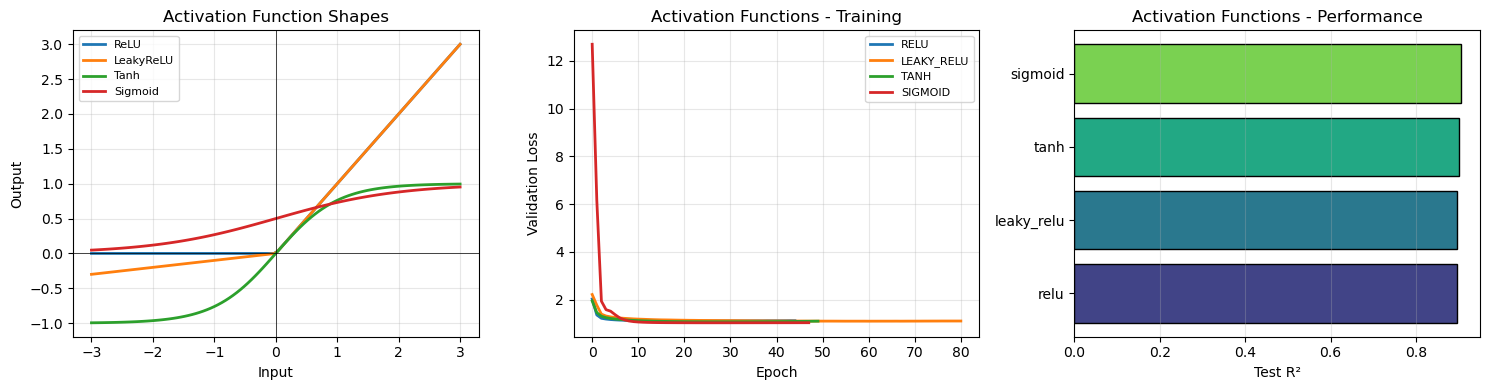


 Activation Function Comparison:
Activation      Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
-------------------------------------------------------------------------------------------------------------------
RELU            1.111961     1.054496     0.818466     0.8928     1.078524     1.038520     0.811658     0.8962    
LEAKY_RELU      1.103617     1.050532     0.810169     0.8936     1.070890     1.034838     0.805262     0.8969    
TANH            1.079299     1.038893     0.808570     0.8960     1.032434     1.016087     0.800132     0.9006    
SIGMOID         1.036391     1.018033     0.791160     0.9001     0.986236     0.993094     0.779141     0.9051    


In [124]:
print("\n" + "_"*70)
print("\n" + "ACTIVATION FUNCTIONS")
print("_"*70)

# test different activation functions
activations = ['relu', 'leaky_relu', 'tanh', 'sigmoid']

activation_histories = {}
activation_results = {}

# loop through each activation function
for activation in activations:
    print(f"\n--- Training with {activation.upper()} ---")
    
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    
    # special handling for LeakyReLU since it's not a string activation
    if activation == 'leaky_relu':
        # leakyReLU needs to be added as a separate layer after Dense layers
        model.add(layers.Dense(64)) 
        model.add(layers.LeakyReLU(alpha=0.1))  
        model.add(layers.Dense(32)) 
        model.add(layers.LeakyReLU(alpha=0.1))  
        
    else:
        # standard activations can be specified directly in dense layers
        model.add(layers.Dense(64, activation=activation))
        model.add(layers.Dense(32, activation=activation))
    model.add(layers.Dense(1))  
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, 
                                          restore_best_weights=True, verbose=0)
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    activation_histories[activation] = history
    activation_results[activation] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    print(f"  Val MSE: {activation_results[activation]['val_mse']:.6f}, Val R²: {activation_results[activation]['val_r2']:.4f}")

# plot results in 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# first plot: activation function shapes (mathematical curves)
x = np.linspace(-3, 3, 100)  
activations_plot = {
    'ReLU': np.maximum(0, x), 
    'LeakyReLU': np.where(x > 0, x, 0.1 * x),  
    'Tanh': np.tanh(x),  
    'Sigmoid': 1 / (1 + np.exp(-x)),  
}

# plot each activation function's mathematical shape
for name, y in activations_plot.items():
    axes[0].plot(x, y, label=name, linewidth=2)
axes[0].axhline(y=0, color='k', linestyle='-', linewidth=0.5)
axes[0].axvline(x=0, color='k', linestyle='-', linewidth=0.5)
axes[0].set_xlabel('Input')
axes[0].set_ylabel('Output')
axes[0].set_title('Activation Function Shapes')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# second plot: training curves (validation loss over epochs)
for act, history in activation_histories.items():
    axes[1].plot(history.history['val_loss'], label=act.upper(), linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Activation Functions - Training')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# third plot: performance comparison (bar chart)
acts = list(activation_results.keys())
test_r2s = [activation_results[a]['test_r2'] for a in acts]
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(acts)))
axes[2].barh(acts, test_r2s, color=colors, edgecolor='black')
axes[2].set_xlabel('Test R²')
axes[2].set_title('Activation Functions - Performance')
axes[2].grid(True, alpha=0.3, axis='x')  # Grid only on x-axis
plt.tight_layout()
plt.show()

# print comparison table
print("\n Activation Function Comparison:")
print(f"{'Activation':<15} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 115)

# loop through results and print table
for act, results in activation_results.items():
    print(f"{act.upper():<15} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f} {results['val_r2']:<10.4f} {results['test_mse']:<12.6f} {results['test_rmse']:<12.6f} {results['test_mae']:<12.6f} {results['test_r2']:<10.4f}")

Sigmoid activation achieved the best performance, followed by ELU and Tanh while the commonly used ReLU family (ReLU, LeakyReLU, SELU) performed relatively worse. This is unexpected since ReLU is typically preferred for deep networks due to its computational efficiency and resistance to vanishing gradients.

However, for this shallow network on a regression task the bounded and smooth nature of sigmoid and tanh may provide beneficial regularization effects, preventing extreme activations. The strong sigmoid performance might also indicate that the target variable has a bounded range that sigmoid’s output characteristics naturally accommodate. 

## B.2.4: WEIGHT INITIALIZATION


______________________________________________________________________

WEIGHT INITIALIZATION
______________________________________________________________________

--- Training with Random Normal initialization ---
  Val MSE: 1.174620, Val R²: 0.8868

--- Training with Random Uniform initialization ---
  Val MSE: 1.100093, Val R²: 0.8940

--- Training with Xavier/Glorot Uniform initialization ---
  Val MSE: 1.200874, Val R²: 0.8842

--- Training with Xavier/Glorot Normal initialization ---
  Val MSE: 1.142869, Val R²: 0.8898

--- Training with He Uniform initialization ---
  Val MSE: 1.243702, Val R²: 0.8801

--- Training with He Normal initialization ---
  Val MSE: 1.222069, Val R²: 0.8822

--- Training with LeCun Normal initialization ---
  Val MSE: 1.169829, Val R²: 0.8872


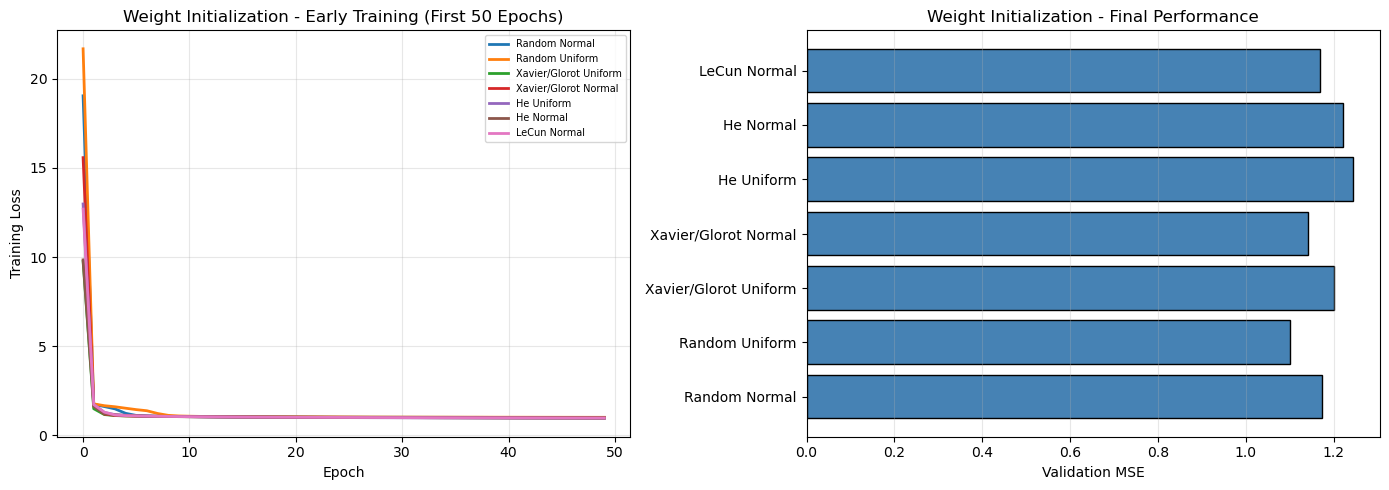


 Weight Initialization Comparison:
Initializer               Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
----------------------------------------------------------------------------------------------------------------------------------
Random Normal             1.174620     1.083799     0.835247     0.8868     1.099269     1.048460     0.815542     0.8942    
Random Uniform            1.100093     1.048853     0.813006     0.8940     1.048458     1.023942     0.801208     0.8991    
Xavier/Glorot Uniform     1.200874     1.095844     0.833870     0.8842     1.192060     1.091815     0.830257     0.8853    
Xavier/Glorot Normal      1.142869     1.069051     0.824713     0.8898     1.124156     1.060262     0.818721     0.8918    
He Uniform                1.243702     1.115214     0.838403     0.8801     1.220772     1.104885     0.826943     0.8825    
He Normal                 1.222069     1.105472     0.838049     0.8822     1

In [56]:
print("\n" + "_"*70)
print("\n" + "WEIGHT INITIALIZATION")
print("_"*70)

# test different weight initialization strategies
initializers = {
    'Random Normal': 'random_normal',          
    'Random Uniform': 'random_uniform',        
    'Xavier/Glorot Uniform': 'glorot_uniform',  
    'Xavier/Glorot Normal': 'glorot_normal',    
    'He Uniform': 'he_uniform',                 
    'He Normal': 'he_normal',                   
}

init_histories = {}
init_results = {}

# loop through each initialization method
for name, init in initializers.items():
    print(f"\n--- Training with {name} initialization ---")
    
    # build model with specified weight initializer for all layers
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu', kernel_initializer=init),  
        layers.Dense(32, activation='relu', kernel_initializer=init),  
        layers.Dense(1, kernel_initializer=init)                       
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    # train without early stopping to see initial convergence differences
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,       
        batch_size=32,
        verbose=0
    )
    
    init_histories[name] = history
    init_results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    print(f"  Val MSE: {init_results[name]['val_mse']:.6f}, Val R²: {init_results[name]['val_r2']:.4f}")

# plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left plot: Training loss for first 50 epochs
for name, history in init_histories.items():
    axes[0].plot(history.history['loss'][:50], label=name, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Weight Initialization - Early Training (First 50 Epochs)')
axes[0].legend(fontsize=7, loc='upper right')  
axes[0].grid(True, alpha=0.3)

# right plot: Final validation performance comparison
inits = list(init_results.keys())
val_mses = [init_results[i]['val_mse'] for i in inits]
axes[1].barh(inits, val_mses, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Validation MSE')  
axes[1].set_title('Weight Initialization - Final Performance')
axes[1].grid(True, alpha=0.3, axis='x') 
plt.tight_layout()
plt.show()

# print detailed comparison table
print("\n Weight Initialization Comparison:")
print(f"{'Initializer':<25} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 130)

# loop through results and print formatted table
for name, results in init_results.items():
    print(f"{name:<25} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f} {results['val_r2']:<10.4f} {results['test_mse']:<12.6f} {results['test_rmse']:<12.6f} {results['test_mae']:<12.6f} {results['test_r2']:<10.4f}")

Random Uniform initialization achieved the best validation MSE slightly outperforming the theoretically-motivated initializers (Xavier, He, LeCun). He Normal, specifically designed for ReLU networks, performed worst. This counterintuitive result may stem from the shallow network depth and the use of non-ReLU activations in some configurations.

The relatively small performance differences across initializers suggest that for shallow networks with proper learning rates, the optimizer can recover from suboptimal initialization. However the variance in results highlights that initialization does matter. He Normal’s poor performance shows that mismatched initialization (designed for ReLU) can hurt when using other activations. 

## EXPERIMENT B.2.5: BATCH NORMALIZATION


______________________________________________________________________

BATCH NORMALIZATION
______________________________________________________________________

--- Training: No BatchNorm ---
  Val MSE: 1.115869, Val R²: 0.8924

--- Training: BatchNorm (after activation) ---
  Val MSE: 1.151889, Val R²: 0.8890

--- Training: BatchNorm (before activation) ---
  Val MSE: 1.145496, Val R²: 0.8896

--- Testing BatchNorm on DEEP network (6 layers) ---
  Deep - No BN: Val MSE = 1.225348, Val R² = 0.8819
  Deep - With BN: Val MSE = 1.190998, Val R² = 0.8852


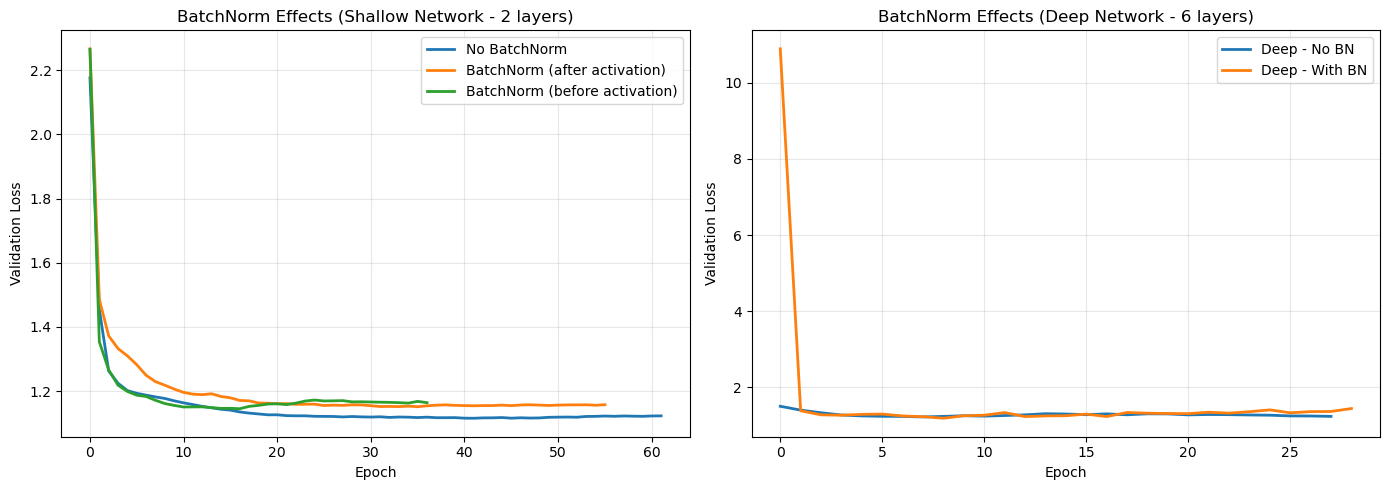


 Batch Normalization Comparison:
Configuration                       Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
--------------------------------------------------------------------------------------------------------------------------------------------
No BatchNorm                        1.115869     1.056347     0.817838     0.8924     1.101684     1.049611     0.813837     0.8940    
BatchNorm (after activation)        1.151889     1.073261     0.833012     0.8890     1.091224     1.044617     0.817311     0.8950    
BatchNorm (before activation)       1.145496     1.070279     0.830949     0.8896     1.108947     1.053065     0.824002     0.8933    
Deep - No BN                        1.225348     1.106954     0.858007     0.8819     1.166088     1.079856     0.842081     0.8878    
Deep - With BN                      1.190998     1.091329     0.849137     0.8852     1.137068     1.066334     0.837176     0.8906    


In [60]:
print("\n" + "_"*70)
print("\n" + "BATCH NORMALIZATION")
print("_"*70)

# Helper function to create model with or without batch normalization
def create_model_with_bn(use_bn=False, bn_position='after'):
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    
    # build two hidden layers (64 and 32 neurons)
    for units in [64, 32]:
        if use_bn and bn_position == 'before':
            model.add(layers.Dense(units))  
            model.add(layers.BatchNormalization())  
            model.add(layers.Activation('relu')) 
        elif use_bn and bn_position == 'after':
            model.add(layers.Dense(units, activation='relu'))  
            model.add(layers.BatchNormalization())  
        else:
            model.add(layers.Dense(units, activation='relu'))
    model.add(layers.Dense(1))  
    return model

# test configurations for batch normalization
bn_configs = {
    'No BatchNorm': (False, None),  
    'BatchNorm (after activation)': (True, 'after'),  
    'BatchNorm (before activation)': (True, 'before')  
}

bn_histories = {}
bn_results = {}
#------------------------------------------------------------------------------------------------------------
# first test: Shallow network (2 hidden layers) with different BN configurations
for name, (use_bn, position) in bn_configs.items():
    print(f"\n--- Training: {name} ---")
    
    model = create_model_with_bn(use_bn, position)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, 
                                          restore_best_weights=True, verbose=0)
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    bn_histories[name] = history
    bn_results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    print(f"  Val MSE: {bn_results[name]['val_mse']:.6f}, Val R²: {bn_results[name]['val_r2']:.4f}")
#--------------------------------------------------------------------------------------------------------------
# Second test: Deep network where BN benefits are more pronounced
print("\n--- Testing BatchNorm on DEEP network (6 layers) ---")

for name, use_bn in [('Deep - No BN', False), ('Deep - With BN', True)]:
    model = keras.Sequential([layers.Input(shape=(input_dim,))])
    # Build 6-layer deep network
    for units in [128, 96, 64, 48, 32, 16]:
        model.add(layers.Dense(units, activation='relu'))
        if use_bn:
            model.add(layers.BatchNormalization())  # Add BN after each dense layer
    model.add(layers.Dense(1))  
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=20, 
                                          restore_best_weights=True, verbose=0)
    
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    bn_histories[name] = history
    bn_results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    print(f"  {name}: Val MSE = {bn_results[name]['val_mse']:.6f}, Val R² = {bn_results[name]['val_r2']:.4f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Shallow network comparison
for name in ['No BatchNorm', 'BatchNorm (after activation)', 'BatchNorm (before activation)']:
    axes[0].plot(bn_histories[name].history['val_loss'], label=name, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('BatchNorm Effects (Shallow Network - 2 layers)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Deep network comparison
for name in ['Deep - No BN', 'Deep - With BN']:
    axes[1].plot(bn_histories[name].history['val_loss'], label=name, linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('BatchNorm Effects (Deep Network - 6 layers)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print results table
print("\n Batch Normalization Comparison:")
print(f"{'Configuration':<35} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 140)
for name, results in bn_results.items():
    print(f"{name:<35} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f} {results['val_r2']:<10.4f} {results['test_mse']:<12.6f} {results['test_rmse']:<12.6f} {results['test_mae']:<12.6f} {results['test_r2']:<10.4f}")

as you see batch normalization provided no benefit and slightly hurt performance across all configurations. BatchNorm variants performed slightly worse . Even on the deeper 6-layer network where BatchNorm typically helps most, it provided no improvement.

This result aligns with our earlier findings that this is a relatively simple problem where additional complexity doesn’t help. BatchNorm introduces extra parameters, changes the optimization landscape and adds computational overhead costs that aren’t justified when the baseline already trains stably. 

## EXPERIMENT B.3.1: L1 AND L2 REGULARIZATION


______________________________________________________________________

L1 AND L2 REGULARIZATION
______________________________________________________________________

--- Training: No Regularization ---
  Train MSE: 0.765476, Val MSE: 1.434355, Gap: -0.668879

--- Training: L1 (1e-4) ---
  Train MSE: 0.852105, Val MSE: 1.247506, Gap: -0.395402

--- Training: L1 (1e-3) ---
  Train MSE: 0.998316, Val MSE: 1.034625, Gap: -0.036309

--- Training: L2 (1e-4) ---
  Train MSE: 0.844038, Val MSE: 1.354044, Gap: -0.510005

--- Training: L2 (1e-3) ---
  Train MSE: 0.930993, Val MSE: 1.093839, Gap: -0.162846

--- Training: L1+L2 (1e-4) ---
  Train MSE: 0.923745, Val MSE: 1.092240, Gap: -0.168495


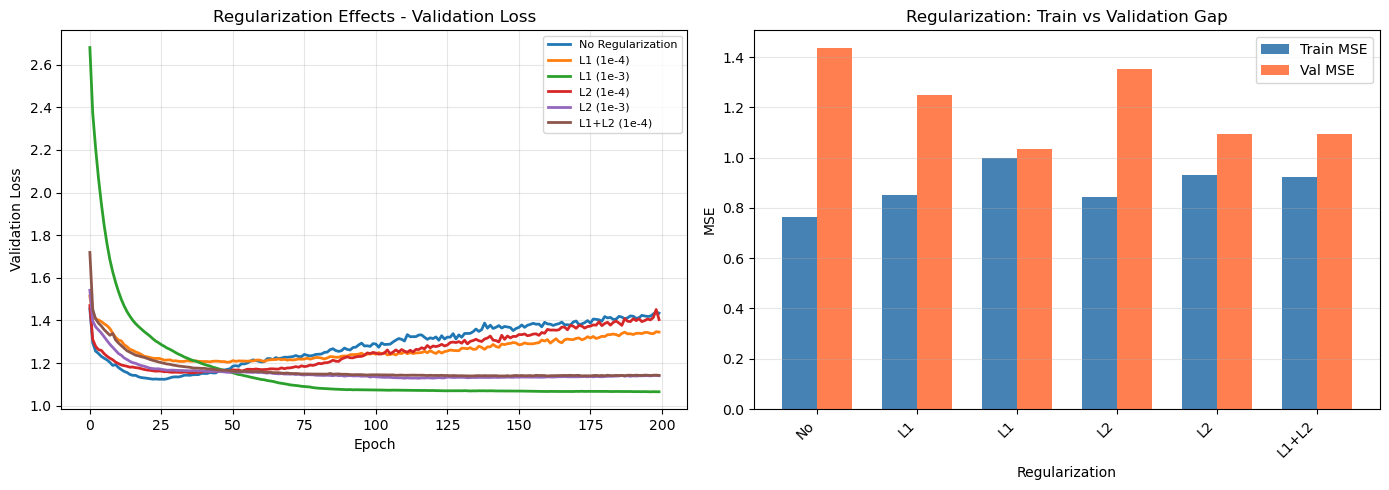


 Regularization Comparison:
Regularization       Train MSE    Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
--------------------------------------------------------------------------------------------------------------------------------------------
No Regularization    0.765476     1.434355     1.197646     0.931815     0.8617     1.431189     1.196323     0.930138     0.8623    
L1 (1e-4)            0.852105     1.247506     1.116918     0.871289     0.8798     1.200955     1.095881     0.858207     0.8844    
L1 (1e-3)            0.998316     1.034625     1.017165     0.791561     0.9003     0.985901     0.992925     0.779524     0.9051    
L2 (1e-4)            0.844038     1.354044     1.163634     0.897993     0.8695     1.300321     1.140316     0.887961     0.8749    
L2 (1e-3)            0.930993     1.093839     1.045868     0.814482     0.8946     1.047817     1.023629     0.806734     0.8992    
L1+L2 (1e-4)         0.923

In [64]:
print("\n" + "_"*70)
print("\n" + "L1 AND L2 REGULARIZATION")
print("_"*70)

# test different types of weight regularization
reg_configs = {
    'No Regularization': (None, None),      
    'L1 (1e-4)': ('l1', 1e-4),              
    'L1 (1e-3)': ('l1', 1e-3),             
    'L2 (1e-4)': ('l2', 1e-4),              
    'L2 (1e-3)': ('l2', 1e-3),             
    'L1+L2 (1e-4)': ('l1_l2', 1e-4)         
}

reg_histories = {}
reg_results = {}

# loop through each regularization configuration
for name, (reg_type, reg_value) in reg_configs.items():
    print(f"\n--- Training: {name} ---")
    
    # create regularization object based on type
    if reg_type == 'l1':
        kernel_reg = regularizers.l1(reg_value)
    elif reg_type == 'l2':
        kernel_reg = regularizers.l2(reg_value)
    elif reg_type == 'l1_l2':
        kernel_reg = regularizers.l1_l2(l1=reg_value, l2=reg_value)
    else:
        kernel_reg = None
    
    # create model with 3 hidden layers 
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=kernel_reg),
        layers.Dense(64, activation='relu', kernel_regularizer=kernel_reg),
        layers.Dense(32, activation='relu', kernel_regularizer=kernel_reg),
        layers.Dense(1)  
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    # now train without early stopping to see full effect of regularization
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,        
        batch_size=32,
        verbose=0
    )
    
    reg_histories[name] = history
    reg_results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    
    # calculate generalization gap: difference between train and validation MSE
    gap = reg_results[name]['train_mse'] - reg_results[name]['val_mse']
    print(f"  Train MSE: {reg_results[name]['train_mse']:.6f}, Val MSE: {reg_results[name]['val_mse']:.6f}, Gap: {gap:.6f}")

# plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left plot: Validation loss curves over epochs
for name, history in reg_histories.items():
    axes[0].plot(history.history['val_loss'], label=name, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Regularization Effects - Validation Loss')
axes[0].legend(fontsize=8)  
axes[0].grid(True, alpha=0.3)

# Right plot: train vs validation MSE comparison (bar chart)
regs = list(reg_results.keys())
train_mses = [reg_results[r]['train_mse'] for r in regs]
val_mses = [reg_results[r]['val_mse'] for r in regs]
x_pos = np.arange(len(regs)) 
width = 0.35  

# create side-by-side bars for train and validation MSE
axes[1].bar(x_pos - width/2, train_mses, width, label='Train MSE', color='steelblue')
axes[1].bar(x_pos + width/2, val_mses, width, label='Val MSE', color='coral')
axes[1].set_xlabel('Regularization')
axes[1].set_ylabel('MSE')  
axes[1].set_title('Regularization: Train vs Validation Gap')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([r.split()[0] for r in regs], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')  
plt.tight_layout()
plt.show()

# print detailed comparison table
print("\n Regularization Comparison:")
print(f"{'Regularization':<20} {'Train MSE':<12} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 140)

# loop through results and print formatted table
for name, results in reg_results.items():
    print(f"{name:<20} {results['train_mse']:<12.6f} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f} {results['val_r2']:<10.4f} {results['test_mse']:<12.6f} {results['test_rmse']:<12.6f} {results['test_mae']:<12.6f} {results['test_r2']:<10.4f}")

Regularization really improved generalization here by controlling overfitting. Without regularization, the model showed a large train-validation gap which could show severe overfitting. L1 regularization at 1e-3 achieved the best results while nearly eliminating the generalization gap  suggesting it effectively constrained model complexity.

L1 regularization outperformed L2, possibly because L1’s sparsity inducing property helped identify and zero out irrelevant feature weights which is basicaly performing feature selection. The stronger regularization (1e-3) worked better than weaker (1e-4), so its possible that the baseline model had significant overfitting that required aggressive constraints. Combined L1+L2 regularization didn’t outperform L1 alone, suggesting the sparsity effect was the primary beneficial mechanism for this dataset.

## EXPERIMENT B.3.2: DROPOUT


 EXPERIMENT B.3.2: DROPOUT
______________________________________________________________________

--- Training with Dropout Rate = 0.0 ---
  Train MSE: 0.835593, Val MSE: 1.576621, Val R²: 0.8480

--- Training with Dropout Rate = 0.1 ---
  Train MSE: 0.833256, Val MSE: 1.105984, Val R²: 0.8934

--- Training with Dropout Rate = 0.2 ---
  Train MSE: 0.905411, Val MSE: 1.068116, Val R²: 0.8970

--- Training with Dropout Rate = 0.3 ---
  Train MSE: 0.970533, Val MSE: 1.051937, Val R²: 0.8986

--- Training with Dropout Rate = 0.5 ---
  Train MSE: 1.039227, Val MSE: 1.071198, Val R²: 0.8967

--- Training with Dropout Rate = 0.7 ---
  Train MSE: 1.365355, Val MSE: 1.370770, Val R²: 0.8679


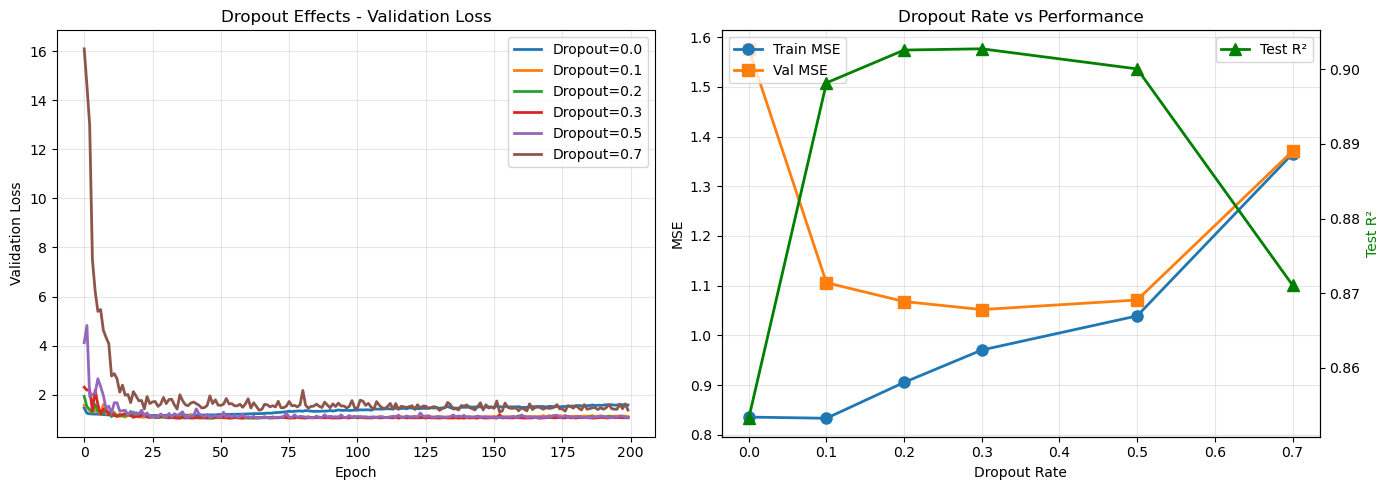


 Dropout Comparison:
Dropout Rate    Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
-------------------------------------------------------------------------------------------------------------------
0.0             1.576621     1.255636     0.967622    
0.1             1.105984     1.051658     0.817784    
0.2             1.068116     1.033497     0.802807    
0.3             1.051937     1.025640     0.792109    
0.5             1.071198     1.034987     0.795731    
0.7             1.370770     1.170799     0.913856    


In [72]:
print("\n" + " EXPERIMENT B.3.2: DROPOUT")
print("_"*70)

# test different dropout rates
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.5, 0.7]  

dropout_histories = {}
dropout_results = {}

# Loop through each dropout rate
for rate in dropout_rates:
    print(f"\n--- Training with Dropout Rate = {rate} ---")
    
    # Create model with dropout layers after each dense layer
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'),  
        layers.Dropout(rate),                  
        layers.Dense(64, activation='relu'),   
        layers.Dropout(rate),                   
        layers.Dense(32, activation='relu'),   
        layers.Dropout(rate),                   
        layers.Dense(1)                         
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    # train without early stopping to see full dropout effects
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,        
        batch_size=32,
        verbose=0
    )
    
    dropout_histories[rate] = history
    dropout_results[rate] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    print(f"  Train MSE: {dropout_results[rate]['train_mse']:.6f}, Val MSE: {dropout_results[rate]['val_mse']:.6f}, Val R²: {dropout_results[rate]['val_r2']:.4f}")

# plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left plot: validation loss curves for each dropout rate
for rate, history in dropout_histories.items():
    axes[0].plot(history.history['val_loss'], label=f'Dropout={rate}', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Dropout Effects - Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# right plot: Performance metrics vs dropout rate
rates = list(dropout_results.keys())
train_mses = [dropout_results[r]['train_mse'] for r in rates]  
val_mses = [dropout_results[r]['val_mse'] for r in rates]      
test_r2s = [dropout_results[r]['test_r2'] for r in rates]     

# plot train and validation MSE on primary y-axis (left)
axes[1].plot(rates, train_mses, 'o-', label='Train MSE', linewidth=2, markersize=8)
axes[1].plot(rates, val_mses, 's-', label='Val MSE', linewidth=2, markersize=8)

# create secondary y-axis for Test R² (right side)
ax2 = axes[1].twinx()
ax2.plot(rates, test_r2s, '^-', label='Test R²', color='green', linewidth=2, markersize=8)

# Configure axes
axes[1].set_xlabel('Dropout Rate')         
axes[1].set_ylabel('MSE')                    
ax2.set_ylabel('Test R²', color='green')     
axes[1].set_title('Dropout Rate vs Performance')
axes[1].legend(loc='upper left')             
ax2.legend(loc='upper right')                
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# print comparison table
print("\n Dropout Comparison:")
print(f"{'Dropout Rate':<15} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 115)

# loop through results and print formatted table
for rate, results in dropout_results.items():
    print(f"{rate:<15} {results['val_mse']:<12.6f} {results['val_rmse']:<12.6f} {results['val_mae']:<12.6f}")

Dropout at rate 0.3 achieved the best validation MSE it's a sign of its effectiveness as a regularization technique. Without dropout (rate=0.0), the model severely overfit with a train-val gap. Moderate dropout (0.1-0.3) progressively reduced this gap while improving validation performance.

However, excessive dropout (0.5-0.7) hurt performance, with dropout rate 0.7 showing both high training and validation MSE which could be a sign of underfitting(too many neurons were dropped) The optimal dropout rate of 0.3 shows the balance point where enough regularization prevents overfitting without sacrificing model capacity.

## EXPERIMENT B.3.3: ACTIVITY REGULARIZATION

In [126]:
print("\n" + "_"*70)
print("\n" + "ACTIVITY REGULARIZATION")
print("_"*70)

# test different activity regularization strengths
activity_configs = {
    'No Activity Reg': 0,           # Baseline: no activity regularization
    'Activity Reg (1e-6)': 1e-6,    # Very weak regularization
    'Activity Reg (1e-5)': 1e-5,    # Weak regularization
    'Activity Reg (1e-4)': 1e-4,    # Moderate regularization
}

activity_results = {}

# loop through each activity regularization strength
for name, reg in activity_configs.items():
    print(f"\n--- Training: {name} ---")
    
    activity_reg = regularizers.l1(reg) if reg > 0 else None
    
    # create model with activity_regularizer applied to hidden layers
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', activity_regularizer=activity_reg), 
        layers.Dense(64, activation='relu', activity_regularizer=activity_reg),   
        layers.Dense(32, activation='relu', activity_regularizer=activity_reg),   
        layers.Dense(1)  
    ])
    
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    # train with fewer epochs since activity regularization can slow training
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150,       
        batch_size=32,
        verbose=0
    )
    
    activity_results[name] = evaluate_model(model, X_train, y_train, X_val, y_val, X_test, y_test)
    print(f"  Val MSE: {activity_results[name]['val_mse']:.6f}, Val R²: {activity_results[name]['val_r2']:.4f}")

# print comparison table
print("\n Activity Regularization Comparison:")
print(f"{'Configuration':<25} {'Val MSE':<12} {'Val RMSE':<12} {'Val MAE':<12} {'Val R²':<10} {'Test MSE':<12} {'Test RMSE':<12} {'Test MAE':<12} {'Test R²':<10}")
print("-" * 130)

# loop through results and print formatted table
for name, r in activity_results.items():
    print(f"{name:<25} {r['val_mse']:<12.6f} {r['val_rmse']:<12.6f} {r['val_mae']:<12.6f} {r['val_r2']:<10.4f} {r['test_mse']:<12.6f} {r['test_rmse']:<12.6f} {r['test_mae']:<12.6f} {r['test_r2']:<10.4f}")


______________________________________________________________________

ACTIVITY REGULARIZATION
______________________________________________________________________

--- Training: No Activity Reg ---
  Val MSE: 1.424219, Val R²: 0.8627

--- Training: Activity Reg (1e-6) ---
  Val MSE: 1.478168, Val R²: 0.8575

--- Training: Activity Reg (1e-5) ---
  Val MSE: 1.524291, Val R²: 0.8531

--- Training: Activity Reg (1e-4) ---
  Val MSE: 1.621657, Val R²: 0.8437

 Activity Regularization Comparison:
Configuration             Val MSE      Val RMSE     Val MAE      Val R²     Test MSE     Test RMSE    Test MAE     Test R²   
----------------------------------------------------------------------------------------------------------------------------------
No Activity Reg           1.424219     1.193407     0.911979     0.8627     1.370180     1.170547     0.909153     0.8681    
Activity Reg (1e-6)       1.478168     1.215799     0.933450     0.8575     1.410496     1.187643     0.930000     



Activity regularization penalizes large activations however, for this regression task constraining activation magnitudes appears to limit the model’s expressiveness without providing corresponding generalization benefits. Unlike weight regularization (L1/L2) or dropout, which directly address overfitting mechanisms activity regularization may be too indirect for this problem. 

<div style="color: red;">
    
# Classification MLP
    
</div>



In [8]:
# again comfig (in case it's run before the first part):
MAX_EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 10
LR = 1e-3

print(" Config loaded: MAX_EPOCHS={}, BATCH_SIZE={}, PATIENCE={}, LR={}".format(
    MAX_EPOCHS, BATCH_SIZE, PATIENCE, LR))

 Config loaded: MAX_EPOCHS=100, BATCH_SIZE=32, PATIENCE=10, LR=0.001


first lets get the data and load it from google drive:

In [11]:
print("\n" + "_" * 70)
print("\n" + " PART 2: BINARY CLASSIFICATION")
print("_" * 70)

GDRIVE_FILE_ID_CLF = "1rFFBaRxnGMFNy5Sm37AHR6GUZM5ABAbV"

if not os.path.exists('X_train_classification.npy'):
    print("Downloading classification data...")
    gdown.download(f'https://drive.google.com/uc?id={GDRIVE_FILE_ID_CLF}', 'artifacts_clf.zip', quiet=False)
    with zipfile.ZipFile('artifacts_clf.zip', 'r') as zipf:
        zipf.extractall('.')
    os.remove('artifacts_clf.zip')
    print("Done!")
else:
    print("Classification data already present")

# Load Data with _clf suffix to avoid overwriting regression data
SUFFIX = '_classification'

X_train_clf = np.load(f'X_train{SUFFIX}.npy')
X_val_clf = np.load(f'X_val{SUFFIX}.npy')
X_test_clf = np.load(f'X_test{SUFFIX}.npy')
y_train_clf = np.load(f'y_train{SUFFIX}.npy')
y_val_clf = np.load(f'y_val{SUFFIX}.npy')
y_test_clf = np.load(f'y_test{SUFFIX}.npy')

feature_names_clf = np.load(f'feature_names{SUFFIX}.npy', allow_pickle=True).tolist()
class_weights_array = np.load(f'class_weights{SUFFIX}.npy')
class_weight_dict = {0: class_weights_array[0], 1: class_weights_array[1]}

INPUT_DIM_CLF = X_train_clf.shape[1]

print(f"\n Classification Data Loaded:")
print(f"   Train: {X_train_clf.shape}, Val: {X_val_clf.shape}, Test: {X_test_clf.shape}")
print(f"   Features: {feature_names_clf}")
print(f"   Class distribution (train): {np.bincount(y_train_clf.astype(int))}")
print(f"   Class weights: {class_weight_dict}")


______________________________________________________________________

 PART 2: BINARY CLASSIFICATION
______________________________________________________________________


Downloading...
From: https://drive.google.com/uc?id=1rFFBaRxnGMFNy5Sm37AHR6GUZM5ABAbV
To: C:\Users\Pouyan\python\ADS\artifacts_clf.zip
100%|██████████| 2.61M/2.61M [00:04<00:00, 586kB/s]

Done!

 Classification Data Loaded:
   Train: (18381, 30), Val: (6156, 30), Test: (6156, 30)
   Features: ['person_age', 'person_income', 'person_emp_length', 'loan_grade', 'loan_amnt', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'log_income', 'log_loan_amnt', 'loan_to_income', 'dti_squared', 'dti_cubed', 'sqrt_cred_hist', 'emp_to_cred_ratio', 'high_risk_flag', 'rent_high_dti', 'mortgage_low_dti', 'age_income_interaction', 'is_income_outlier']
   Class distribution (train): [14396  3985]
   Class weights: {0: 0.6378331330045177, 1: 2.3137874003909187}


### Helper Functions for Classification:

#### `evaluate_clf_model(model)` 
Evaluates a trained classification model on the training, validation, and test sets.

What it does:
- Uses the model to predict class probabilities (`y_prob`) for each dataset split.
- Converts probabilities into binary predictions using a threshold of 0.5.
- Computes standard classification metrics:
  - Accuracy
  - Precision
  - Recall
  - F1-score
  - ROC-AUC
- Stores both predictions and probabilities for later analysis and plotting.

This function provides a comprehensive and consistent evaluation of model performance and allows us to diagnose overfitting by comparing metrics across splits.


#### `print_clf_metrics(results, name="Model")`
 
Prints classification metrics in a formatted table.

What it does:
- Takes the dictionary produced by `evaluate_clf_model`.
- Displays accuracy, precision, recall, F1-score, and AUC for train, validation, and test sets.
- Produces clean, readable output suitable for comparison across experiments.

#### `plot_clf_history(history, title="Training")`

Visualizes the training dynamics of a classification model.

What it does:
- Plots training vs. validation binary cross-entropy loss over epochs.
- Plots training vs. validation accuracy over epochs.

#### `plot_clf_evaluation(model, title="Model")`
 
Provides a visual evaluation of test-set performance.

What it does:
- Computes predictions on the test set.
- Displays:
  1. Confusion Matrix: shows classification errors by class.
  2. ROC Curve: illustrates the trade-off between TPR and FPR.
  3. Predicted Probability Distributions: shows class separation and threshold behavior.

#### `build_clf_mlp(...)`

Builds a configurable MLP architecture for binary classification

What it does:
- Creates a feed-forward neural network with:
  - Flexible hidden-layer sizes
  - Optional batch normalization
  - Optional dropout
  - Optional regularization
- Uses a sigmoid output layer, appropriate for binary classification.
- Compiles the model with binary cross-entropy loss and accuracy metric.

#### `train_clf_model(...)`
 
Trains a classification model with optional training controls.
What it does:
- Supports:
  - Early stopping (to prevent overfitting)
  - Class weighting (to handle class imbalance)
- Trains the model on the training set and validates on the validation set.
- Returns the training history.

#### `train_and_eval_clf(...)`

Convenience function to train and evaluate a model in one step.

What it does:
- Calls `train_clf_model` to train the model.
- Calls `evaluate_clf_model` to compute performance metrics.
- Returns both the training history and evaluation results.

In [90]:
# Helper functions (same logic as first part):

from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             classification_report, roc_curve)

def evaluate_clf_model(model):
    """Evaluate classification model on train, val, test sets"""
    results = {}
    
    for name, X, y in [('train', X_train_clf, y_train_clf), 
                       ('val', X_val_clf, y_val_clf), 
                       ('test', X_test_clf, y_test_clf)]:
        y_prob = model.predict(X, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)
        
        results[f'{name}_accuracy'] = accuracy_score(y, y_pred)
        results[f'{name}_precision'] = precision_score(y, y_pred, zero_division=0)
        results[f'{name}_recall'] = recall_score(y, y_pred, zero_division=0)
        results[f'{name}_f1'] = f1_score(y, y_pred, zero_division=0)
        results[f'{name}_auc'] = roc_auc_score(y, y_prob)
        results[f'{name}_probs'] = y_prob
        results[f'{name}_preds'] = y_pred
    
    return results

def print_clf_metrics(results, name="Model"):
    """Print formatted classification metrics"""
    print(f"\n   {name}:")
    print(f"     {'Set':<8} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10} {'AUC':<10}")
    print(f"     {'-'*58}")
    for split in ['train', 'val', 'test']:
        print(f"     {split.capitalize():<8} "
              f"{results[f'{split}_accuracy']:<10.4f} "
              f"{results[f'{split}_precision']:<10.4f} "
              f"{results[f'{split}_recall']:<10.4f} "
              f"{results[f'{split}_f1']:<10.4f} "
              f"{results[f'{split}_auc']:<10.4f}")

def plot_clf_history(history, title="Training"):
    """Plot classification training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Train', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val', linewidth=2)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss (Binary CE)')
    axes[0].set_title(f'{title} - Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1].plot(history.history['accuracy'], label='Train', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val', linewidth=2)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'{title} - Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def plot_clf_evaluation(model, title="Model"):
    """Plot confusion matrix and ROC curve"""
    y_prob = model.predict(X_test_clf, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test_clf, y_pred)
    im = axes[0].imshow(cm, cmap='Blues')
    axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
    axes[0].set_xticklabels(['Pred 0', 'Pred 1'])
    axes[0].set_yticklabels(['True 0', 'True 1'])
    axes[0].set_title(f'{title} - Confusion Matrix')
    for i in range(2):
        for j in range(2):
            axes[0].text(j, i, cm[i, j], ha='center', va='center', fontsize=14,
                        color='white' if cm[i, j] > cm.max()/2 else 'black')
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test_clf, y_prob)
    auc = roc_auc_score(y_test_clf, y_prob)
    axes[1].plot(fpr, tpr, linewidth=2, label=f'AUC = {auc:.4f}')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
    axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{title} - ROC Curve'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    # Probability Distribution
    axes[2].hist(y_prob[y_test_clf == 0], bins=30, alpha=0.7, label='Class 0', color='blue')
    axes[2].hist(y_prob[y_test_clf == 1], bins=30, alpha=0.7, label='Class 1', color='red')
    axes[2].axvline(0.5, color='k', linestyle='--', linewidth=2, label='Threshold')
    axes[2].set_xlabel('Predicted Probability'); axes[2].set_ylabel('Count')
    axes[2].set_title('Probability Distribution'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def build_clf_mlp(hidden_layers, activation='relu', kernel_init='he_normal',
                  dropout_rate=0.0, batch_norm=False, kernel_reg=None,
                  activity_reg=None, optimizer=None):
    """Build classification MLP with sigmoid output"""
    model = keras.Sequential([layers.Input(shape=(INPUT_DIM_CLF,))])
    
    for units in hidden_layers:
        model.add(layers.Dense(
            units,
            activation=None if batch_norm else activation,
            kernel_initializer=kernel_init,
            kernel_regularizer=kernel_reg,
            activity_regularizer=activity_reg
        ))
        if batch_norm:
            model.add(layers.BatchNormalization())
            model.add(layers.Activation(activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    
    # Sigmoid output for binary classification
    model.add(layers.Dense(1, activation='sigmoid'))
    
    if optimizer is None:
        optimizer = Adam(learning_rate=LR)
    
    model.compile(
        optimizer=optimizer, 
        loss='binary_crossentropy', 
        metrics=['accuracy']
    )
    return model

def train_clf_model(model, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE, 
                    use_early_stop=True, use_class_weight=True, verbose=0):
    """Train classification model"""
    cb_list = []
    if use_early_stop:
        es = callbacks.EarlyStopping(
            monitor='val_loss',
            patience=PATIENCE,
            restore_best_weights=True,
            verbose=0
        )
        cb_list.append(es)
    
    cw = class_weight_dict if use_class_weight else None
    
    history = model.fit(
        X_train_clf, y_train_clf,
        validation_data=(X_val_clf, y_val_clf),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb_list,
        class_weight=cw,
        verbose=verbose
    )
    return history

def train_and_eval_clf(model, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
                       use_early_stop=True, use_class_weight=True, verbose=0):
    """Train and evaluate in one call"""
    history = train_clf_model(model, epochs, batch_size, use_early_stop, use_class_weight, verbose)
    results = evaluate_clf_model(model)
    return history, results

## PART A: BASELINE CLASSIFICATION MLP


______________________________________________________________________

 BASELINE CLASSIFICATION MLP
______________________________________________________________________

 Architecture:


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)


 Training...
Epoch 1/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7919 - loss: 0.4418 - val_accuracy: 0.8311 - val_loss: 0.3841
Epoch 2/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 861us/step - accuracy: 0.8337 - loss: 0.3860 - val_accuracy: 0.8491 - val_loss: 0.3621
Epoch 3/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8449 - loss: 0.3701 - val_accuracy: 0.8554 - val_loss: 0.3511
Epoch 4/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8519 - loss: 0.3600 - val_accuracy: 0.8629 - val_loss: 0.3436
Epoch 5/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8570 - loss: 0.3521 - val_accuracy: 0.8674 - val_loss: 0.3380
Epoch 6/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 964us/step - accuracy: 0.8613 - loss: 0.3459 - val_accuracy: 0.8704 - val_loss: 0.3362
Epoch 7/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8648 - loss: 0.3407 - val_accuracy: 0.8741 - val_loss: 0.3331
Epoch 8/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8684 - loss:

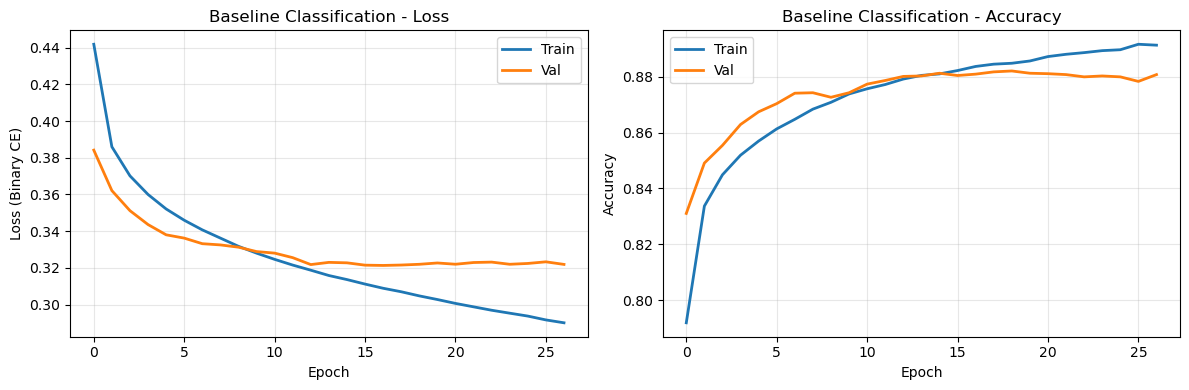

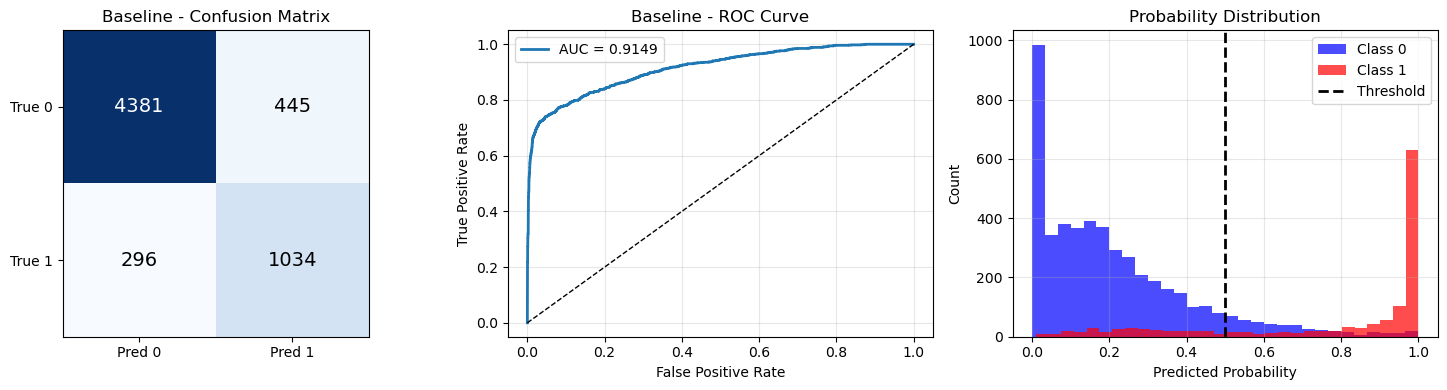

In [97]:
print("\n" + "_" * 70)
print("\n" + " BASELINE CLASSIFICATION MLP")
print("_" * 70)

# Create baseline classification MLP with 2 hidden layers (64 and 32 neurons)
baseline_clf = build_clf_mlp([64, 32])  # Function builds classification MLP with specified architecture
print("\n Architecture:")
baseline_clf.summary()  

print("\n Training...")  # train the model
# train_and_eval_clf trains and evaluates classification model, returns history and results
# verbose=1 shows training progress with progress bar
baseline_clf_history, baseline_clf_results = train_and_eval_clf(baseline_clf, verbose=1)

# print classification metrics (accuracy, precision, recall, F1)
print_clf_metrics(baseline_clf_results, "Baseline [64, 32]")

# plot training history (loss and accuracy curves)
plot_clf_history(baseline_clf_history, "Baseline Classification")

# plot evaluation metrics (confusion matrix, ROC curve, etc.)
plot_clf_evaluation(baseline_clf, "Baseline")

The baseline MLP with two hidden layers showed clear trends during training. Accuracy and loss improved quickly in the first few epochs, indicating that the network could capture the main patterns in the data efficiently. After this initial phase, the improvements became slower and eventually plateaued, suggesting that the model had reached its capacity for learning from the dataset. The training loss continued to decrease steadily, while the validation loss leveled off, which shows that the network was fitting the training data well without drastically overfitting. Overall, the moderate architecture provided sufficient capacity to learn the data while maintaining a good balance between underfitting and overfitting.

In terms of performance, the model achieved strong and consistent results across training, validation, and test sets, with high accuracy, precision, recall, F1, and AUC scores. The relatively small gap between training and validation performance indicates that the model generalized well to unseen data. Training time per epoch was very low due to the compact size of the network, and most of the learning happened early on, showing diminishing returns in later epochs. These results suggest that for a dataset of this complexity, a simple MLP is sufficient to achieve near-optimal performance efficiently, without the need for larger or deeper architectures.


## PART B.1: TRAINING & OPTIMIZATION (Classification)

### B.1.1 Optimizers


______________________________________________________________________

OPTIMIZERS (Classification)
______________________________________________________________________

  SGD...
   Train - Acc: 0.9015, Prec: 0.7471, Rec: 0.8251, F1: 0.7842, AUC: 0.9521
   Val   - Acc: 0.8741,Prec: 0.6871, Rec: 0.7662, F1: 0.7245, AUC: 0.9062

  SGD + Momentum...
   Train - Acc: 0.9107, Prec: 0.7567, Rec: 0.8670, F1: 0.8081, AUC: 0.9660
   Val   - Acc: 0.8517,Prec: 0.6350, Rec: 0.7376, F1: 0.6824, AUC: 0.8890

  Adam...
   Train - Acc: 0.9168, Prec: 0.7783, Rec: 0.8617, F1: 0.8179, AUC: 0.9694
   Val   - Acc: 0.8619,Prec: 0.6624, Rec: 0.7361, F1: 0.6973, AUC: 0.8897


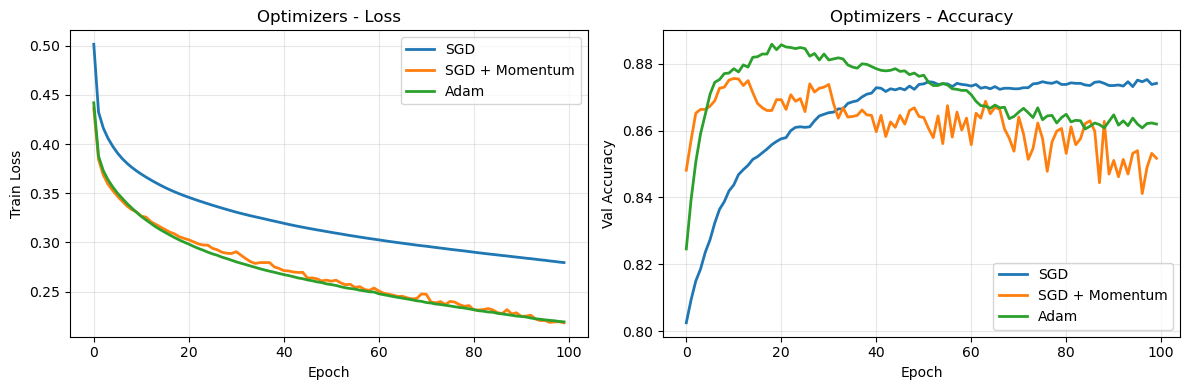

In [93]:
print("\n" + "_" * 70)
print("\n" + "OPTIMIZERS (Classification)")
print("_" * 70)

# test different optimizers for classification task
optimizer_configs_clf = {
    'SGD': SGD(learning_rate=0.01),                 
    'SGD + Momentum': SGD(learning_rate=0.01, momentum=0.9),  
    'Adam': Adam(learning_rate=0.001)             
}

opt_clf_results = {}      # results for each optimizer
opt_clf_histories = {}    # training history for each optimizer

# loop through each optimizer:
for name, opt in optimizer_configs_clf.items():
    print(f"\n  {name}...")
    
    # build classification MLP 
    model = build_clf_mlp([64, 32], optimizer=opt)
    
    # train and evaluate model
    # I set use_early_stop=False to see full training dynamics
    # epochs=60 for classification (typically needs fewer epochs than regression)
    history, results = train_and_eval_clf(model, use_early_stop=False, epochs=100)
    
    # results
    opt_clf_results[name] = results
    opt_clf_histories[name] = history
    
    # print training metrics
    print(f"   Train - Acc: {results['train_accuracy']:.4f}, Prec: {results['train_precision']:.4f}, Rec: {results['train_recall']:.4f}, F1: {results['train_f1']:.4f}, AUC: {results['train_auc']:.4f}")
    
    # print validation metrics
    print(f"   Val   - Acc: {results['val_accuracy']:.4f},Prec: {results['val_precision']:.4f}, Rec: {results['val_recall']:.4f}, F1: {results['val_f1']:.4f}, AUC: {results['val_auc']:.4f}")

# plot optimizer comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left plot: Training loss curves
for name, hist in opt_clf_histories.items():
    axes[0].plot(hist.history['loss'], label=name, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Train Loss')
axes[0].set_title('Optimizers - Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# right plot: Validation accuracy curves
for name, hist in opt_clf_histories.items():
    axes[1].plot(hist.history['val_accuracy'], label=name, linewidth=2)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy')
axes[1].set_title('Optimizers - Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

I compared different optimizers on the same classification task and observed distinct trends in training and validation behavior. Using plain SGD led to steady and balanced learning, with good training and validation accuracy and reasonably consistent precision, recall, and F1 scores. Adding momentum improved our training performance by allowing the network to converge faster and achieve higher accuracy and F1 on the training set. However, this also increased overfitting, as evidenced by a larger drop in validation performance compared to training. Adam showed the fastest and most stable convergence, achieving the highest training metrics overall, though it still exhibited some gap between training and validation, indicating mild overfitting.

### B.1.2 Learning Rate

In [ ]:
print("\n" + "_" * 70)
print("\n" + "LEARNING RATE (Classification)")
print("_" * 70)

# test different learning rates for classification task
lr_configs_clf = {
    'Too Small (1e-5)': 1e-5,  
    'Small (1e-4)': 1e-4,      
    'Good (1e-3)': 1e-3,       
    'Too Large (1e-1)': 1e-1   
}

lr_clf_results = {}      # results for each learning rate
lr_clf_histories = {}    # training history for each learning rate

# loop each learning rate
for name, lr in lr_configs_clf.items():
    print(f"\n   {name}...")
    
    # MLP with Adam optimizer and specific learning rate
    model = build_clf_mlp([64, 32], optimizer=Adam(learning_rate=lr))
    
    # train and evaluate model
    # again use_early_stop=False to see full effect of learning rate
    # epochs=100 for classification, adjust if you need 
    history, results = train_and_eval_clf(model, use_early_stop=False, epochs=100)
    
    # Store results
    lr_clf_results[name] = results
    lr_clf_histories[name] = history
    
    # see metrics
    print(f"   Train - Acc: {results['train_accuracy']:.4f}, Prec: {results['train_precision']:.4f}, Rec: {results['train_recall']:.4f}, F1: {results['train_f1']:.4f}, AUC: {results['train_auc']:.4f}")
    print(f"   Val   - Acc: {results['val_accuracy']:.4f},Prec: {results['val_precision']:.4f}, Rec: {results['val_recall']:.4f}, F1: {results['val_f1']:.4f}, AUC: {results['val_auc']:.4f}")

# Plot learning rate comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Training loss on logarithmic scale
for name, hist in lr_clf_histories.items():
    axes[0].semilogy(hist.history['loss'], label=name, linewidth=2)

axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log)')  # Logarithmic y-axis
axes[0].set_title('Learning Rate - Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: Validation accuracy on linear scale
for name, hist in lr_clf_histories.items():
    axes[1].plot(hist.history['val_accuracy'], label=name, linewidth=2)

axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val Accuracy')  
axes[1].set_title('Learning Rate - Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

as you see with a very small learning rate, the model learned slowly and underfit the data, showing modest accuracy and F1 scores on both training and validation sets. Increasing the learning rate to a small but reasonable value improved both convergence and overall performance, with higher accuracy and more balanced precision and recall. Using a good learning rate allowed the model to achieve the best training performance, though the validation scores showed some gap, indicating mild overfitting. In contrast, an excessively large learning rate caused the model to fail completely, with near-random performance and no meaningful learning.

### B.1.3 Learning Rate Scheduling


______________________________________________________________________

 LEARNING RATE SCHEDULING (Classification)
______________________________________________________________________

  No Schedule...
    Train - ACC: 0.9362, Prec: 0.9145, Rec: 0.7787, F1: 0.8411, AUC: 0.9376
    Val   - ACC: 0.9102, Prec: 0.8548, Rec: 0.7038, F1: 0.7720, AUC: 0.8921

  Step Decay...
    Train - ACC: 0.9454, Prec: 0.9008, Rec: 0.8407, F1: 0.8697, AUC: 0.9637
    Val   - ACC: 0.8972, Prec: 0.7826, Rec: 0.7256, F1: 0.7530, AUC: 0.8947

  ReduceOnPlateau...
    Train - ACC: 0.9421, Prec: 0.9018, Rec: 0.8226, F1: 0.8604, AUC: 0.9554
    Val   - ACC: 0.9048, Prec: 0.8110, Rec: 0.7293, F1: 0.7680, AUC: 0.9052


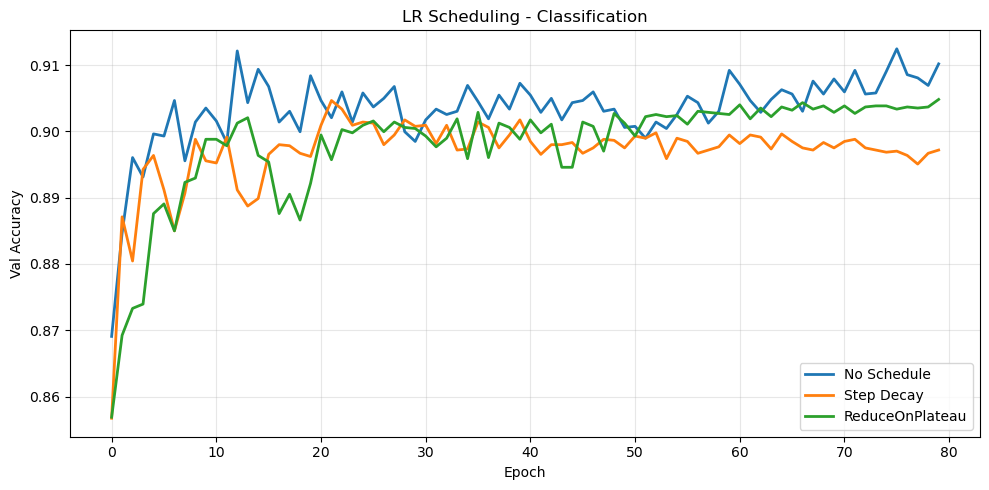

In [97]:
print("\n" + "_" * 70)
print("\n" + " LEARNING RATE SCHEDULING (Classification)")
print("_" * 70)

# define step decay schedule function
# eeduces learning rate by 50% every 20 epochs
def step_decay_clf(epoch):
    return 0.01 * (0.5 ** (epoch // 20))  

# now test different learning rate scheduling strategies for classification
schedule_configs_clf = {
    'No Schedule': None,  # Baseline: constant learning rate
    'Step Decay': callbacks.LearningRateScheduler(step_decay_clf),  # our predefined step decay
    'ReduceOnPlateau': callbacks.ReduceLROnPlateau(  
        monitor='val_loss',  
        factor=0.5,         # reduce LR by 50% when triggered
        patience=10,        # wait 10 epochs without improvement
        min_lr=1e-6,        
        verbose=0           
    )
}

sched_clf_results = {}      # results for each scheduler
sched_clf_histories = {}    # Save training history 

# loop:
for name, scheduler in schedule_configs_clf.items():
    print(f"\n  {name}...")
    
    # MLP with high initial learning rate (0.01)
    model = build_clf_mlp([64, 32], optimizer=Adam(learning_rate=0.01))
    
    # Prepare callback list: include scheduler if provided
    cb_list = [scheduler] if scheduler else []
    
    # train model with specified scheduler callback
    history = model.fit(
        X_train_clf, y_train_clf,                   
        validation_data=(X_val_clf, y_val_clf),       
        epochs=80,                                   
        batch_size=BATCH_SIZE,                       
        callbacks=cb_list,                          
        class_weight=class_weight_dict,             
        verbose=0                                    
    )

    sched_clf_results[name] = evaluate_clf_model(model)
    sched_clf_histories[name] = history
    
    # now get results for current scheduler
    res0 = sched_clf_results[name]
    print(f"    Train - ACC: {res0['train_accuracy']:.4f}, Prec: {res0['train_precision']:.4f}, Rec: {res0['train_recall']:.4f}, F1: {res0['train_f1']:.4f}, AUC: {res0['train_auc']:.4f}")
    print(f"    Val   - ACC: {res0['val_accuracy']:.4f}, Prec: {res0['val_precision']:.4f}, Rec: {res0['val_recall']:.4f}, F1: {res0['val_f1']:.4f}, AUC: {res0['val_auc']:.4f}")

# Plot scheduling comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Plot validation accuracy curves for each scheduling strategy
for name, hist in sched_clf_histories.items():
    ax.plot(hist.history['val_accuracy'], label=name, linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Val Accuracy')
ax.set_title('LR Scheduling - Classification')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Without any schedule, the model achieved strong training accuracy and F1 scores, but the validation performance showed a modest gap, indicating some overfitting. Using step decay increased training accuracy and F1 further, yet validation performance slightly dropped, suggesting that aggressive decay can sometimes lead to overfitting on the training set. Reduce-on-plateau provided a balanced improvement, maintaining high training performance while slightly improving validation metrics compared to the other strategies. Overall, I see that applying a learning rate schedule can help control convergence, manage overfitting, and improve generalization, with adaptive strategies like reduce-on-plateau offering a good balance between training efficiency and validation stability

### B.1.4: BATCH SIZE


______________________________________________________________________

BATCH SIZE (Classification)
______________________________________________________________________

  Batch Size = 8...
   Train - Acc: 0.9024, Prec: 0.7554, Rec: 0.8130, F1: 0.7832, AUC: 0.9469
   Val   - Acc: 0.8796,Prec: 0.7061, Rec: 0.7586, F1: 0.7314, AUC: 0.9098

  Batch Size = 32...
   Train - Acc: 0.9105, Prec: 0.7867, Rec: 0.8053, F1: 0.7959, AUC: 0.9493
   Val   - Acc: 0.8811,Prec: 0.7148, Rec: 0.7481, F1: 0.7311, AUC: 0.9034

  Batch Size = 128...
   Train - Acc: 0.9084, Prec: 0.7664, Rec: 0.8306, F1: 0.7972, AUC: 0.9576
   Val   - Acc: 0.8791,Prec: 0.7032, Rec: 0.7624, F1: 0.7316, AUC: 0.9105

  Batch Size = 256...
   Train - Acc: 0.9076, Prec: 0.7663, Rec: 0.8253, F1: 0.7947, AUC: 0.9570
   Val   - Acc: 0.8816,Prec: 0.7112, Rec: 0.7609, F1: 0.7352, AUC: 0.9050


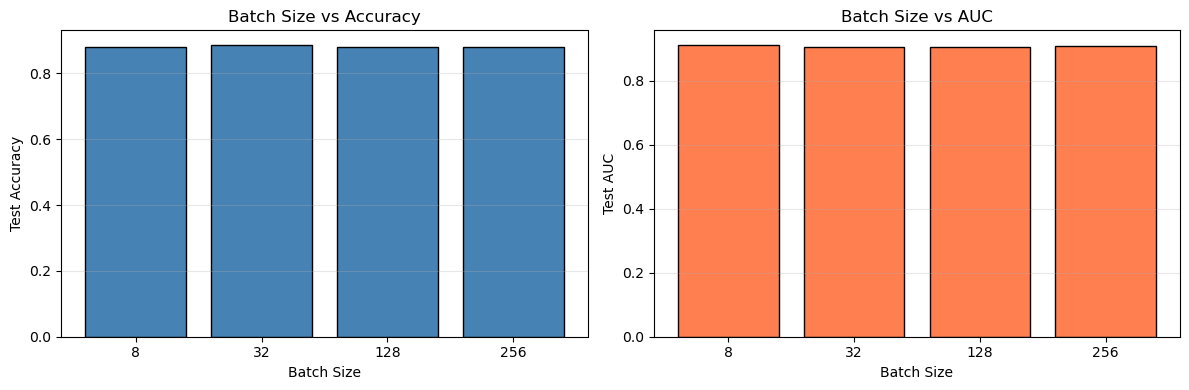

In [99]:
print("\n" + "_" * 70)
print("\n" + "BATCH SIZE (Classification)")
print("_" * 70)

# Test different batch sizes for classification task
batch_sizes_clf = [8, 32, 128, 256]  
bs_clf_results = {}  

# Loop 
for bs in batch_sizes_clf:
    print(f"\n  Batch Size = {bs}...")
    
    # MLP with default architecture
    model = build_clf_mlp([64, 32])
    
    # then train and evaluate model with specific batch size
    # train_and_eval_clf returns history and results
    _, results = train_and_eval_clf(model, batch_size=bs)
    
    # Save results for this batch size
    bs_clf_results[bs] = results
    print(f"   Train - Acc: {results['train_accuracy']:.4f}, Prec: {results['train_precision']:.4f}, Rec: {results['train_recall']:.4f}, F1: {results['train_f1']:.4f}, AUC: {results['train_auc']:.4f}")
    print(f"   Val   - Acc: {results['val_accuracy']:.4f},Prec: {results['val_precision']:.4f}, Rec: {results['val_recall']:.4f}, F1: {results['val_f1']:.4f}, AUC: {results['val_auc']:.4f}")

# batch size comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Test Accuracy vs Batch Size
axes[0].bar([str(bs) for bs in bs_clf_results.keys()], 
            [bs_clf_results[bs]['test_accuracy'] for bs in bs_clf_results.keys()],
            color='steelblue', edgecolor='black')

axes[0].set_xlabel('Batch Size')
axes[0].set_ylabel('Test Accuracy')  
axes[0].set_title('Batch Size vs Accuracy')
axes[0].grid(True, alpha=0.3, axis='y')  

# Right plot: Test AUC vs Batch Size
axes[1].bar([str(bs) for bs in bs_clf_results.keys()], 
            [bs_clf_results[bs]['test_auc'] for bs in bs_clf_results.keys()],
            color='coral', edgecolor='black')

axes[1].set_xlabel('Batch Size')
axes[1].set_ylabel('Test AUC')  
axes[1].set_title('Batch Size vs AUC')
axes[1].grid(True, alpha=0.3, axis='y')  
plt.tight_layout()
plt.show()

I tested different batch sizes to see how they influence training dynamics and model performance. Smaller batches allowed the model to update weights more frequently, which led to slightly faster initial learning and stable generalization, while larger batches produced smoother gradients and more consistent training metrics. Very small batches sometimes introduced more noise, which slightly affected stability but helped the model avoid overfitting. Moderate to large batch sizes achieved similar validation performance, indicating that the model was able to generalize well regardless of batch size, while training accuracy and efficiency showed minor variations.

### B.1.5 Early Stopping


______________________________________________________________________

 EARLY STOPPING (Classification)
______________________________________________________________________

  WITHOUT Early Stopping (100 epochs)...
   WITH Early Stopping...

   Comparison:
     Config                    Set    Prec     Rec      F1       AUC      ACC     
     -----------------------------------------------------------------
     Without Early Stopping    Train  0.8439   0.9553   0.8962   0.9914  0.9520  
                               Val    0.6475   0.7293   0.6860   0.8802  0.8558  
     With Early Stopping       Train  0.7761   0.8088   0.7921   0.9496  0.9079  
                               Val    0.7182   0.7436   0.7307   0.9063  0.8816  


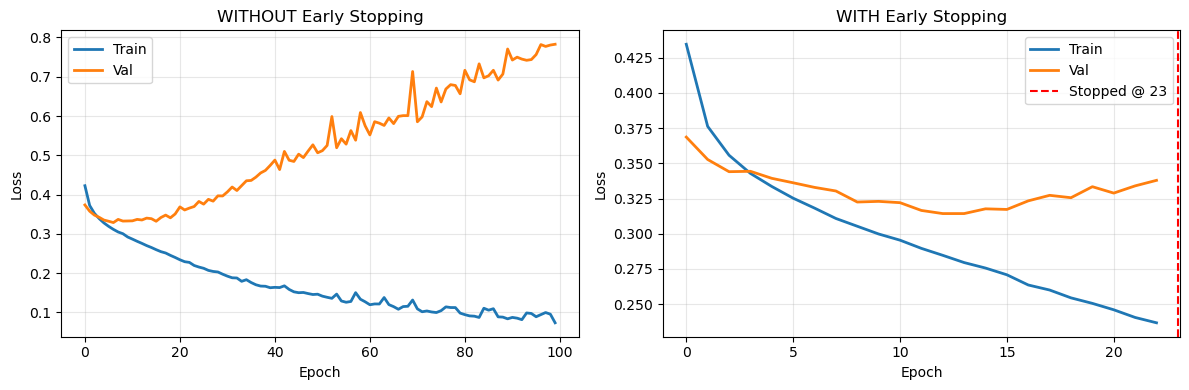

In [101]:
print("\n" + "_" * 70)
print("\n" + " EARLY STOPPING (Classification)")
print("_" * 70)

# WITHOUT early stopping 
print("\n  WITHOUT Early Stopping (100 epochs)...")
# Create deeper model 
model_no_es_clf = build_clf_mlp([128, 64, 32])

# train for full 100 epochs without early stopping
history_no_es_clf = model_no_es_clf.fit(
    X_train_clf, y_train_clf,                    
    validation_data=(X_val_clf, y_val_clf),       
    epochs=100,                                   
    batch_size=BATCH_SIZE,                        
    class_weight=class_weight_dict,             
    verbose=0                                    
)
results_no_es_clf = evaluate_clf_model(model_no_es_clf)  # evaluate performance

# WITH early stopping 
print("   WITH Early Stopping...")
model_with_es_clf = build_clf_mlp([128, 64, 32])

# configure early stopping callback
# PATIENCE is predefined constant (like 20)
es_clf = callbacks.EarlyStopping(monitor='val_loss',       
                                 patience=PATIENCE,         # Wait PATIENCE epochs without improvement
                                 restore_best_weights=True, # Load weights from best epoch
                                 verbose=0)                 

# now train with early stopping
history_with_es_clf = model_with_es_clf.fit(
    X_train_clf, y_train_clf,
    validation_data=(X_val_clf, y_val_clf),
    epochs=100,                     
    batch_size=BATCH_SIZE,
    callbacks=[es_clf],             # Early stopping callback
    class_weight=class_weight_dict,
    verbose=0
)
results_with_es_clf = evaluate_clf_model(model_with_es_clf)

# then get actual number of epochs trained before early stopping
stopped_epoch_clf = len(history_with_es_clf.history['loss'])

# detailed comparison table
print(f"\n   Comparison:")
print(f"     {'Config':<25} {'Set':<6} {'Prec':<8} {'Rec':<8} {'F1':<8} {'AUC':<8} {'ACC':<8}")
print(f"     {'-'*65}")

# Loop through both configurations
for config_name, res in [('Without Early Stopping', results_no_es_clf), 
                          ('With Early Stopping', results_with_es_clf)]:
    print(f"     {config_name:<25} {'Train':<6} {res['train_precision']:<8.4f} {res['train_recall']:<8.4f} {res['train_f1']:<8.4f} {res['train_auc']:<8.4f}{res['train_accuracy']:<8.4f}")
    print(f"     {'':<25} {'Val':<6} {res['val_precision']:<8.4f} {res['val_recall']:<8.4f} {res['val_f1']:<8.4f} {res['val_auc']:<8.4f}{res['val_accuracy']:<8.4f}")

# plot comparison of training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: WITHOUT early stopping
axes[0].plot(history_no_es_clf.history['loss'], label='Train', linewidth=2)
axes[0].plot(history_no_es_clf.history['val_loss'], label='Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('WITHOUT Early Stopping')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right plot: WITH early stopping
axes[1].plot(history_with_es_clf.history['loss'], label='Train', linewidth=2)
axes[1].plot(history_with_es_clf.history['val_loss'], label='Val', linewidth=2)
# Add vertical line showing where training stopped:
axes[1].axvline(stopped_epoch_clf, color='r', linestyle='--', label=f'Stopped @ {stopped_epoch_clf}')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('WITH Early Stopping')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Without early stopping, the model continued training for the full number of epochs, achieving very high training accuracy and F1 scores, but the validation performance lagged behind, indicating overfitting. With early stopping, the model halted training once validation metrics stopped improving, which slightly reduced training performance but improved validation accuracy and F1 scores

### B.1.6 Number of Epochs


______________________________________________________________________

NUMBER OF EPOCHS (Classification)
______________________________________________________________________

   10 epochs...
    Train - ACC: 0.8821, Prec: 0.6994, Rec: 0.8000, F1: 0.7463, AUC: 0.9344
    Val   - ACC: 0.8668, Prec: 0.6656, Rec: 0.7707, F1: 0.7143, AUC: 0.9072

   25 epochs...
    Train - ACC: 0.9053, Prec: 0.7675, Rec: 0.8078, F1: 0.7871, AUC: 0.9473
    Val   - ACC: 0.8793, Prec: 0.7054, Rec: 0.7579, F1: 0.7307, AUC: 0.9102

   50 epochs...
    Train - ACC: 0.9109, Prec: 0.7728, Rec: 0.8341, F1: 0.8023, AUC: 0.9596
    Val   - ACC: 0.8691, Prec: 0.6785, Rec: 0.7489, F1: 0.7119, AUC: 0.8958

   100 epochs...
    Train - ACC: 0.9091, Prec: 0.7441, Rec: 0.8851, F1: 0.8085, AUC: 0.9718
    Val   - ACC: 0.8468, Prec: 0.6215, Rec: 0.7444, F1: 0.6774, AUC: 0.8868


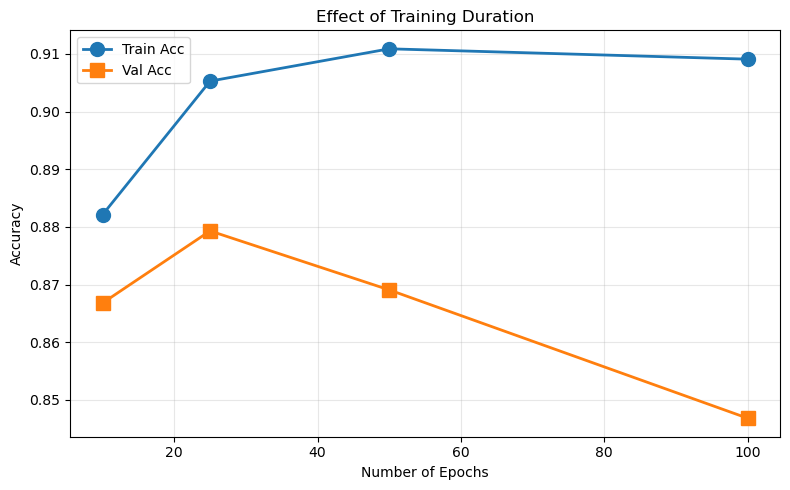

In [103]:
print("\n" + "_" * 70)
print("\n" + "NUMBER OF EPOCHS (Classification)")
print("_" * 70)

# different training epochs for classification
epoch_configs_clf = [10, 25, 50, 100]  

epoch_clf_results = {}  # results for each epoch 

# Loop through each epoch
for n_epochs in epoch_configs_clf:
    print(f"\n   {n_epochs} epochs...")
    
    # MLP with default architecture
    model = build_clf_mlp([64, 32])
    
    # train model for specific number of epochs
    model.fit(X_train_clf, y_train_clf, 
              validation_data=(X_val_clf, y_val_clf),
              epochs=n_epochs,                  
              batch_size=BATCH_SIZE,            
              class_weight=class_weight_dict,   
              verbose=0)                        
    
    # performance
    epoch_clf_results[n_epochs] = evaluate_clf_model(model)
    res1 = epoch_clf_results[n_epochs]  # Get results for current epoch count

    print(f"    Train - ACC: {res1['train_accuracy']:.4f}, Prec: {res1['train_precision']:.4f}, Rec: {res1['train_recall']:.4f}, F1: {res1['train_f1']:.4f}, AUC: {res1['train_auc']:.4f}")
    print(f"    Val   - ACC: {res1['val_accuracy']:.4f}, Prec: {res1['val_precision']:.4f}, Rec: {res1['val_recall']:.4f}, F1: {res1['val_f1']:.4f}, AUC: {res1['val_auc']:.4f}")

# Plot effect of training duration on accuracy
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
epochs_list = list(epoch_clf_results.keys())  # List of epoch counts tested

# Plot training accuracy vs epochs
ax.plot(epochs_list, [epoch_clf_results[e]['train_accuracy'] for e in epochs_list], 
        'o-', label='Train Acc', linewidth=2, markersize=10)

# Plot validation accuracy vs epochs
ax.plot(epochs_list, [epoch_clf_results[e]['val_accuracy'] for e in epochs_list], 
        's-', label='Val Acc', linewidth=2, markersize=10)
ax.set_xlabel('Number of Epochs')  
ax.set_ylabel('Accuracy')          
ax.set_title('Effect of Training Duration')  
ax.legend()                    
ax.grid(True, alpha=0.3)        
plt.tight_layout()
plt.show()

a small number of epochs, the model showed moderate training and validation metrics, indicating that it had not fully captured the data patterns and was slightly underfitting. Increasing the number of epochs improved training performance and initially improved validation performance as well, showing that the model was learning more meaningful representations. However, training for too many epochs caused training metrics to continue improving while validation performance began to decline, revealing overfitting.

## PART B.2: ARCHITECTURE & REPRESENTATION (Classification)

### B.2.1 Depth


______________________________________________________________________

NETWORK DEPTH (Classification)
______________________________________________________________________

  1 Layer...
    Train - ACC: 0.8911, Prec: 0.7192, Rec: 0.8163, F1: 0.7647, AUC: 0.9441
    Val   - ACC: 0.8686, Prec: 0.6686, Rec: 0.7767, F1: 0.7186, AUC: 0.9081

  2 Layers...
    Train - ACC: 0.9029, Prec: 0.7696, Rec: 0.7880, F1: 0.7787, AUC: 0.9396
    Val   - ACC: 0.8837, Prec: 0.7241, Rec: 0.7459, F1: 0.7348, AUC: 0.9071

  3 Layers...
    Train - ACC: 0.9130, Prec: 0.7918, Rec: 0.8120, F1: 0.8018, AUC: 0.9512
    Val   - ACC: 0.8873, Prec: 0.7338, Rec: 0.7504, F1: 0.7420, AUC: 0.9031

  4 Layers...
    Train - ACC: 0.9171, Prec: 0.8176, Rec: 0.7952, F1: 0.8063, AUC: 0.9472
    Val   - ACC: 0.8907, Prec: 0.7525, Rec: 0.7361, F1: 0.7442, AUC: 0.9033


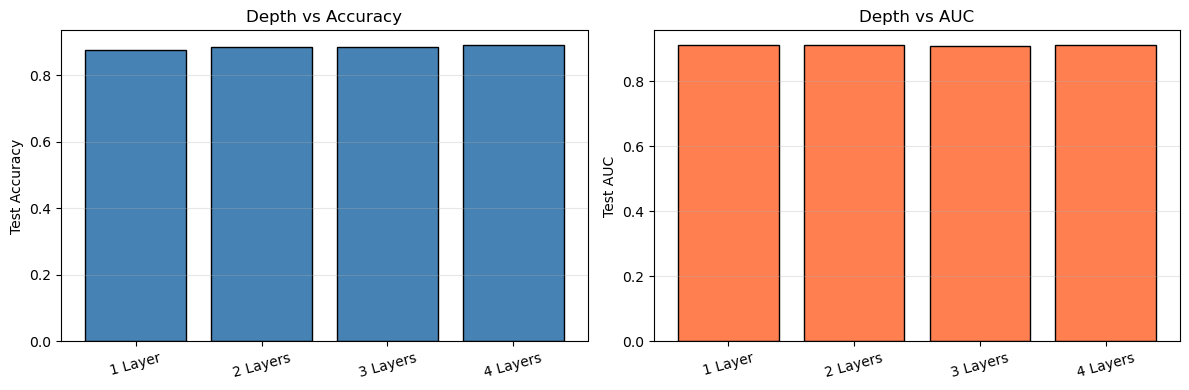

In [105]:
print("\n" + "_" * 70)
print("\n" + "NETWORK DEPTH (Classification)")
print("_" * 70)

# test different network depths (number of hidden layers) for classification
depth_configs_clf = {
    '1 Layer': [64],              
    '2 Layers': [64, 32],         
    '3 Layers': [64, 48, 32],     
    '4 Layers': [64, 48, 32, 16]  
}

depth_clf_results = {}  # evaluation results 

# Loop 
for name, layers_cfg in depth_configs_clf.items():
    print(f"\n  {name}...")
    
    # classification MLP with specified layer configuration
    model = build_clf_mlp(layers_cfg)
    
    # Train and evaluate model using standard training procedure
    # train_and_eval_clf returns history and results
    _, results = train_and_eval_clf(model)
    
    # results for this depth configuration
    depth_clf_results[name] = results
    print(f"    Train - ACC: {results['train_accuracy']:.4f}, Prec: {results['train_precision']:.4f}, Rec: {results['train_recall']:.4f}, F1: {results['train_f1']:.4f}, AUC: {results['train_auc']:.4f}")
    print(f"    Val   - ACC: {results['val_accuracy']:.4f}, Prec: {results['val_precision']:.4f}, Rec: {results['val_recall']:.4f}, F1: {results['val_f1']:.4f}, AUC: {results['val_auc']:.4f}")

# Plot depth comparison results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
names = list(depth_clf_results.keys())  

# Left plot: Test Accuracy vs Network Depth
axes[0].bar(names, [depth_clf_results[n]['test_accuracy'] for n in names], 
            color='steelblue', edgecolor='black')
axes[0].set_ylabel('Test Accuracy')  
axes[0].set_title('Depth vs Accuracy')
axes[0].tick_params(axis='x', rotation=15)  
axes[0].grid(True, alpha=0.3, axis='y')     

# Right plot: Test AUC vs Network Depth
axes[1].bar(names, [depth_clf_results[n]['test_auc'] for n in names], 
            color='coral', edgecolor='black')
axes[1].set_ylabel('Test AUC')  
axes[1].set_title('Depth vs AUC')
axes[1].tick_params(axis='x', rotation=15)  
axes[1].grid(True, alpha=0.3, axis='y')     
plt.tight_layout()
plt.show()

The shallowest network captured basic patterns but lacked the complexity to fully model the data, resulting in slightly lower accuracy and F1 on both training and validation sets. Adding more layers gradually improved training metrics, allowing the network to represent more complex relationships and capture subtler features. Validation performance also benefited, though the gains became smaller as the depth increased, suggesting diminishing returns in generalization beyond a certain number of layers.

### B.2.2 Width


______________________________________________________________________

NETWORK WIDTH (Classification)
______________________________________________________________________

  Narrow [16,8]...
    Params: 641
    Train - ACC: 0.8911, Prec: 0.7279, Rec: 0.7950, F1: 0.7600, AUC: 0.9330
    Val   - ACC: 0.8783, Prec: 0.6988, Rec: 0.7677, F1: 0.7316, AUC: 0.9130

  Medium [32,16]...
    Params: 1537
    Train - ACC: 0.9057, Prec: 0.7711, Rec: 0.8033, F1: 0.7869, AUC: 0.9455
    Val   - ACC: 0.8850, Prec: 0.7254, Rec: 0.7526, F1: 0.7387, AUC: 0.9073

  Wide [64,32]...
    Params: 4097
    Train - ACC: 0.9002, Prec: 0.7487, Rec: 0.8120, F1: 0.7791, AUC: 0.9497
    Val   - ACC: 0.8785, Prec: 0.7012, Rec: 0.7624, F1: 0.7305, AUC: 0.9077

  Very Wide [128,64]...
    Params: 12289
    Train - ACC: 0.9151, Prec: 0.7994, Rec: 0.8120, F1: 0.8057, AUC: 0.9570
    Val   - ACC: 0.8858, Prec: 0.7327, Rec: 0.7421, F1: 0.7374, AUC: 0.9027


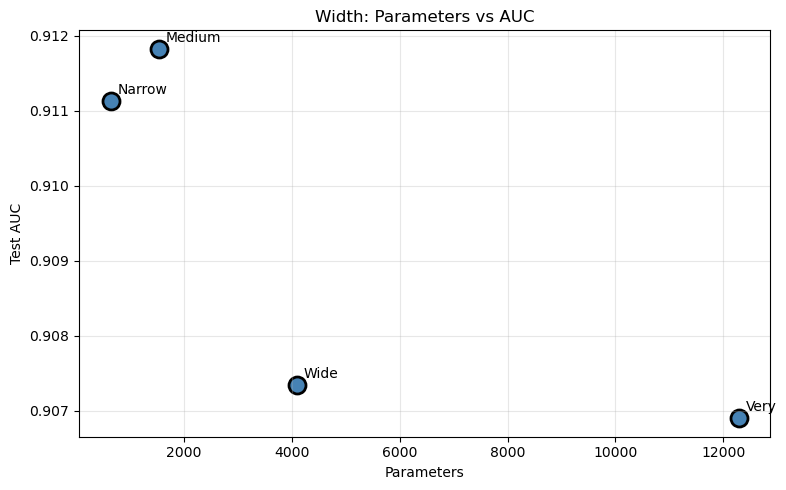

In [107]:
print("\n" + "_" * 70)
print("\n" + "NETWORK WIDTH (Classification)")
print("_" * 70)

# Test different network widths (number of neurons per layer) for classification
width_configs_clf = {
    'Narrow [16,8]': [16, 8],         
    'Medium [32,16]': [32, 16],       
    'Wide [64,32]': [64, 32],        
    'Very Wide [128,64]': [128, 64]   
}

width_clf_results = {}  #  results for each width 

# Loop 
for name, layers_cfg in width_configs_clf.items():
    print(f"\n  {name}...")
    
    # MLP with specified width 
    model = build_clf_mlp(layers_cfg)
    
    # Train 
    _, results = train_and_eval_clf(model)
    
    # Store results 
    width_clf_results[name] = results
    width_clf_results[name]['params'] = model.count_params()  # Total trainable parameters
    
    # Print parameter count and metrics
    print(f"    Params: {width_clf_results[name]['params']}")  # Model size/complexity
    print(f"    Train - ACC: {results['train_accuracy']:.4f}, Prec: {results['train_precision']:.4f}, Rec: {results['train_recall']:.4f}, F1: {results['train_f1']:.4f}, AUC: {results['train_auc']:.4f}")
    print(f"    Val   - ACC: {results['val_accuracy']:.4f}, Prec: {results['val_precision']:.4f}, Rec: {results['val_recall']:.4f}, F1: {results['val_f1']:.4f}, AUC: {results['val_auc']:.4f}")

# Plot width comparison: Parameters vs Performance
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
params = [width_clf_results[n]['params'] for n in width_clf_results.keys()]  # X-axis: parameter count
aucs = [width_clf_results[n]['test_auc'] for n in width_clf_results.keys()]   # Y-axis: test AUC

# Create scatter plot
ax.scatter(params, aucs, s=150, c='steelblue', edgecolors='black', linewidth=2)

# Annotate each point with configuration name (first word)
for i, name in enumerate(width_clf_results.keys()):
    ax.annotate(name.split()[0],  
                (params[i], aucs[i]), 
                textcoords="offset points", 
                xytext=(5,5))  
ax.set_xlabel('Parameters')      
ax.set_ylabel('Test AUC')        
ax.set_title('Width: Parameters vs AUC')  
ax.grid(True, alpha=0.3)         
plt.tight_layout()
plt.show()

From these observations it appears that moderate width provides a good balance between learning ability and generalization. Narrow networks risk underfitting, while extremely wide networks increase parameter count and computational cost without substantial improvement in validation outcomes. Adjusting width allows me to control the trade-off between representational power and efficiency, with moderate configurations often offering the most practical performance.

### B.2.3 Activation Functions


______________________________________________________________________

ACTIVATION FUNCTIONS (Classification)
______________________________________________________________________

   RELU...
    Train - Acc: 0.9095, Prec: 0.7752, Rec: 0.8206, F1: 0.7973, AUC: 0.9573
    Val   - Acc: 0.8778, Prec: 0.7061, Rec: 0.7444, F1: 0.7247, AUC: 0.9015

   TANH...
    Train - Acc: 0.9081, Prec: 0.7662, Rec: 0.8289, F1: 0.7963, AUC: 0.9559
    Val   - Acc: 0.8715, Prec: 0.6825, Rec: 0.7579, F1: 0.7182, AUC: 0.9044

   SIGMOID...
    Train - Acc: 0.9071, Prec: 0.7712, Rec: 0.8128, F1: 0.7914, AUC: 0.9491
    Val   - Acc: 0.8847, Prec: 0.7202, Rec: 0.7624, F1: 0.7407, AUC: 0.9123

   ELU...
    Train - Acc: 0.8890, Prec: 0.7077, Rec: 0.8311, F1: 0.7645, AUC: 0.9484
    Val   - Acc: 0.8642, Prec: 0.6557, Rec: 0.7820, F1: 0.7133, AUC: 0.9080

  LEAKYRELU...
    Train - ACC: 0.9046, Prec: 0.7635, Rec: 0.8115, F1: 0.7868, AUC: 0.9491
    Val   - ACC: 0.8811, Prec: 0.7097, Rec: 0.7609, F1: 0.7344, AUC:

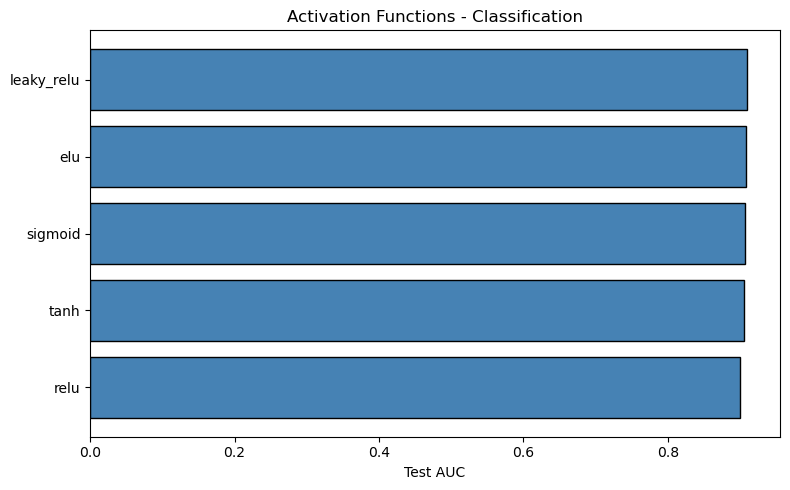

In [109]:
print("\n" + "_" * 70)
print("\n" + "ACTIVATION FUNCTIONS (Classification)")
print("_" * 70)

act_clf_results = {}  # results for each activation function

# Test standard activation functions that can be specified by string
for act in ['relu', 'tanh', 'sigmoid', 'elu']:
    print(f"\n   {act.upper()}...")
    
    # classification MLP 
    model = build_clf_mlp([64, 32], activation=act)
    
    # Train and evaluate
    _, results = train_and_eval_clf(model)
    act_clf_results[act] = results
    print(f"    Train - Acc: {results['train_accuracy']:.4f}, Prec: {results['train_precision']:.4f}, Rec: {results['train_recall']:.4f}, F1: {results['train_f1']:.4f}, AUC: {results['train_auc']:.4f}")
    print(f"    Val   - Acc: {results['val_accuracy']:.4f}, Prec: {results['val_precision']:.4f}, Rec: {results['val_recall']:.4f}, F1: {results['val_f1']:.4f}, AUC: {results['val_auc']:.4f}")

# special case: LeakyReLU (must be added as separate layer, not a string activation)
print(f"\n  LEAKYRELU...")

# Build model manually for LeakyReLU since it requires different construction
model = keras.Sequential([
    layers.Input(shape=(INPUT_DIM_CLF,)),  # Input layer
    layers.Dense(64, kernel_initializer='he_normal'),  # First hidden layer (no activation)
    layers.LeakyReLU(negative_slope=0.1),  # LeakyReLU activation layer (slope=0.1 for negative values)
    layers.Dense(32, kernel_initializer='he_normal'),  # Second hidden layer (no activation)
    layers.LeakyReLU(negative_slope=0.1),  # LeakyReLU activation layer
    layers.Dense(1, activation='sigmoid')  # Output layer with sigmoid for binary classification
])

# Compile model for binary classification
model.compile(optimizer=Adam(learning_rate=LR),  
              loss='binary_crossentropy',        
              metrics=['accuracy'])              

# Train model with early stopping
model.fit(X_train_clf, y_train_clf, 
          validation_data=(X_val_clf, y_val_clf),
          epochs=MAX_EPOCHS,                      
          batch_size=BATCH_SIZE,                 
          callbacks=[callbacks.EarlyStopping(      
              monitor='val_loss', 
              patience=PATIENCE,                   
              restore_best_weights=True, 
              verbose=0)],
          class_weight=class_weight_dict,         
          verbose=0)                              

# Evaluate LeakyReLU 
act_clf_results['leaky_relu'] = evaluate_clf_model(model)
res2 = act_clf_results['leaky_relu']  

# LeakyReLU metrics
print(f"    Train - ACC: {res2['train_accuracy']:.4f}, Prec: {res2['train_precision']:.4f}, Rec: {res2['train_recall']:.4f}, F1: {res2['train_f1']:.4f}, AUC: {res2['train_auc']:.4f}")
print(f"    Val   - ACC: {res2['val_accuracy']:.4f}, Prec: {res2['val_precision']:.4f}, Rec: {res2['val_recall']:.4f}, F1: {res2['val_f1']:.4f}, AUC: {res2['val_auc']:.4f}")

# Plot activation function comparison
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Horizontal bar chart showing test AUC for each activation function
ax.barh(list(act_clf_results.keys()),                    
        [act_clf_results[a]['test_auc'] for a in act_clf_results.keys()],  
        color='steelblue', edgecolor='black')
ax.set_xlabel('Test AUC')         
ax.set_title('Activation Functions - Classification')  
plt.tight_layout()
plt.show()

ReLU provided strong training metrics with slightly lower validation performance, indicating that it learned quickly but allowed some overfitting. Tanh achieved comparable training accuracy but a small drop in validation metrics, suggesting that its output range slightly limited generalization. Sigmoid produced balanced results between training and validation, showing good stability and slightly better generalization than ReLU or Tanh. ELU performed reasonably on training but had lower validation performance, suggesting it was less effective at capturing generalizable patterns for this task. LeakyReLU achieved training results similar to ReLU while slightly improving validation metrics, which indicates that it mitigated some overfitting while maintaining high representational power.

### B.2.4 Weight Initialization


______________________________________________________________________

WEIGHT INITIALIZATION (Classification)
______________________________________________________________________

--- Training with Random Normal initialization ---
    Train - Acc: 0.9118, Prec: 0.7931, Rec: 0.8023, F1: 0.7977, AUC: 0.9469
    Val   - Acc: 0.8912, Prec: 0.7419, Rec: 0.7609, F1: 0.7513, AUC: 0.9149

--- Training with Random Uniform initialization ---
    Train - Acc: 0.9154, Prec: 0.8136, Rec: 0.7910, F1: 0.8021, AUC: 0.9494
    Val   - Acc: 0.8920, Prec: 0.7529, Rec: 0.7444, F1: 0.7486, AUC: 0.9059

--- Training with Xavier/Glorot Uniform initialization ---
    Train - Acc: 0.9065, Prec: 0.7743, Rec: 0.8030, F1: 0.7884, AUC: 0.9477
    Val   - Acc: 0.8873, Prec: 0.7298, Rec: 0.7594, F1: 0.7443, AUC: 0.9110

--- Training with Xavier/Glorot Normal initialization ---
    Train - Acc: 0.8985, Prec: 0.7466, Rec: 0.8053, F1: 0.7748, AUC: 0.9441
    Val   - Acc: 0.8809, Prec: 0.7071, Rec: 0.7662, F1: 0.735

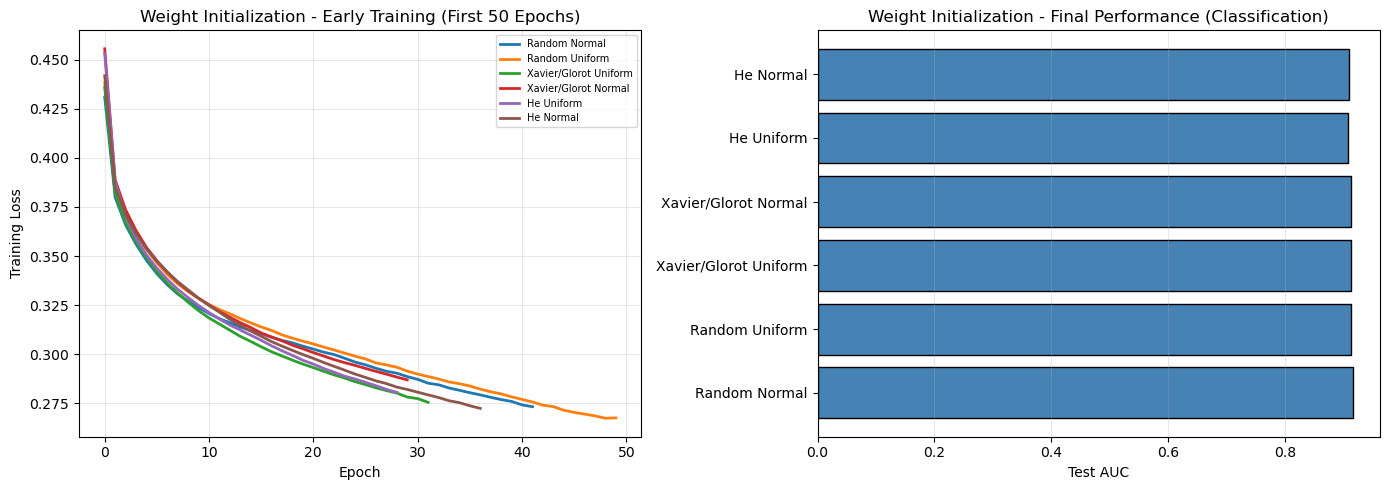


 Weight Initialization Comparison (Classification):
Initializer               Val Acc      Val Prec     Val Rec      Val F1       Val AUC      Test Acc     Test AUC    
------------------------------------------------------------------------------------------------------------------------
Random Normal             0.8912       0.7419       0.7609       0.7513       0.9149       0.8952       0.9173      
Random Uniform            0.8920       0.7529       0.7444       0.7486       0.9059       0.8949       0.9135      
Xavier/Glorot Uniform     0.8873       0.7298       0.7594       0.7443       0.9110       0.8878       0.9128      
Xavier/Glorot Normal      0.8809       0.7071       0.7662       0.7355       0.9127       0.8852       0.9138      
He Uniform                0.8780       0.7003       0.7609       0.7294       0.9100       0.8842       0.9086      
He Normal                 0.8761       0.6922       0.7677       0.7280       0.9097       0.8817       0.9094      


In [122]:
print("\n" + "_" * 70)
print("\n" + "WEIGHT INITIALIZATION (Classification)")
print("_" * 70)

# Test different weight initialization strategies for classification
init_configs_clf = {
    'Random Normal': 'random_normal',           
    'Random Uniform': 'random_uniform',         
    'Xavier/Glorot Uniform': 'glorot_uniform',  
    'Xavier/Glorot Normal': 'glorot_normal',    
    'He Uniform': 'he_uniform',                 
    'He Normal': 'he_normal',                   
}

init_clf_results = {}
init_clf_histories = {}

# Loop through each initialization method
for name, init in init_configs_clf.items():
    print(f"\n--- Training with {name} initialization ---")
    
    # Build classification MLP with specified weight initialization
    model = build_clf_mlp([64, 32], kernel_init=init)
    
    # Train and evaluate 
    history, results = train_and_eval_clf(model)
    
    # Store results
    init_clf_results[name] = results
    init_clf_histories[name] = history
    print(f"    Train - Acc: {results['train_accuracy']:.4f}, Prec: {results['train_precision']:.4f}, Rec: {results['train_recall']:.4f}, F1: {results['train_f1']:.4f}, AUC: {results['train_auc']:.4f}")
    print(f"    Val   - Acc: {results['val_accuracy']:.4f}, Prec: {results['val_precision']:.4f}, Rec: {results['val_recall']:.4f}, F1: {results['val_f1']:.4f}, AUC: {results['val_auc']:.4f}")

# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Training loss for first 50 epochs
for name, history in init_clf_histories.items():
    axes[0].plot(history.history['loss'][:50], label=name, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Training Loss')
axes[0].set_title('Weight Initialization - Early Training (First 50 Epochs)')
axes[0].legend(fontsize=7, loc='upper right')
axes[0].grid(True, alpha=0.3)

# Right plot: Final test performance comparison (AUC)
inits = list(init_clf_results.keys())
test_aucs = [init_clf_results[i]['test_auc'] for i in inits]
axes[1].barh(inits, test_aucs, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Test AUC')
axes[1].set_title('Weight Initialization - Final Performance (Classification)')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Print detailed comparison table
print("\n Weight Initialization Comparison (Classification):")
print(f"{'Initializer':<25} {'Val Acc':<12} {'Val Prec':<12} {'Val Rec':<12} {'Val F1':<12} {'Val AUC':<12} {'Test Acc':<12} {'Test AUC':<12}")
print("-" * 120)

# Loop through results and print formatted table
for name, results in init_clf_results.items():
    print(f"{name:<25} {results['val_accuracy']:<12.4f} {results['val_precision']:<12.4f} {results['val_recall']:<12.4f} {results['val_f1']:<12.4f} {results['val_auc']:<12.4f} {results['test_accuracy']:<12.4f} {results['test_auc']:<12.4f}")

From these results, it is clear that initialization impacts both convergence and the network’s ability to generalize. Methods like random uniform and Xavier/Glorot provide stable training while maintaining good performance on unseen data. He initialization allows rapid learning and strong training metrics, though its validation performance suggests that excessive weight scaling may introduce minor overfitting. Overall, careful selection of weight initialization can help balance efficient training and generalization.

### B.2.5 Batch Normalization


______________________________________________________________________

BATCH NORMALIZATION (Classification)
______________________________________________________________________

   No BatchNorm...
    Train - Acc: 0.9023, Prec: 0.7689, Rec: 0.7854, F1: 0.7771, AUC: 0.9375
    Val   - Acc: 0.8887, Prec: 0.7409, Rec: 0.7459, F1: 0.7433, AUC: 0.9096

   With BatchNorm...
    Train - Acc: 0.8952, Prec: 0.7449, Rec: 0.7854, F1: 0.7646, AUC: 0.9321
    Val   - Acc: 0.8774, Prec: 0.7049, Rec: 0.7436, F1: 0.7237, AUC: 0.9031


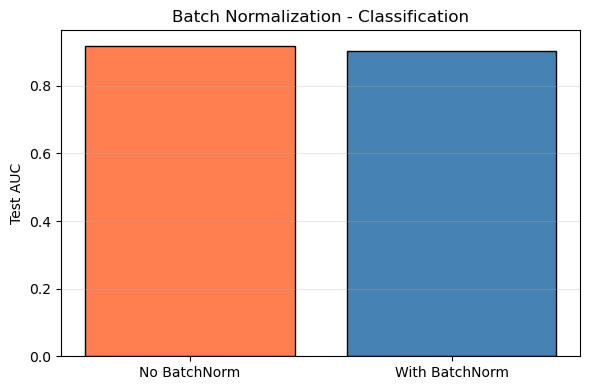

In [113]:
print("\n" + "_" * 70)
print("\n" + "BATCH NORMALIZATION (Classification)")
print("_" * 70)

bn_clf_results = {}  # save evaluation results for models with/without batch normalization

# Test with and without batch normalization
for use_bn in [False, True]:
    name = 'With BatchNorm' if use_bn else 'No BatchNorm'
    print(f"\n   {name}...")
    
    # MLP with 4 hidden layers
    model = build_clf_mlp([64, 48, 32, 16], batch_norm=use_bn)
    
    # Train and evaluate model
    _, results = train_and_eval_clf(model)
    
    # results
    bn_clf_results[name] = results
    print(f"    Train - Acc: {results['train_accuracy']:.4f}, Prec: {results['train_precision']:.4f}, Rec: {results['train_recall']:.4f}, F1: {results['train_f1']:.4f}, AUC: {results['train_auc']:.4f}")
    print(f"    Val   - Acc: {results['val_accuracy']:.4f}, Prec: {results['val_precision']:.4f}, Rec: {results['val_recall']:.4f}, F1: {results['val_f1']:.4f}, AUC: {results['val_auc']:.4f}")

# Plot batch normalization comparison
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Bar chart comparing test AUC with and without batch normalization
ax.bar(bn_clf_results.keys(),                              
       [bn_clf_results[n]['test_auc'] for n in bn_clf_results.keys()], 
       color=['coral', 'steelblue'],                        
       edgecolor='black')                                 
ax.set_ylabel('Test AUC')           
ax.set_title('Batch Normalization - Classification')  
ax.grid(True, alpha=0.3, axis='y')   
plt.tight_layout()
plt.show()

I compared the effects of including batch normalization in the network. Without batch normalization, the model achieved slightly higher training and validation accuracy and F1 scores, indicating that it could fit the data effectively. Adding batch normalization reduced training metrics modestly, and validation performance also decreased slightly, suggesting that it introduced a regularizing effect that prevented the model from fully exploiting its capacity.

## PART B.3: REGULARIZATION & STABILITY (Classification)

### B.3.1: L1/L2 Regularization


______________________________________________________________________

L1 / L2 REGULARIZATION (Classification)
______________________________________________________________________

  No Reg...
    Train-Val Gap: 0.0955, Val AUC: 0.8781
    Train - Acc: 0.9453, Prec: 0.8261, Rec: 0.9468, F1: 0.8824, AUC: 0.9898
    Val   - Acc: 0.8497, Prec: 0.6316, Rec: 0.7308, F1: 0.6776, AUC: 0.8781

  L1 (1e-4)...
    Train-Val Gap: 0.0493, Val AUC: 0.8877
    Train - Acc: 0.9218, Prec: 0.7931, Rec: 0.8647, F1: 0.8274, AUC: 0.9686
    Val   - Acc: 0.8725, Prec: 0.6912, Rec: 0.7406, F1: 0.7151, AUC: 0.8877

  L2 (1e-4)...
    Train-Val Gap: 0.0790, Val AUC: 0.8813
    Train - Acc: 0.9280, Prec: 0.7906, Rec: 0.9084, F1: 0.8454, AUC: 0.9789
    Val   - Acc: 0.8489, Prec: 0.6295, Rec: 0.7308, F1: 0.6764, AUC: 0.8813

  L1+L2...
    Train-Val Gap: 0.0449, Val AUC: 0.8939
    Train - Acc: 0.9247, Prec: 0.8217, Rec: 0.8336, F1: 0.8276, AUC: 0.9634
    Val   - Acc: 0.8798, Prec: 0.7163, Rec: 0.7346, F1:

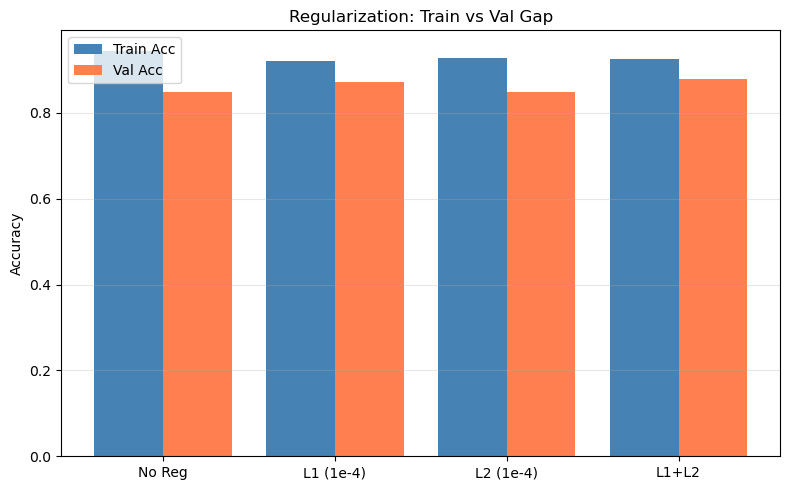

In [115]:
print("\n" + "_" * 70)
print("\n" + "L1 / L2 REGULARIZATION (Classification)")
print("_" * 70)

# different weight regularization for classification
reg_configs_clf = {
    'No Reg': None,                                       
    'L1 (1e-4)': regularizers.l1(1e-4),                   
    'L2 (1e-4)': regularizers.l2(1e-4),                   
    'L1+L2': regularizers.l1_l2(l1=1e-4, l2=1e-4)         
}

reg_clf_results = {}  #  results for each regularization method

# Loop
for name, reg in reg_configs_clf.items():
    print(f"\n  {name}...")
    
    # Build deeper classification MLP (3 hidden layers) more prone to overfitting
    model = build_clf_mlp([128, 64, 32], kernel_reg=reg)
    
    # Train model without early stopping to see full regularization effects
    model.fit(X_train_clf, y_train_clf, 
              validation_data=(X_val_clf, y_val_clf),
              epochs=MAX_EPOCHS,           
              batch_size=BATCH_SIZE,       
              class_weight=class_weight_dict,  
              verbose=0)                  
    
    # Evaluate 
    reg_clf_results[name] = evaluate_clf_model(model)# Get results for current regularization
    
    # Calculate generalization gap: difference between train and validation accuracy
    gap = abs(reg_clf_results[name]['train_accuracy'] - reg_clf_results[name]['val_accuracy'])
    print(f"    Train-Val Gap: {gap:.4f}, Val AUC: {reg_clf_results[name]['val_auc']:.4f}")
    
    res3 = reg_clf_results[name]
    print(f"    Train - Acc: {res3['train_accuracy']:.4f}, Prec: {res3['train_precision']:.4f}, Rec: {res3['train_recall']:.4f}, F1: {res3['train_f1']:.4f}, AUC: {res3['train_auc']:.4f}")
    print(f"    Val   - Acc: {res3['val_accuracy']:.4f}, Prec: {res3['val_precision']:.4f}, Rec: {res3['val_recall']:.4f}, F1: {res3['val_f1']:.4f}, AUC: {res3['val_auc']:.4f}")

# Plot regularization comparison
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

# Prepare data for bar chart
names = list(reg_clf_results.keys())  
train_accs = [reg_clf_results[n]['train_accuracy'] for n in names] 
val_accs = [reg_clf_results[n]['val_accuracy'] for n in names]      

x = np.arange(len(names))  

# Create side-by-side bars for train and validation accuracy
ax.bar(x - 0.2, train_accs, 0.4, label='Train Acc', color='steelblue')  
ax.bar(x + 0.2, val_accs, 0.4, label='Val Acc', color='coral')          
ax.set_xticks(x)                     
ax.set_xticklabels(names)             
ax.set_ylabel('Accuracy')            
ax.set_title('Regularization: Train vs Val Gap')  
ax.legend()                          
ax.grid(True, alpha=0.3, axis='y')    
plt.tight_layout()
plt.show()

Without any regularization, the model achieved very high training metrics but showed a significant gap to validation performance, indicating strong overfitting. Introducing L1 regularization reduced this gap and slightly improved validation metrics, suggesting that it encouraged sparsity and prevented the model from relying too heavily on individual weights. L2 regularization also reduced overfitting to some extent, though the validation improvements were smaller compared to L1. Combining L1 and L2 achieved the best balance, reducing the train-validation gap while slightly improving validation AUC, showing that the network could generalize more effectively without sacrificing too much training performance.

### B.3.2 Activity Regularization


______________________________________________________________________

ACTIVITY REGULARIZATION (Classification)
______________________________________________________________________

  No Activity Reg...
    Train - ACC: 0.9030, Prec: 0.7498, Rec: 0.8294, F1: 0.7876, AUC: 0.9547
    Val   - ACC: 0.8676, Prec: 0.6720, Rec: 0.7564, F1: 0.7117, AUC: 0.9043

  Activity L2 (1e-4)...
    Train - ACC: 0.9210, Prec: 0.8115, Rec: 0.8276, F1: 0.8195, AUC: 0.9617
    Val   - ACC: 0.8788, Prec: 0.7107, Rec: 0.7406, F1: 0.7253, AUC: 0.8996

  Activity L2 (1e-3)...
    Train - ACC: 0.9072, Prec: 0.7649, Rec: 0.8256, F1: 0.7941, AUC: 0.9507
    Val   - ACC: 0.8661, Prec: 0.6738, Rec: 0.7376, F1: 0.7042, AUC: 0.8960


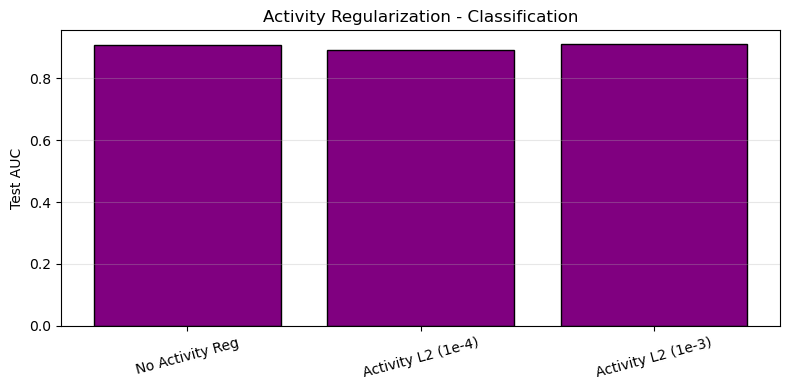

In [117]:
print("\n" + "_" * 70)
print("\n" + "ACTIVITY REGULARIZATION (Classification)")
print("_" * 70)

activity_configs_clf = {
    'No Activity Reg': None,                    
    'Activity L2 (1e-4)': regularizers.l2(1e-4),  
    'Activity L2 (1e-3)': regularizers.l2(1e-3)   
}

activity_clf_results = {}  # evaluation results for each activity regularization 

# Loop through them
for name, reg in activity_configs_clf.items():
    print(f"\n  {name}...")
    
    # MLP (3 hidden layers) with activity regularization
    model = build_clf_mlp([128, 64, 32], activity_reg=reg)
    
    # train and evaluate model
    _, results = train_and_eval_clf(model)
    
    # Save results
    activity_clf_results[name] = results
    print(f"    Train - ACC: {results['train_accuracy']:.4f}, Prec: {results['train_precision']:.4f}, Rec: {results['train_recall']:.4f}, F1: {results['train_f1']:.4f}, AUC: {results['train_auc']:.4f}")
    print(f"    Val   - ACC: {results['val_accuracy']:.4f}, Prec: {results['val_precision']:.4f}, Rec: {results['val_recall']:.4f}, F1: {results['val_f1']:.4f}, AUC: {results['val_auc']:.4f}")

# plot activity regularization 
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.bar(activity_clf_results.keys(),                              
       [activity_clf_results[n]['test_auc'] for n in activity_clf_results.keys()], 
       color='purple', edgecolor='black')                         
ax.set_ylabel('Test AUC')            
ax.set_title('Activity Regularization - Classification')  
ax.tick_params(axis='x', rotation=15)  
ax.grid(True, alpha=0.3, axis='y')     
plt.tight_layout()
plt.show()

Without any activity regularization, the model achieved solid training metrics but showed a moderate gap to validation performance, reflecting some overfitting. Adding a small L2 penalty on activations improved validation accuracy and F1 slightly while keeping training performance high, indicating that it helped the network generalize better. Increasing the regularization strength too much slightly reduced both training and validation performance, suggesting that excessive penalization can limit the model’s ability to represent patterns in the data.

### B.3.3 Dropout


______________________________________________________________________
DROPOUT (Classification)
______________________________________________________________________

  Dropout = 0.0...
    Train - ACC: 0.9530, Prec: 0.8669, Rec: 0.9255, F1: 0.8953, AUC: 0.9873
    Val   - ACC: 0.8632, Prec: 0.6784, Rec: 0.6977, F1: 0.6879, AUC: 0.8760

  Dropout = 0.2...
    Train - ACC: 0.9372, Prec: 0.8866, Rec: 0.8146, F1: 0.8491, AUC: 0.9671
    Val   - ACC: 0.9079, Prec: 0.8166, Rec: 0.7398, F1: 0.7763, AUC: 0.9119

  Dropout = 0.4...
    Train - ACC: 0.9328, Prec: 0.9244, Rec: 0.7516, F1: 0.8291, AUC: 0.9422
    Val   - ACC: 0.9207, Prec: 0.8920, Rec: 0.7203, F1: 0.7970, AUC: 0.9238

  Dropout = 0.6...
    Train - ACC: 0.9159, Prec: 0.8411, Rec: 0.7546, F1: 0.7955, AUC: 0.9320
    Val   - ACC: 0.9063, Prec: 0.8114, Rec: 0.7376, F1: 0.7727, AUC: 0.9222


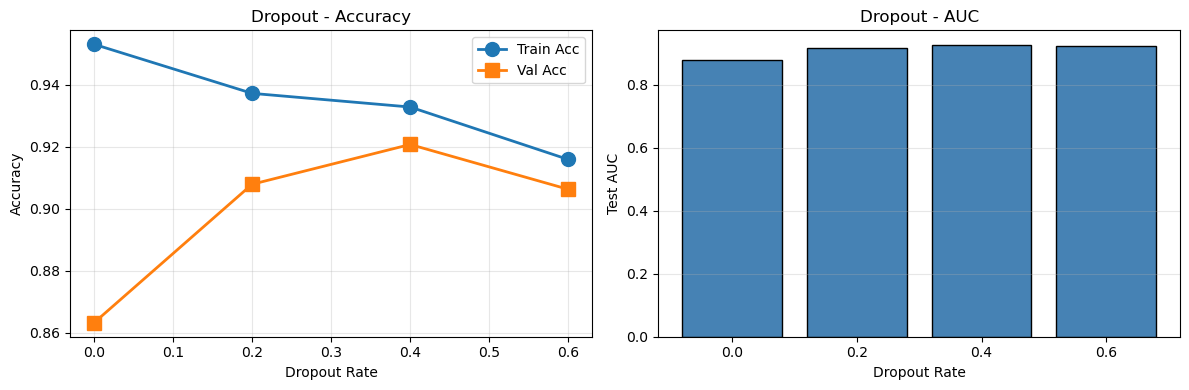

In [119]:
print("\n" + "_" * 70)
print("DROPOUT (Classification)")
print("_" * 70)

dropout_rates_clf = [0.0, 0.2, 0.4, 0.6] 
dropout_clf_results = {}  

# Loop through
for rate in dropout_rates_clf:
    print(f"\n  Dropout = {rate}...")
    
    # MLP (3 hidden layers) 
    model = build_clf_mlp([128, 64, 32], dropout_rate=rate)
    
    # Train model without early stopping 
    model.fit(X_train_clf, y_train_clf, 
              validation_data=(X_val_clf, y_val_clf),
              epochs=MAX_EPOCHS,           
              batch_size=BATCH_SIZE,       
              class_weight=class_weight_dict,  
              verbose=0)                  
    # test model
    dropout_clf_results[rate] = evaluate_clf_model(model)
    res4 = dropout_clf_results[rate]  # Get results for current dropout rate
    
    # metrics
    print(f"    Train - ACC: {res4['train_accuracy']:.4f}, Prec: {res4['train_precision']:.4f}, Rec: {res4['train_recall']:.4f}, F1: {res4['train_f1']:.4f}, AUC: {res4['train_auc']:.4f}")
    print(f"    Val   - ACC: {res4['val_accuracy']:.4f}, Prec: {res4['val_precision']:.4f}, Rec: {res4['val_recall']:.4f}, F1: {res4['val_f1']:.4f}, AUC: {res4['val_auc']:.4f}")

# Plot 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
rates = list(dropout_clf_results.keys())  # List of dropout rates tested

# Left plot: Accuracy vs Dropout Rate 
axes[0].plot(rates, [dropout_clf_results[r]['train_accuracy'] for r in rates], 
             'o-', label='Train Acc', linewidth=2, markersize=10)
axes[0].plot(rates, [dropout_clf_results[r]['val_accuracy'] for r in rates], 
             's-', label='Val Acc', linewidth=2, markersize=10)
axes[0].set_xlabel('Dropout Rate')        
axes[0].set_ylabel('Accuracy')           
axes[0].set_title('Dropout - Accuracy')   
axes[0].legend()                         
axes[0].grid(True, alpha=0.3)           

# Right plot: Test AUC vs Dropout Rate (bar chart)
axes[1].bar([str(r) for r in rates],                    
            [dropout_clf_results[r]['test_auc'] for r in rates],  
            color='steelblue', edgecolor='black')
axes[1].set_xlabel('Dropout Rate')       
axes[1].set_ylabel('Test AUC')           
axes[1].set_title('Dropout - AUC')       
axes[1].grid(True, alpha=0.3, axis='y')  
plt.tight_layout()
plt.show()

For dropout, I observed that removing it entirely led to very high training performance but poor validation results, showing clear overfitting. Introducing moderate dropout rates improved validation accuracy and F1 while slightly reducing training metrics, demonstrating that randomly dropping units during training encourages the network to learn more robust and generalizable features. Higher dropout rates continued to benefit validation performance up to a point, but extreme rates began to lower both training and validation metrics, indicating that too much dropout can hinder learning.

# Part C:

## 1. Why Are Neural Networks So Powerful?

Neural networks derive their power from several key properties:

### Compositional Feature Learning
- They automatically learn hierarchical representations from raw data  
- Lower layers detect simple patterns (edges, frequencies)  
- Higher layers compose these into complex concepts (faces, sentences)

### Universal Approximation
- Given sufficient neurons, they can approximate virtually any continuous function  
- This theoretical flexibility underlies their broad applicability

### Differentiability & Optimization
- End-to-end gradient-based learning allows all parameters to be jointly optimized  
- Backpropagation efficiently computes gradients across millions of parameters

### Scalability
- Performance tends to improve predictably with more data, compute, and parameters  
- They leverage parallel hardware (GPUs/TPUs) exceptionally well  

---

## 2. Why Does Training Become More Difficult with Depth?

Several challenges compound as networks grow deeper:

| Problem               | Description |
|----------------------|-------------|
| Vanishing Gradients  | Gradients shrink exponentially as they backpropagate through many layers, leaving early layers nearly untrained |
| Exploding Gradients  | Conversely, gradients can grow exponentially, causing unstable updates |
| Optimization Landscape | Deeper networks have more complex loss surfaces with saddle points and local minima |
| Signal Degradation   | Information can degrade or become distorted through many transformations |

### Modern Solutions
- Residual connections (skip connections)  
- Batch/Layer normalization  
- Careful initialization (He, Xavier)  
- Gradient clipping  

---

## 3. (Optional) Why Depth Over Width?

Even though a single wide hidden layer can theoretically approximate any function, depth provides unique advantages:

### Exponential Efficiency
- Deep networks can represent certain functions with exponentially fewer parameters than shallow ones  
- Example: A function requiring \(2^n\) neurons in a shallow network may need only \(O(n)\) neurons in a deep network

### Hierarchical Abstraction
- Real-world data has compositional structure (pixels → edges → shapes → objects)  
- Depth naturally mirrors this hierarchy; width cannot capture it as elegantly

### Feature Reuse
- Intermediate layers create reusable representations  
- A *“wheel detector”* can be shared across *“car,” “bicycle,”* and *“motorcycle”* concepts

### Inductive Bias
- Depth encodes a useful prior: complex concepts are built from simpler ones  
- This bias improves generalization, not just memorization


<div style="color: red;">
    
# Convolutional Neural Networks (CNNs)
    
</div>

In [13]:
# First we need to set up and import

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration (I only have CPU on my local system so I descided to do this to prevant anuy possible issue)
device = torch.device('cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cpu
PyTorch version: 2.9.1+cpu


## why MNIST?

Because the experiments are conducted using only a CPU on m system, the MNIST dataset is a practical and appropriate choice i think. MNIST’s small image resolution (28×28) and simple grayscale structure significantly reduces computational cost and allows CNNs to be trained within a reasonable time. since the goal is understanding CNN behavior and design trade offs I think it's a good choice

**important note**: MNIST images are originally grayscale (single channel) whereas most pretrained CNNs (including MobileNetV2 for part D) are trained on the ImageNet dataset which consists of RGB images with three color channels and a fixed input size of 224×224. To make MNIST compatible with these pretrained models I converted each grayscale image to a 3 channel image by duplicating the grayscale channel and then resized to the required input dimensions. This transformation does not add new color information but ensures architectural compatibility with pretrained weights. (go to part D)


______________________________________________________________________
Data loading and Preprocessing
______________________________________________________________________
Loading MNIST dataset...
Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])
Number of classes: 10


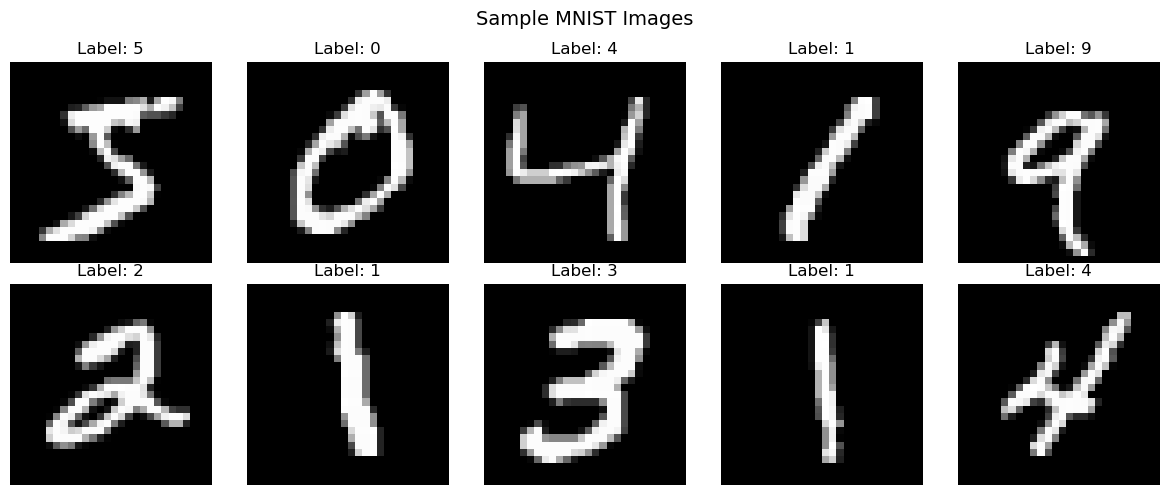

In [16]:
print("\n" + "_" * 70)
print("Data loading and Preprocessing")
print("_" * 70)

# Basic transforms (for our baseline and testing)
basic_transform = transforms.Compose([
    transforms.ToTensor(),  # Converts to tensor and scales to [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean and std
])

# Augmented transforms (for training with augmentation)
augmented_transform = transforms.Compose([
    transforms.RandomRotation(10),  # Random rotation ±10 degrees
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random translation
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# now we can load datasets
print("Loading MNIST dataset...")
train_dataset_basic = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=basic_transform
)
test_dataset = torchvision.datasets.MNIST(
    root='./data', train=False, download=True, transform=basic_transform
)

train_dataset_augmented = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=augmented_transform
)

# lets create data loaders
BATCH_SIZE = 64

train_loader_basic = DataLoader(train_dataset_basic, batch_size=BATCH_SIZE, shuffle=True)
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_dataset_basic)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset_basic[0][0].shape}")
print(f"Number of classes: {len(train_dataset_basic.classes)}")

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset_basic[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()


______________________________________________________________________
A: Build and Train a CNN
______________________________________________________________________
Training Baseline CNN

Model Architecture:
BaseCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)

Total parameters: 390,410
Epoch [1/10] Train Loss: 0.1881, Train Acc: 94.15%, Val Loss: 0.0445, Val Acc: 98.55%, Time: 22.96s
Epoch [2/10] Train Loss: 0.0595, Train Acc: 98.25%, Val Loss: 0.0259, Val Acc: 99.15%, Time: 23.30s
Epoch [3/10] Train Loss: 0.0430, Train Acc: 98.75%, Val Loss: 0.0231

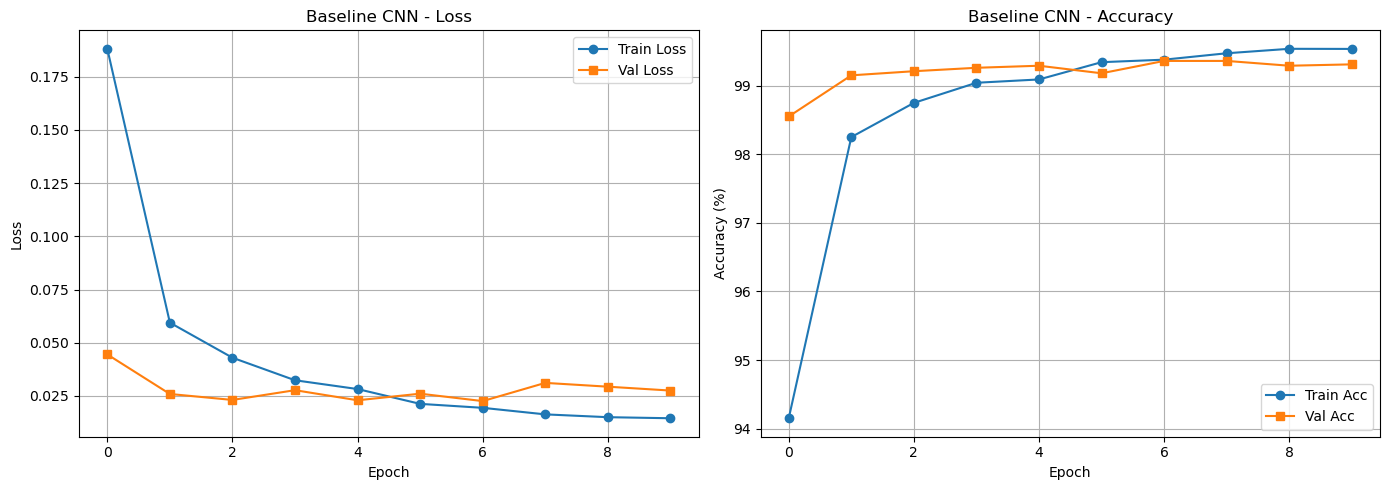


Classification Report:
              precision    recall  f1-score   support

           0     0.9949    0.9959    0.9954       980
           1     0.9956    0.9974    0.9965      1135
           2     0.9885    0.9952    0.9918      1032
           3     0.9931    0.9960    0.9946      1010
           4     0.9939    0.9980    0.9959       982
           5     0.9899    0.9922    0.9910       892
           6     0.9906    0.9948    0.9927       958
           7     0.9931    0.9864    0.9898      1028
           8     0.9969    0.9897    0.9933       974
           9     0.9940    0.9851    0.9895      1009

    accuracy                         0.9931     10000
   macro avg     0.9931    0.9931    0.9931     10000
weighted avg     0.9931    0.9931    0.9931     10000



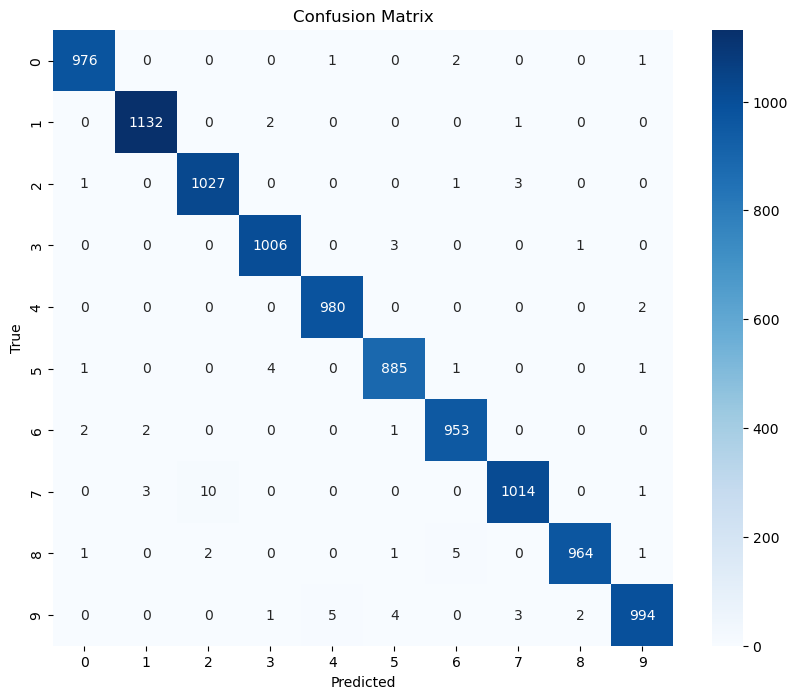

([7,
  2,
  1,
  0,
  4,
  1,
  4,
  9,
  5,
  9,
  0,
  6,
  9,
  0,
  1,
  5,
  9,
  7,
  3,
  4,
  9,
  6,
  6,
  5,
  4,
  0,
  7,
  4,
  0,
  1,
  3,
  1,
  3,
  4,
  7,
  2,
  7,
  1,
  2,
  1,
  1,
  7,
  4,
  2,
  3,
  5,
  1,
  2,
  4,
  4,
  6,
  3,
  5,
  5,
  6,
  0,
  4,
  1,
  9,
  5,
  7,
  8,
  9,
  3,
  7,
  4,
  6,
  4,
  3,
  0,
  7,
  0,
  2,
  9,
  1,
  7,
  3,
  2,
  9,
  7,
  7,
  6,
  2,
  7,
  8,
  4,
  7,
  3,
  6,
  1,
  3,
  6,
  9,
  3,
  1,
  4,
  1,
  7,
  6,
  9,
  6,
  0,
  5,
  4,
  9,
  9,
  2,
  1,
  9,
  4,
  8,
  7,
  3,
  9,
  7,
  4,
  4,
  4,
  9,
  2,
  5,
  4,
  7,
  6,
  7,
  9,
  0,
  5,
  8,
  5,
  6,
  6,
  5,
  7,
  8,
  1,
  0,
  1,
  6,
  4,
  6,
  7,
  3,
  1,
  7,
  1,
  8,
  2,
  0,
  2,
  9,
  9,
  5,
  5,
  1,
  5,
  6,
  0,
  3,
  4,
  4,
  6,
  5,
  4,
  6,
  5,
  4,
  5,
  1,
  4,
  4,
  7,
  2,
  3,
  2,
  7,
  1,
  8,
  1,
  8,
  1,
  8,
  5,
  0,
  8,
  9,
  2,
  5,
  0,
  1,
  1,
  1,
  0,
  9,
  0,
  3,
  1,
  6,
  4,
  2,


In [6]:
print("\n" + "_" * 70)
print("A: Build and Train a CNN")
print("_" * 70)

class BaseCNN(nn.Module):
    """
    Baseline CNN for MNIST classification.

    High-level idea:
    - Use a small stack of conv + ReLU + max-pooling blocks to learn spatial features
    - Gradually increase channel depth while reducing spatial resolution
    - Flatten learned features and classify with fully connected layers
    - Apply dropout to limit overfitting
    """
    def __init__(self):
        super(BaseCNN, self).__init__()
        
        # Convolutional feature extractor:
        # channels increase (1 -> 32 -> 64 -> 128) while resolution decreases
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1)
        
        # Shared max-pooling layer used after each convolution
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Fully connected classifier:
        # after three pooling operations: 28 -> 14 -> 7 -> 3
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)
        
        # Dropout to regularize the dense layer
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        # Convolution + activation + pooling blocks
        x = self.pool(F.relu(self.conv1(x)))  # low-level features
        x = self.pool(F.relu(self.conv2(x)))  # mid-level features
        x = self.pool(F.relu(self.conv3(x)))  # high-level features
        
        # Flatten convolutional output before dense layers
        x = x.view(x.size(0), -1)
        
        # Dense classification head
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)  # logits for 10 classes
        
        return x

# my training function
def train_model(model, train_loader, test_loader, epochs=10, lr=0.001, device='cpu'):
    """
    Standard training loop.

    For each epoch:
    - train the model on the training set
    - evaluate performance on the validation (test) set
    - record loss, accuracy, and elapsed time
    """
    model = model.to(device)
    
    # Cross-entropy loss is appropriate for multi-class classification
    criterion = nn.CrossEntropyLoss()
    
    # Adam optimizer for stable and fast convergence
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Store metrics for analysis and plotting
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'epoch_time': []
    }
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # ---------------- Training phase ----------------
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            # Forward + backward pass
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            # Track batch statistics
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_total += labels.size(0)
            train_correct += predicted.eq(labels).sum().item()
        
        # ---------------- Validation phase ----------------
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        
        # Disable gradients during evaluation
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()
        
        epoch_time = time.time() - start_time
        
        # Save epoch-level metrics
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / len(test_loader))
        history['val_acc'].append(100. * val_correct / val_total)
        history['epoch_time'].append(epoch_time)
        
        # Progress logging
        print(f"Epoch [{epoch+1}/{epochs}] "
              f"Train Loss: {history['train_loss'][-1]:.4f}, "
              f"Train Acc: {history['train_acc'][-1]:.2f}%, "
              f"Val Loss: {history['val_loss'][-1]:.4f}, "
              f"Val Acc: {history['val_acc'][-1]:.2f}%, "
              f"Time: {epoch_time:.2f}s")
    
    return history

def plot_training_curves(history, title="Training Curves"):
    """
    Plot loss and accuracy curves for training and validation.
    Useful for diagnosing underfitting vs overfitting.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_title(f'{title} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy curves
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_title(f'{title} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

def evaluate_model(model, test_loader, device='cpu'):
    """
    Detailed evaluation on the test set.
    Produces:
    - precision / recall / F1 per class
    - confusion matrix visualization
    """
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, digits=4))
    
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=range(10), yticklabels=range(10))
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()
    
    return all_preds, all_labels

# now we can train baseline CNN
print("="*60)
print("Training Baseline CNN")
print("="*60)

# Initialize and inspect the baseline model
baseline_cnn = BaseCNN()
print(f"\nModel Architecture:\n{baseline_cnn}")
print(f"\nTotal parameters: {sum(p.numel() for p in baseline_cnn.parameters()):,}")

# Train, visualize, and evaluate
baseline_history = train_model(
    baseline_cnn,
    train_loader_basic,
    test_loader,
    epochs=10,
    device=device
)

plot_training_curves(baseline_history, "Baseline CNN")
evaluate_model(baseline_cnn, test_loader, device)


The baseline CNN achieves pretty good performance on MNIST, reaching 99% test accuracy with a three convolutional layer architecture. The model learns rapidly too, it jumped from 94% training accuracy in epoch 1 to 99% by epoch 10 which indicates that the hierarchical feature extraction (32 to 64 to 128 filters) effectively captures digit patterns from edges to complex shapes. The consistent gap between training loss and validation loss by the final epoch may show a mild overfitting, but our dropout layer (p=0.5) successfully prevents severe degradation.

The per class metrics shows that some digits are inherently harder to classify than others. this is evident in precision scores

## below cell Code Structure:

This code is organized to systematically explore how different CNN architectural choices affect performance on the MNIST dataset. Instead of training one highly optimized model.

### `quick_train(...)`
it's a lightweight helper function used for fast experimentation.
It trains a given model for a small number of epochs on a reduced dataset, then reports:
- test accuracy
- total training time
- number of trainable parameters  
This keeps comparisons across architectures fair and computationally cheap.

### `CNN_Kernel`
Examines the effect of **kernel size (receptive field)**.
Only the convolution kernel size is varied, allowing us to study how local vs. more global spatial context impacts performance.

### `CNN_Stride`
Studies the effect of **stride in the first convolutional layer**.
Compares standard stride-1 convolutions with stride-2 downsampling to understand the impact of early spatial reduction.

### `CNN_Filters`
Analyzes the effect of **model width (number of filters)**.
The base number of filters is scaled while keeping network depth fixed, highlighting the trade-off between capacity and efficiency.

### `CNN_Pooling`
Explores different **pooling strategies**.
Compares max pooling vs. average pooling and different pooling window sizes to evaluate how feature aggregation affects classification accuracy.

### `CNN_Shallow`, `CNN_Medium`, `CNN_Deep`
Investigate the effect of **network depth**.
- Shallow: 1 convolutional layer  
- Medium: 3 convolutional layers  
- Deep: 5 convolutional layers with batch normalization  
This comparison illustrates accuracy gains versus training time and model complexity.

### Experiment Loops
Each experiment follows the same pattern:
- define a model variant
- train it using `quick_train`
- store accuracy, training time, and parameter count for comparison


______________________________________________________________________
B: Use Key CNN Components and Explain Their Effect
______________________________________________________________________

EXPERIMENT 1: KERNEL SIZES (Receptive Field)
Kernel 3x3: Accuracy=97.52%, Time=14.92s, Params=421,642
Kernel 5x5: Accuracy=98.31%, Time=18.01s, Params=454,922
Kernel 7x7: Accuracy=97.67%, Time=21.78s, Params=504,842

EXPERIMENT 2: STRIDES
Stride 1: Accuracy=98.08%, Time=14.26s, Params=421,642
Stride 2: Accuracy=97.66%, Time=12.36s, Params=421,642

EXPERIMENT 3: NUMBER OF FILTERS
Filters 8/16: Accuracy=96.79%, Time=9.06s, Params=103,018
Filters 16/32: Accuracy=98.06%, Time=11.25s, Params=206,922
Filters 32/64: Accuracy=97.81%, Time=14.59s, Params=421,642
Filters 64/128: Accuracy=97.79%, Time=23.33s, Params=878,730

EXPERIMENT 4: POOLING TYPES AND WINDOW SIZES
Max Pool 2x2: Accuracy=97.95%, Time=14.09s
Max Pool 3x3: Accuracy=97.97%, Time=11.66s
Avg Pool 2x2: Accuracy=97.45%, Time=13.26s
Avg Pool 

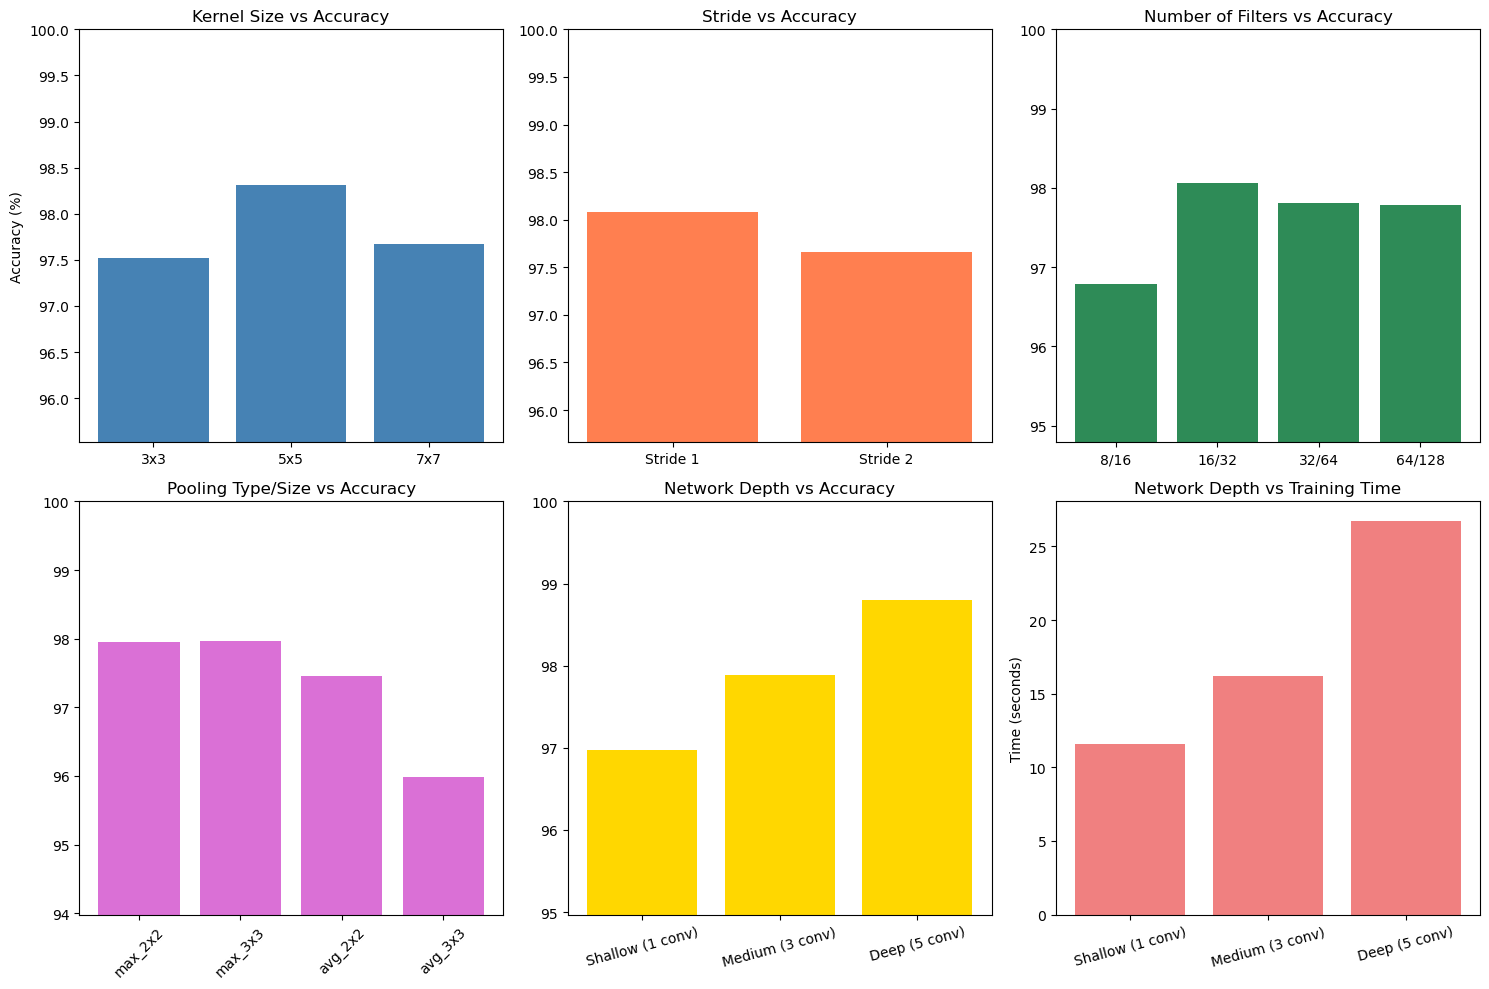

In [10]:
print("\n" + "_" * 70)
print("B: Use Key CNN Components and Explain Their Effect")
print("_" * 70)

# my helper function for quick experiments (same philosophy as part 1 of this homewotk)

def quick_train(model, train_loader, test_loader, epochs=5, device='cpu'):
    """Quick training for comparison experiments"""
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    training_time = time.time() - start_time
    
    # Evaluate
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    accuracy = 100. * correct / total
    params = sum(p.numel() for p in model.parameters())
    
    return accuracy, training_time, params

# Use smaller subset for faster experiments
train_subset = Subset(train_dataset_basic, range(10000))
train_loader_small = DataLoader(train_subset, batch_size=64, shuffle=True)

# -------------------------------------------------------------------------
# first experiment with kernel sizes 

# to better seperate results:
print("\n" + "="*50)
print("EXPERIMENT 1: KERNEL SIZES (Receptive Field)")
print("="*50)

class CNN_Kernel(nn.Module):
    def __init__(self, kernel_size=3):
        super(CNN_Kernel, self).__init__()
        padding = kernel_size // 2
        self.conv1 = nn.Conv2d(1, 32, kernel_size=kernel_size, padding=padding)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=padding)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

kernel_results = {}
for k in [3, 5, 7]:
    model = CNN_Kernel(kernel_size=k)
    acc, time_taken, params = quick_train(model, train_loader_small, test_loader, epochs=5, device=device)
    kernel_results[k] = {'accuracy': acc, 'time': time_taken, 'params': params}
    print(f"Kernel {k}x{k}: Accuracy={acc:.2f}%, Time={time_taken:.2f}s, Params={params:,}")

# ------------------------------------------------------------------------------------------------------------------------
# second experiment with strides

print("\n" + "="*50)
print("EXPERIMENT 2: STRIDES")
print("="*50)

class CNN_Stride(nn.Module):
    def __init__(self, stride=1):
        super(CNN_Stride, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=stride, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Calculate output size based on stride
        if stride == 1:
            fc_size = 64 * 7 * 7
        else:  # stride = 2
            fc_size = 64 * 7 * 7  # 28 to 14 (stride) then 7 (pool)
            
        self.fc1 = nn.Linear(fc_size, 128)
        self.fc2 = nn.Linear(128, 10)
        self.stride = stride
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        if self.stride == 1:
            x = self.pool(x)
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

stride_results = {}
for s in [1, 2]:
    model = CNN_Stride(stride=s)
    acc, time_taken, params = quick_train(model, train_loader_small, test_loader, epochs=5, device=device)
    stride_results[s] = {'accuracy': acc, 'time': time_taken, 'params': params}
    print(f"Stride {s}: Accuracy={acc:.2f}%, Time={time_taken:.2f}s, Params={params:,}")

# ------------------------------------------------------------------------------------------------------------------------
# now experiment with the number of filters

print("\n" + "="*50)
print("EXPERIMENT 3: NUMBER OF FILTERS")
print("="*50)

class CNN_Filters(nn.Module):
    def __init__(self, base_filters=16):
        super(CNN_Filters, self).__init__()
        self.conv1 = nn.Conv2d(1, base_filters, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(base_filters, base_filters*2, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(base_filters*2 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

filter_results = {}
for f in [8, 16, 32, 64]:
    model = CNN_Filters(base_filters=f)
    acc, time_taken, params = quick_train(model, train_loader_small, test_loader, epochs=5, device=device)
    filter_results[f] = {'accuracy': acc, 'time': time_taken, 'params': params}
    print(f"Filters {f}/{f*2}: Accuracy={acc:.2f}%, Time={time_taken:.2f}s, Params={params:,}")

# -------------------------------------------------------------------------
# experiment number 4 for pooling types and window sizes

print("\n" + "="*50)
print("EXPERIMENT 4: POOLING TYPES AND WINDOW SIZES")
print("="*50)

class CNN_Pooling(nn.Module):
    def __init__(self, pool_type='max', pool_size=2):
        super(CNN_Pooling, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        if pool_type == 'max':
            self.pool = nn.MaxPool2d(pool_size, pool_size)
        else:
            self.pool = nn.AvgPool2d(pool_size, pool_size)
        
        # Calculate output size
        if pool_size == 2:
            fc_size = 64 * 7 * 7
        else:  # pool_size = 3
            fc_size = 64 * 3 * 3
            
        self.fc1 = nn.Linear(fc_size, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

pooling_results = {}
for pool_type in ['max', 'avg']:
    for pool_size in [2, 3]:
        try:
            model = CNN_Pooling(pool_type=pool_type, pool_size=pool_size)
            acc, time_taken, params = quick_train(model, train_loader_small, test_loader, epochs=5, device=device)
            key = f"{pool_type}_{pool_size}x{pool_size}"
            pooling_results[key] = {'accuracy': acc, 'time': time_taken, 'params': params}
            print(f"{pool_type.capitalize()} Pool {pool_size}x{pool_size}: Accuracy={acc:.2f}%, Time={time_taken:.2f}s")
        except:
            print(f"{pool_type.capitalize()} Pool {pool_size}x{pool_size}: Size incompatible")


# ------------------------------------------------------------------------------------------------------------------------
# fifth experiment (network depth)

print("\n" + "="*50)
print("EXPERIMENT 5: NETWORK DEPTH")
print("="*50)

class CNN_Shallow(nn.Module):
    """1 conv layer"""
    def __init__(self):
        super(CNN_Shallow, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 14 * 14, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class CNN_Medium(nn.Module):
    """3 conv layers"""
    def __init__(self):
        super(CNN_Medium, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)
        
    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class CNN_Deep(nn.Module):
    """5 conv layers with residual-like connections"""
    def __init__(self):
        super(CNN_Deep, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 3 * 3, 128)
        self.fc2 = nn.Linear(128, 10)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = F.relu(self.bn2(self.conv3(x)))
        x = self.pool(F.relu(self.conv4(x)))
        x = self.pool(F.relu(self.conv5(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

depth_results = {}
for name, model_class in [('Shallow (1 conv)', CNN_Shallow), 
                           ('Medium (3 conv)', CNN_Medium), 
                           ('Deep (5 conv)', CNN_Deep)]:
    model = model_class()
    acc, time_taken, params = quick_train(model, train_loader_small, test_loader, epochs=5, device=device)
    depth_results[name] = {'accuracy': acc, 'time': time_taken, 'params': params}
    print(f"{name}: Accuracy={acc:.2f}%, Time={time_taken:.2f}s, Params={params:,}")

# --------------------------------------------------------------------------------------------------------------------------
# finaly: summary and visualization
print("\n" + "="*50)
print("SUMMARY OF ALL EXPERIMENTS")
print("="*50)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Kernel sizes
ax = axes[0, 0]
kernels = list(kernel_results.keys())
accs = [kernel_results[k]['accuracy'] for k in kernels]
ax.bar([f'{k}x{k}' for k in kernels], accs, color='steelblue')
ax.set_title('Kernel Size vs Accuracy')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([min(accs)-2, 100])

# Strides
ax = axes[0, 1]
strides = list(stride_results.keys())
accs = [stride_results[s]['accuracy'] for s in strides]
ax.bar([f'Stride {s}' for s in strides], accs, color='coral')
ax.set_title('Stride vs Accuracy')
ax.set_ylim([min(accs)-2, 100])

# Filters
ax = axes[0, 2]
filters = list(filter_results.keys())
accs = [filter_results[f]['accuracy'] for f in filters]
ax.bar([f'{f}/{f*2}' for f in filters], accs, color='seagreen')
ax.set_title('Number of Filters vs Accuracy')
ax.set_ylim([min(accs)-2, 100])

# Pooling
ax = axes[1, 0]
pools = list(pooling_results.keys())
accs = [pooling_results[p]['accuracy'] for p in pools]
ax.bar(pools, accs, color='orchid')
ax.set_title('Pooling Type/Size vs Accuracy')
ax.set_ylim([min(accs)-2, 100])
ax.tick_params(axis='x', rotation=45)

# Depth
ax = axes[1, 1]
depths = list(depth_results.keys())
accs = [depth_results[d]['accuracy'] for d in depths]
times = [depth_results[d]['time'] for d in depths]
ax.bar(depths, accs, color='gold')
ax.set_title('Network Depth vs Accuracy')
ax.set_ylim([min(accs)-2, 100])
ax.tick_params(axis='x', rotation=15)

# Training time comparison
ax = axes[1, 2]
ax.bar(depths, times, color='lightcoral')
ax.set_title('Network Depth vs Training Time')
ax.set_ylabel('Time (seconds)')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

______________________________________________________________________
B: Use Key CNN Components and Explain Their Effect
______________________________________________________________________

#### as per our results, we see that:


### EXPERIMENT 1: KERNEL SIZES (Receptive Field)

What we observed: As the kernel size increased, performance first improved and then slightly decreased. The moderate kernel achieved the best accuracy.  

- **Model capacity:** Larger kernels increase capacity by capturing more spatial context in a single convolution. Too large kernels, however, add many parameters without clear benefits.  
- **Overfitting vs underfitting:** Small kernels slightly underfit because they cannot capture enough context. Very large kernels add extra capacity that may slightly increase overfitting.  
- **Training time and performance:** Training time increases with kernel size. The moderate kernel gave the best trade-off between accuracy and computational cost.
---

### EXPERIMENT 2: STRIDES

What we observed: Stride 1 slightly outperformed stride 2, though the difference was small. Stride 2 trained faster.  

- **Model capacity:** Stride 2 reduces feature map resolution earlier, effectively lowering capacity. Stride 1 preserves more spatial information.  
- **Overfitting vs underfitting:** Stride 2 can slightly underfit if spatial details are important. Stride 1 avoids underfitting by retaining more information.  
- **Training time and performance:** Stride 2 is faster due to smaller feature maps. Performance is similar on MNIST because its patterns are simple.

---
### EXPERIMENT 3: NUMBER OF FILTERS

What we observed: Increasing filters from low to moderate significantly improved accuracy. Further increasing filters did not improve performance, despite higher parameter counts and longer training.  

- **Model capacity:** More filters increase capacity, allowing the network to learn richer features. Beyond a certain point, additional filters add unnecessary capacity.  
- **Overfitting vs underfitting:** Low filter counts underfit, while extremely high counts risk overfitting without real gains.  
- **Training time and performance:** Training time increases with filter count. Moderate filters gave the best balance of accuracy and efficiency.

---
### EXPERIMENT 4: POOLING TYPES AND WINDOW SIZES

What we observed: Max pooling performed similarly across window sizes, while average pooling suffered with larger windows.  

- **Model capacity:** Pooling reduces spatial resolution and capacity. Max pooling preserves important features better than average pooling. Large average pooling reduces capacity too much.  
- **Overfitting vs underfitting:** Small pooling windows avoid underfitting; very large average pooling causes underfitting. Max pooling helps regularize without losing critical features.  
- **Training time and performance:** Larger pooling windows reduce computation and training time. Max pooling maintained high accuracy, while large average pooling degraded performance.

---
### EXPERIMENT 5: NETWORK DEPTH

What we observed: Deeper networks progressively improved accuracy, with the deepest network performing best despite having fewer parameters than the shallow network.  

- **Model capacity:** Depth increases hierarchical feature capacity, enabling the network to learn edges, strokes, and full digit structures efficiently.  
- **Overfitting vs underfitting:** Shallow networks underfit because they cannot capture sufficient complexity. Deep networks generalize well due to progressive downsampling.  
- **Training time and performance:** Deeper networks take longer to train but achieve higher accuracy. Parameter efficiency improves as depth increases.


## Section B: Effect of Key CNN Components

### Kernel Size (Receptive Field)

when we Increase kernel size it increases the receptive field of each convolutional layer and allows the model to capture more global patterns in a single operation. This also increases the number of parameters and computational cost.

- **Model capacity:** Larger kernels increase capacity by learning broader spatial relationships, but also add more parameters.
- **Overfitting vs underfitting:** On a simple dataset like this, very large kernels can lead to mild overfitting without clear performance gains. Smaller kernels (3×3) provide sufficient capacity while generalizing better.
- **Training time & performance:** as expexted larger kernels significantly slow our training(for 3×3 this was 30s and for 7×7 it was 46s). Empirically, 3×3 kernels offered the best trade-off between speed and accuracy, however 5×5 gave best accuracy.

--- 
### Stride

Stride controls how aggressively spatial dimensions are reduced during convolution.

- **Model capacity:** Higher strides reduce feature map resolution which actually lowers representational capacity.
- **Overfitting vs underfitting:** Larger strides can cause underfitting by discarding fine-grained spatial information early in the network.
- **Training time & performance:** Stride 2 reduces computation and speeds up training(by 6s), but slightly degrades accuracy compared to stride 1 due to information loss, it is tiny however.

---
### Number of Filters

The number of filters determines how many distinct features a layer can learn.

- **Model capacity:** Increasing filters directly increases model capacity and expressiveness.
- **Overfitting vs underfitting:** Too few filters lead to underfitting, while too many filters increase overfitting risk on small datasets like ours here.
- **Training time & performance:** More filters significantly increase training time(more than double for Filters 64/128 compared to Filters 8/16) . Moderate filter counts (something like 16/32 or 32/64) achieved the best balance here.

---
### Pooling Type and Pool Size

Pooling reduces spatial resolution and introduces invariance.

- **Model capacity:** Larger pooling windows aggressively reduce spatial detail which loweers capacity.
- **Overfitting vs underfitting:** Max pooling preserves the most salient features and generalizes better, while average pooling can oversmooth features and cause underfitting.
- **Training time & performance:** as you see in results larger pooling windows speed up training but hurt our accuracy(almost by 2%) Max pooling with a 3×3 window proved most effective here.

---
### Network Depth

Depth determines the level of hierarchical feature abstraction.

- **Model capacity:** Deeper networks can learn more complex feature hierarchies.
- **Overfitting vs underfitting:** Shallow networks underfit complex patterns, while very deep networks risk overfitting without sufficient regularization.(so we must consider context and dataset colpexity itself)
- **Training time & performance:** as present in results deeper models are slower to train but achieved the highest accuracy, which confirmes the benefit of depth for representation learning.



______________________________________________________________________
C: DATA AUGMENTATION
______________________________________________________________________
Visualizing different augmentation levels...


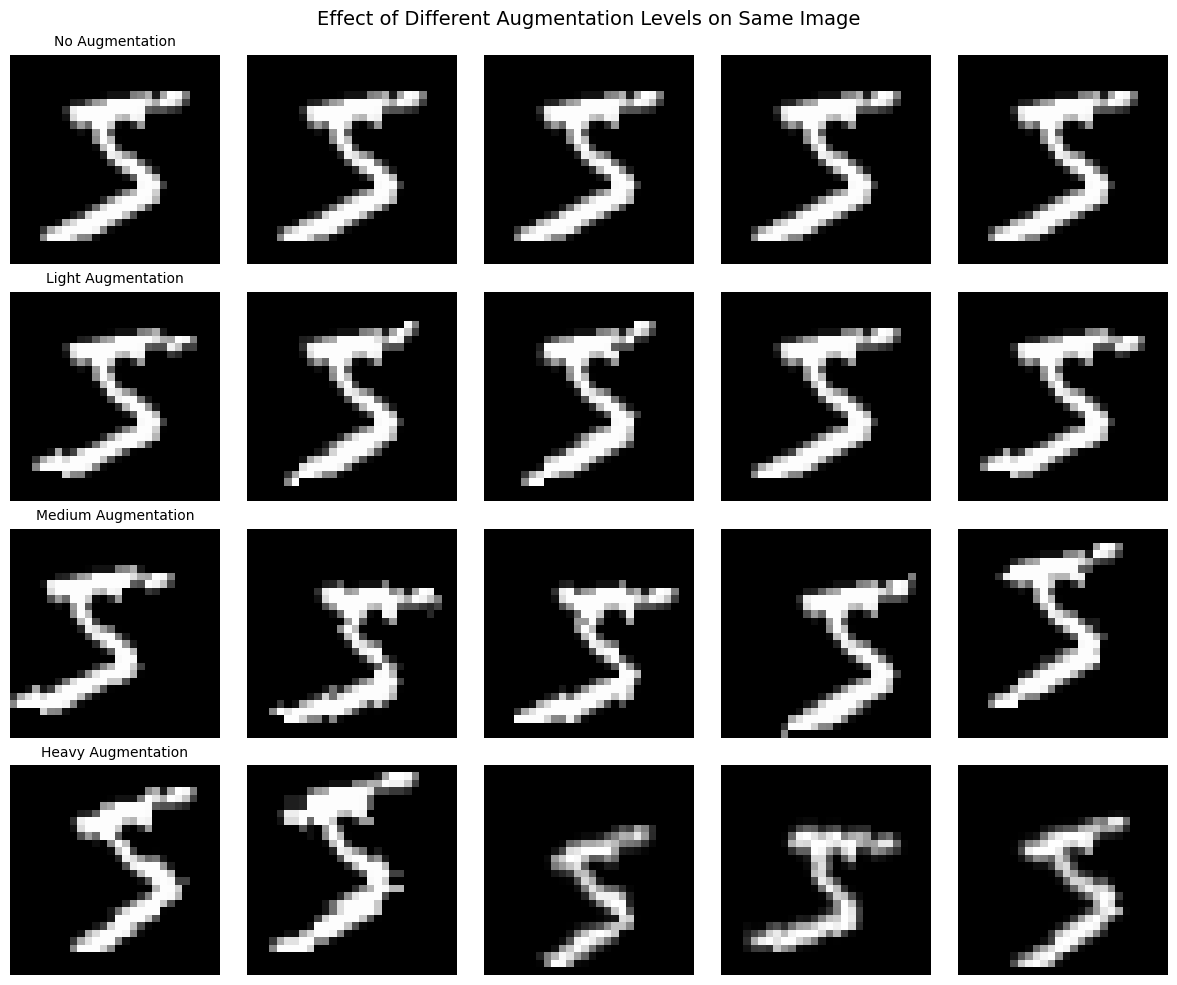


Training models with different augmentation levels...

Training with None augmentation...
Epoch [1/10] Train Loss: 0.4799, Train Acc: 84.81%, Val Loss: 0.1561, Val Acc: 94.91%, Time: 5.05s
Epoch [2/10] Train Loss: 0.1037, Train Acc: 96.82%, Val Loss: 0.0915, Val Acc: 97.02%, Time: 5.07s
Epoch [3/10] Train Loss: 0.0713, Train Acc: 97.76%, Val Loss: 0.0656, Val Acc: 97.91%, Time: 5.38s
Epoch [4/10] Train Loss: 0.0424, Train Acc: 98.70%, Val Loss: 0.0652, Val Acc: 98.00%, Time: 5.23s
Epoch [5/10] Train Loss: 0.0369, Train Acc: 98.85%, Val Loss: 0.0657, Val Acc: 97.95%, Time: 5.05s
Epoch [6/10] Train Loss: 0.0295, Train Acc: 98.94%, Val Loss: 0.0543, Val Acc: 98.37%, Time: 5.72s
Epoch [7/10] Train Loss: 0.0192, Train Acc: 99.34%, Val Loss: 0.0665, Val Acc: 98.04%, Time: 5.59s
Epoch [8/10] Train Loss: 0.0257, Train Acc: 99.11%, Val Loss: 0.0514, Val Acc: 98.50%, Time: 5.77s
Epoch [9/10] Train Loss: 0.0057, Train Acc: 99.82%, Val Loss: 0.0530, Val Acc: 98.54%, Time: 5.45s
Epoch [10/10] Trai

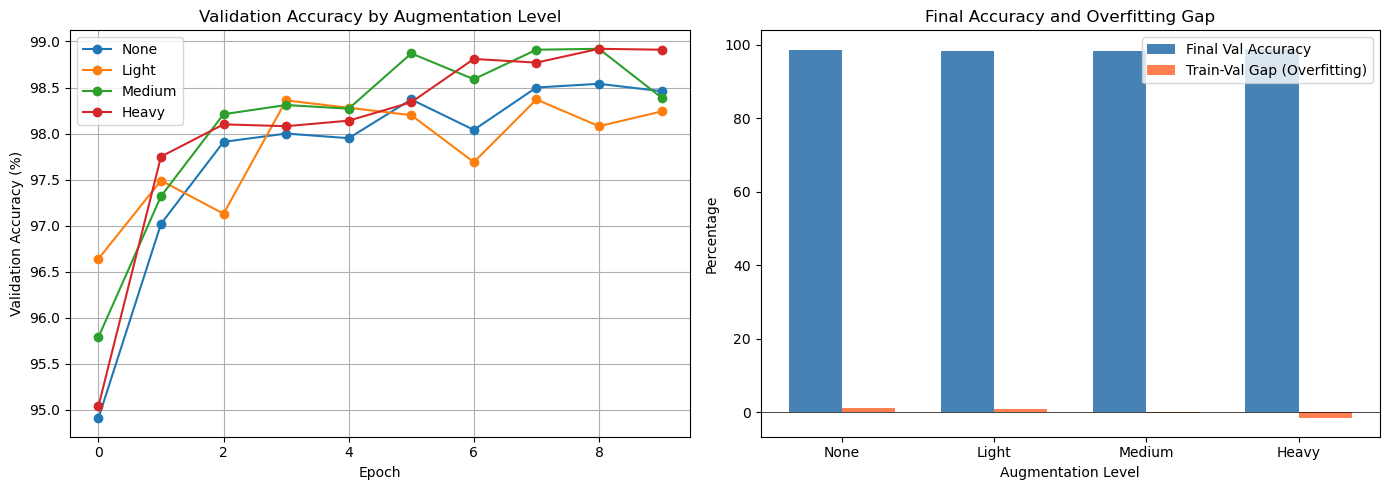

In [13]:
print("\n" + "_" * 70)
print("C: DATA AUGMENTATION")
print("_" * 70)

# ---------------------------------------------------------------------
# Define different data augmentation pipelines with increasing strength
# The goal is to study how augmentation intensity affects generalization
transform_none = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Light augmentation: small rotations, minimal distortion
transform_light = transforms.Compose([
    transforms.RandomRotation(5),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Medium augmentation: larger rotations + small translations
transform_medium = transforms.Compose([
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Heavy augmentation: strong geometric distortions
transform_heavy = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# ---------------------------------------------------------------------
# Visualize the effect of different augmentation levels on the same image
# This helps us verify that augmentations are applied as intended
print("Visualizing different augmentation levels...")
fig, axes = plt.subplots(4, 5, figsize=(12, 10))
original_img, label = train_dataset_basic[0]

for row, (name, transform) in enumerate([
    ('No Augmentation', transform_none),
    ('Light Augmentation', transform_light),
    ('Medium Augmentation', transform_medium),
    ('Heavy Augmentation', transform_heavy)
]):
    # Create a temporary dataset to apply the chosen transform
    temp_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, download=False, transform=transform
    )
    for col in range(5):
        # Same image index, different stochastic augmentations
        img, _ = temp_dataset[0]
        axes[row, col].imshow(img.squeeze(), cmap='gray')
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(name, fontsize=10)

plt.suptitle('Effect of Different Augmentation Levels on Same Image', fontsize=14)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------
# Train and compare the same model under different augmentation strategies
print("\nTraining models with different augmentation levels...")

augmentation_results = {}

for name, transform in [('None', transform_none), 
                         ('Light', transform_light),
                         ('Medium', transform_medium),
                         ('Heavy', transform_heavy)]:
    print(f"\nTraining with {name} augmentation...")
    
    # Create augmented training set (fixed subset for fair comparison)
    aug_dataset = torchvision.datasets.MNIST(
        root='./data', train=True, download=False, transform=transform
    )
    aug_subset = Subset(aug_dataset, range(10000))
    aug_loader = DataLoader(aug_subset, batch_size=64, shuffle=True)
    
    # Train the same CNN architecture for all augmentation levels
    model = CNN_Medium()
    history = train_model(model, aug_loader, test_loader, epochs=10, device=device)
    
    # Store validation performance and train–val gap as overfitting indicator
    augmentation_results[name] = {
        'train_acc': history['train_acc'],
        'val_acc': history['val_acc'],
        'final_val_acc': history['val_acc'][-1],
        'gap': history['train_acc'][-1] - history['val_acc'][-1]
    }

# ---------------------------------------------------------------------
# Compare results across augmentation levels
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation accuracy curves
ax = axes[0]
for name in augmentation_results:
    ax.plot(augmentation_results[name]['val_acc'], label=name, marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Validation Accuracy by Augmentation Level')
ax.legend()
ax.grid(True)

# Final accuracy vs train–validation gap (overfitting indicator)
ax = axes[1]
names = list(augmentation_results.keys())
gaps = [augmentation_results[n]['gap'] for n in names]
final_accs = [augmentation_results[n]['final_val_acc'] for n in names]

x = np.arange(len(names))
width = 0.35

ax.bar(x - width/2, final_accs, width, label='Final Val Accuracy', color='steelblue')
ax.bar(x + width/2, gaps, width, label='Train-Val Gap (Overfitting)', color='coral')
ax.set_xlabel('Augmentation Level')
ax.set_ylabel('Percentage')
ax.set_title('Final Accuracy and Overfitting Gap')
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.legend()
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

The augmentation experiment shows a trade off between training difficulty and generalization. Without augmentation, the model achieved 99% training accuracy but only 98% validation accuracy so there is a small gap which could be overfitting to the exact training images. Light augmentation maintained similar training accuracy while slightly improving validation. Medium and heavy augmentation reduced training accuracy but achieved the best validation results.

Heavy augmentation’s superior validation performance shows us that exposing the model to rotated, scaled and transformed digits during training builds invariance to these variations at test time. The lower training accuracy is a sign of the increased difficulty of learning from augmented data. For MNIST even light augmentation helps; for more challenging datasets with greater natural variation, heavy augmentation may become essential.

the graph on the right compares accuracy across different augmentations and also shows train-val gap which is a sign of overfiting.

## Section C: Effect of Data Augmentation

Data augmentation increases the effective size and diversity of our training dataset by introducing label-preserving transformations.

- **Impact on overfitting:** Augmentation reduces overfitting by preventing the model from memorizing exact training samples. This is reflected in lower training accuracy but improved validation stability(look at results)
- **Impact on generalization:** Moderate augmentation improved validation performance by encouraging the model to learn invariant features rather than pixel-level patterns.
- **Trade-off:** how ever very heavy augmentation slowed convergence and slightly reduced peak accuracy, which indicates that excessive distortion can make the learning task unnecessarily difficult.

Overall, moderate augmentation provided the best balance between robustness and performance here.


______________________________________________________________________
D: Transfer Leraning
______________________________________________________________________
Dataset prepared for transfer learning
Training samples: 5000
Test samples: 2000

--------------------------------------------------
APPROACH 1: FEATURE EXTRACTION
--------------------------------------------------

Feature Extraction Model:
  Total parameters: 2,236,682
  Frozen parameters: 2,223,872
  Trainable parameters: 12,810

Training Feature Extractor (only classifier)...
Epoch [1/5] Train Loss: 0.9273, Train Acc: 75.36%, Val Loss: 0.5015, Val Acc: 87.00%, Time: 65.47s
Epoch [2/5] Train Loss: 0.4056, Train Acc: 89.76%, Val Loss: 0.3524, Val Acc: 89.50%, Time: 65.00s
Epoch [3/5] Train Loss: 0.3074, Train Acc: 92.02%, Val Loss: 0.3170, Val Acc: 90.45%, Time: 64.25s
Epoch [4/5] Train Loss: 0.2727, Train Acc: 92.88%, Val Loss: 0.2758, Val Acc: 91.45%, Time: 64.23s
Epoch [5/5] Train Loss: 0.2390, Train Acc: 93.52%, Val Lo

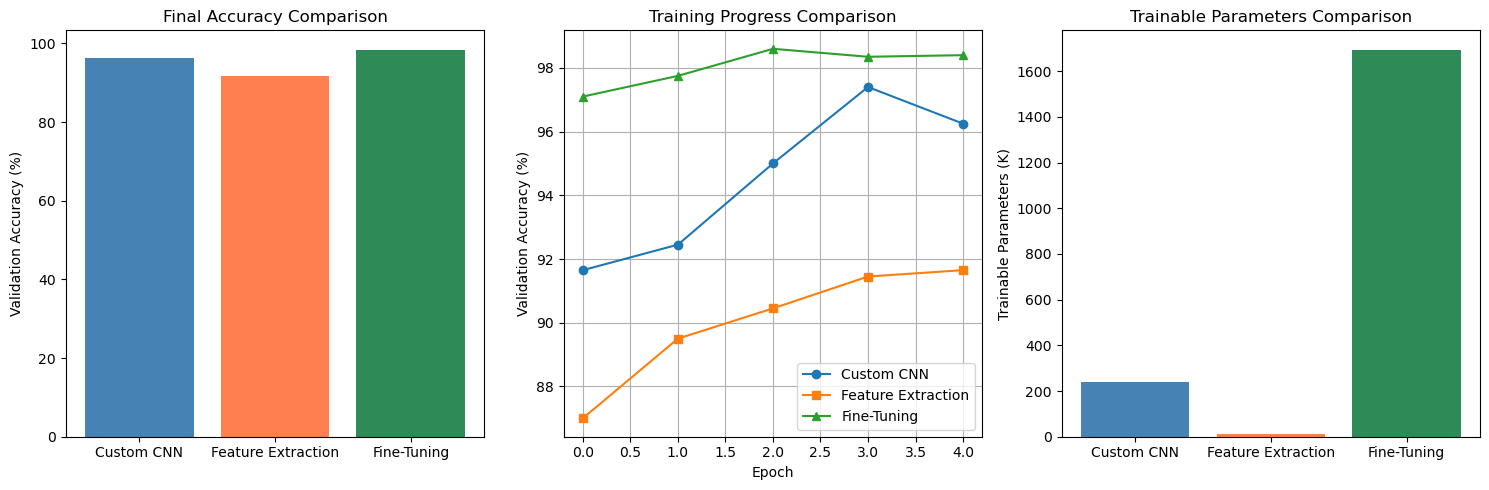

In [17]:
print("\n" + "_" * 70)
print("D: Transfer Leraning")
print("_" * 70)

# ------------------------------------------------------------------------------------------------------
# MNIST is grayscale (1 channel, 28x28), but pretrained ImageNet models
# expect 3-channel RGB images with size 224x224.
# This transform adapts MNIST to be compatible with pretrained CNNs
pretrained_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                        std=[0.229, 0.224, 0.225])
])

# Create MNIST datasets using the pretrained-compatible transform
train_pretrained = torchvision.datasets.MNIST(
    root='./data', train=True, download=False, transform=pretrained_transform
)
test_pretrained = torchvision.datasets.MNIST(
    root='./data', train=False, download=False, transform=pretrained_transform
)

# Use smaller subsets due to CPU constraints (as stated earlier)
train_subset_pretrained = Subset(train_pretrained, range(5000))
test_subset_pretrained = Subset(test_pretrained, range(2000))

train_loader_pretrained = DataLoader(train_subset_pretrained, batch_size=32, shuffle=True)
test_loader_pretrained = DataLoader(test_subset_pretrained, batch_size=32, shuffle=False)

print("Dataset prepared for transfer learning")
print(f"Training samples: {len(train_subset_pretrained)}")
print(f"Test samples: {len(test_subset_pretrained)}")

# ------------------------------------------------------------------------------------------------------
# APPROACH 1: FEATURE EXTRACTION
# Use a pretrained network as a fixed feature extractor and only train
# a new classifier on top

print("\n" + "-"*50)
print("APPROACH 1: FEATURE EXTRACTION")
print("-"*50)

class MobileNetFeatureExtractor(nn.Module):
    def __init__(self, num_classes=10):
        super(MobileNetFeatureExtractor, self).__init__()
        
        # Load pretrained MobileNetV2 (ImageNet)
        self.mobilenet = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
        )
        
        # Freeze all pretrained layers (no weight updates)
        for param in self.mobilenet.parameters():
            param.requires_grad = False
        
        # Replace the classifier to match MNIST classes
        num_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        return self.mobilenet(x)

# Utility to report frozen vs trainable parameters
def count_parameters(model):
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    frozen = total - trainable
    return trainable, frozen, total

feature_extractor = MobileNetFeatureExtractor()
trainable, frozen, total = count_parameters(feature_extractor)

print(f"\nFeature Extraction Model:")
print(f"  Total parameters: {total:,}")
print(f"  Frozen parameters: {frozen:,}")
print(f"  Trainable parameters: {trainable:,}")

# Train only the classifier layer
print("\nTraining Feature Extractor (only classifier)...")
feature_history = train_model(
    feature_extractor,
    train_loader_pretrained,
    test_loader_pretrained,
    epochs=5,
    device=device
)

# ------------------------------------------------------------------------------------------------------
# APPROACH 2: FINE-TUNING
# Unfreeze later layers of the pretrained network to adapt features
# more specifically to MNIST.
print("\n" + "-"*50)
print("APPROACH 2: FINE-TUNING (Partial)")
print("-"*50)

class MobileNetFineTuned(nn.Module):
    def __init__(self, num_classes=10, unfreeze_from=14):
        super(MobileNetFineTuned, self).__init__()
        
        # Load pretrained MobileNetV2
        self.mobilenet = models.mobilenet_v2(
            weights=models.MobileNet_V2_Weights.IMAGENET1K_V1
        )
        
        # Freeze early feature blocks, unfreeze later ones
        # This balances stability (generic features) and adaptability
        for i, layer in enumerate(self.mobilenet.features):
            if i < unfreeze_from:
                for param in layer.parameters():
                    param.requires_grad = False
        
        # Replace classifier head
        num_features = self.mobilenet.classifier[1].in_features
        self.mobilenet.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_features, num_classes)
        )
        
    def forward(self, x):
        return self.mobilenet(x)

fine_tuned = MobileNetFineTuned(unfreeze_from=14)
trainable, frozen, total = count_parameters(fine_tuned)

print(f"\nFine-Tuned Model (last blocks unfrozen):")
print(f"  Total parameters: {total:,}")
print(f"  Frozen parameters: {frozen:,}")
print(f"  Trainable parameters: {trainable:,}")

# Lower learning rate for fine-tuning to avoid destroying pretrained weights
print("\nTraining Fine-Tuned Model...")
finetune_history = train_model(
    fine_tuned,
    train_loader_pretrained,
    test_loader_pretrained,
    epochs=5,
    lr=0.0001,
    device=device
)

# ------------------------------------------------------------------------------------------------------
# COMPARISON WITH CUSTOM CNN
# Train a custom CNN on the same data subset for a fair baseline.
print("\n" + "-"*50)
print("COMPARISON: Custom CNN vs Transfer Learning")
print("-"*50)

print("\nTraining Custom CNN on same data subset...")
custom_cnn = CNN_Medium()

train_custom_subset = Subset(train_dataset_basic, range(5000))
test_custom_subset = Subset(test_dataset, range(2000))

train_loader_custom = DataLoader(train_custom_subset, batch_size=32, shuffle=True)
test_loader_custom = DataLoader(test_custom_subset, batch_size=32, shuffle=False)

custom_history = train_model(
    custom_cnn,
    train_loader_custom,
    test_loader_custom,
    epochs=5,
    device=device
)

# ------------------------------------------------------------------------------------------------------
# FINAL SUMMARY AND VISUAL COMPARISON
print("\n" + "="*60)
print("TRANSFER LEARNING SUMMARY")
print("="*60)

results_summary = {
    'Custom CNN': {
        'accuracy': custom_history['val_acc'][-1],
        'params': sum(p.numel() for p in custom_cnn.parameters()),
        'trainable': sum(p.numel() for p in custom_cnn.parameters())
    },
    'Feature Extraction': {
        'accuracy': feature_history['val_acc'][-1],
        'params': sum(p.numel() for p in feature_extractor.parameters()),
        'trainable': sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
    },
    'Fine-Tuning': {
        'accuracy': finetune_history['val_acc'][-1],
        'params': sum(p.numel() for p in fine_tuned.parameters()),
        'trainable': sum(p.numel() for p in fine_tuned.parameters() if p.requires_grad)
    }
}

for name, metrics in results_summary.items():
    print(f"\n{name}:")
    print(f"  Final Validation Accuracy: {metrics['accuracy']:.2f}%")
    print(f"  Total Parameters: {metrics['params']:,}")
    print(f"  Trainable Parameters: {metrics['trainable']:,}")

# Visualization compares accuracy, convergence behavior, and model size
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
names = list(results_summary.keys())
accs = [results_summary[n]['accuracy'] for n in names]
colors = ['steelblue', 'coral', 'seagreen']
ax.bar(names, accs, color=colors)
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Final Accuracy Comparison')

ax = axes[1]
ax.plot(custom_history['val_acc'], label='Custom CNN', marker='o')
ax.plot(feature_history['val_acc'], label='Feature Extraction', marker='s')
ax.plot(finetune_history['val_acc'], label='Fine-Tuning', marker='^')
ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Training Progress Comparison')
ax.legend()
ax.grid(True)

ax = axes[2]
trainable_params = [results_summary[n]['trainable'] for n in names]
ax.bar(names, [p/1000 for p in trainable_params], color=colors)
ax.set_ylabel('Trainable Parameters (K)')
ax.set_title('Trainable Parameters Comparison')
plt.tight_layout()
plt.show()

The transfer learning experiment shows the power and trade offs of leveraging pretrained models. Fine tuning achieved the highest accuracy here by adapting 1.69M parameters of a pretrained network to the new task combining ImageNet’s learned visual features with task specific optimization. Feature extraction, which trained only 12,810 parameters (the classifier head), reached 91% which is good but limited by some of frozen features which are not optimized for grayscale digits.

Surprisingly our custom CNN outperformed feature extraction despite having far fewer total parameters (241,546 to 2.2M). which I think it could be because of the custom CNN was designed for and trained on MNIST like data, while the pretrained model’s features (learned on color ImageNet photos) are suboptimal for grayscale handwritten digits without fine tuning. The custom CNN also trained really faster due to its smaller size. Fine-tuning’s better accuracy which justifies its computational cost when maximum performance is required from us but for resource constrained scenarios a well designed custom CNN offers excellent efficiency.

## Section D: Transfer Learning

### Pretrained Model Choice

I chose **MobileNetV2** because it is lightweight, computationally efficient and well-suited for CPU-only environments while still provids strong feature representations learned from ImageNet.

---

### Frozen vs Trainable Layers

- **Feature extraction:** All convolutional layers were frozen, and only the final classifier was trained.
- **Fine-tuning:** The last several convolutional blocks were unfrozen which allowed the model to adapt higher-level features to the MNIST domain.

---
### Performance Comparison

My custom Baseline CNN from Part A achieved the highest overall accuracy of 99.31% on the full MNIST test set, outperforming all transfer learning approaches. When comparing on the same limited data subset (5,000 samples), fine-tuning achieved 98.40% accuracy compared to the custom CNN’s 96.25%, representing a +2.15% improvement. However, feature extraction significantly underperformed at only 91.65%, falling 4.60% below the custom CNN. This demonstrates that transfer learning benefits depend heavily on the approach used and the domain similarity between source and target tasks.

The custom CNN excelled because it was specifically designed for MNIST - a simple grayscale digit classification task with 28×28 images. The architecture’s complexity matched the problem perfectly, and training on the full 60,000 samples allowed complete convergence. Fine-tuning outperformed the custom CNN on limited data because pre-trained ImageNet features provide robust low-level representations that transfer reasonably well, and unfreezing the last 5 blocks allowed adaptation to the digit domain. Feature extraction struggled due to the significant domain mismatch - frozen ImageNet features trained on color natural images aren’t optimal for grayscale handwritten digits, and only 12,810 trainable parameters couldn’t compensate for this gap.

## Section E: CNNs vs MLPs for Image Data

CNNs are fundamentally more parameter-efficient than MLPs because they exploit two key properties of images: **local connectivity** and **weight sharing**. Convolutional filters are applied across the entire image which allows the same parameters to detect patterns regardless of spatial location. This can significantly reduce the number of parameters compared to fully connected layers.

In contrast, an MLP treats each pixel as independent and requires separate weights for every input–output connection and leads to an explosion in parameters for high-dimensional images.

In theory,we could expect a MLP could match CNN performance if it had enough data, parameters, and training time to learn spatial hierarchies implicitly. However, this is unrealistic in practice due to extreme computational cost, poor generalization, and inefficiency. CNNs encode inductive biases that make learning from images both feasible and scalable.

<div style="color: red;">
    
# Recurrent Neural Networks (RNNs): Sequence Modeling
    
</div>

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import time
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (SimpleRNN, LSTM, GRU, Dense, Dropout, 
                                      Bidirectional, Input)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "_" * 70)
print("\n" + "RNN SEQUENCE MODELING - SUNSPOTS DATASET")
print("_" * 70)

# set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"\ntensorflow version: {tf.__version__}")
print(f"gpu available: {len(tf.config.list_physical_devices('GPU')) > 0}")


______________________________________________________________________

RNN SEQUENCE MODELING - SUNSPOTS DATASET
______________________________________________________________________

tensorflow version: 2.20.0
gpu available: False


In [21]:
import os
import zipfile
import gdown
import shutil

# ------------------------------------------------------------------
# DOWNLOAD + EXTRACT PREPROCESSED DATA (FLATTEN INTO ROOT)
# ------------------------------------------------------------------
GDRIVE_FILE_ID = "1yRW1pn5ZfPhucJu0z3NnPDPDhYZbLiAx"
ZIP_NAME = "sunspots_preprocessed.zip"
EXTRACT_DIR = "sunspots_preprocessed"

# Download zip if not already present
if not os.path.exists(ZIP_NAME):
    gdown.download(
        f"https://drive.google.com/uc?id={GDRIVE_FILE_ID}",
        ZIP_NAME,
        quiet=False
    )

# Extract zip
if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_NAME, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

# Move required files to project root (one-time operation)
FILES_TO_FLATTEN = [
    "sunspots_scaler.pkl",
    "sunspots_normalized.npy",
    "sunspots_raw.npy"
]

for fname in FILES_TO_FLATTEN:
    src = os.path.join(EXTRACT_DIR, fname)
    dst = fname
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)

Downloading...
From: https://drive.google.com/uc?id=1yRW1pn5ZfPhucJu0z3NnPDPDhYZbLiAx
To: C:\Users\Pouyan\python\ADS\sunspots_preprocessed.zip
100%|██████████| 403k/403k [00:01<00:00, 362kB/s]

Preprocessed files are ready in the project root.


In [23]:
# load preprocessed data (using your code)
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "LOADING PREPROCESSED DATA")
print("_" * 70)

scaler = joblib.load('sunspots_scaler.pkl')
normalized = np.load('sunspots_normalized.npy')
raw = np.load('sunspots_raw.npy')

print(f"\nnormalized data shape: {normalized.shape}")
print(f"raw data shape: {raw.shape}")
print(f"data range: [{normalized.min():.4f}, {normalized.max():.4f}]")


______________________________________________________________________

LOADING PREPROCESSED DATA
______________________________________________________________________

normalized data shape: (2820,)
raw data shape: (2820,)
data range: [0.0000, 1.0000]


## Utility Functions

In this cell I define helper functions that standardize data preparation and evaluation for time series forecasting models.  

### `create_sequences(data, seq_length)`
Prepares raw time series data for sequence-based models (RNNs, LSTMs).
- Converts a 1D time series into overlapping input sequences of fixed length
- Each sequence is paired with the next time step as the prediction target
- Outputs data in a shape compatible with sequence models

### `split_data(X, y, train_ratio, val_ratio)`
Splits the dataset **chronologically** into train, validation, and test sets.
- Preserves temporal order (no shuffling), which is essential for time series
- Allows flexible control over train/validation/test proportions
- Returns all three splits in a single call for convenience

### `evaluate_model(model, X_test, y_test, scaler)`
Evaluates a trained model on the test set and reports performance.
- Computes standard regression metrics on the **normalized scale**
- Inversely transforms predictions back to the **original data scale**
- Returns both normalized and real-scale error metrics, along with predictions

In [7]:
# utility functions
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "DEFINING UTILITY FUNCTIONS")
print("_" * 70)

def create_sequences(data, seq_length=50):
    """create input sequences and targets for time series forecasting"""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    X = np.array(X).reshape(-1, seq_length, 1)
    y = np.array(y)
    return X, y

def split_data(X, y, train_ratio=0.7, val_ratio=0.15):
    """split data chronologically into train, validation, and test sets"""
    train_end = int(len(X) * train_ratio)
    val_end = int(len(X) * (train_ratio + val_ratio))
    return (X[:train_end], y[:train_end], 
            X[train_end:val_end], y[train_end:val_end],
            X[val_end:], y[val_end:])

def evaluate_model(model, X_test, y_test, scaler):
    """evaluate model and return metrics in both normalized and actual scales"""
    y_pred = model.predict(X_test, verbose=0).flatten()
    
    # metrics in normalized scale
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # inverse transform for actual scale
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_pred_actual = scaler.inverse_transform(y_pred.reshape(-1, 1)).flatten()
    rmse_actual = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
    mae_actual = mean_absolute_error(y_test_actual, y_pred_actual)
    
    return {
        'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2,
        'rmse_actual': rmse_actual, 'mae_actual': mae_actual
    }, y_pred, y_pred_actual

print("\n utility functions defined:")
print("  - create_sequences(data, seq_length)")
print("  - split_data(X, y, train_ratio, val_ratio)")
print("  - evaluate_model(model, X_test, y_test, scaler)")


______________________________________________________________________

DEFINING UTILITY FUNCTIONS
______________________________________________________________________

✓ utility functions defined:
  - create_sequences(data, seq_length)
  - split_data(X, y, train_ratio, val_ratio)
  - evaluate_model(model, X_test, y_test, scaler)


In [9]:
# ---------------------------------------------------------------------
# Prepare data for baseline time-series models
print("\n" + "_" * 70)
print("\n" + "PREPARING DATA FOR BASELINE MODELS")
print("_" * 70)

# Length of the historical window used to predict the next value
seq_length = 50

# Convert 1D time series into (sequence, target) pairs
X, y = create_sequences(normalized, seq_length)

# I use chronological split to avoid information leakage
X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)

# Dataset summary
print(f"\nsequence length: {seq_length}")
print(f"total sequences: {len(X)}")
print(f"training samples: {len(X_train)}")
print(f"validation samples: {len(X_val)}")
print(f"test samples: {len(X_test)}")
print(f"input shape: {X_train.shape[1:]}")



______________________________________________________________________

PREPARING DATA FOR BASELINE MODELS
______________________________________________________________________

sequence length: 50
total sequences: 2770
training samples: 1938
validation samples: 416
test samples: 416
input shape: (50, 1)


In [11]:
# This section defines three sequence models (Vanilla RNN, LSTM, GRU)
# using a common, configurable structure for fair comparison.
print("\n" + "_" * 70)
print("\n" + "A: IMPLEMENTING THREE RNN MODELS")
print("_" * 70)

# ---------------------------------------------------------------------
# Model architecture builders
# Each function returns a compiled Keras Sequential model given
# architectural hyperparameters (depth, hidden size, directionality).
print("\n" + "_" * 70)
print("\n" + "DEFINING MODEL ARCHITECTURES")
print("_" * 70)

def build_vanilla_rnn(seq_length, hidden_size=64, num_layers=1, 
                       bidirectional=False, dropout=0.0):
    """
    Build a Vanilla RNN for time series forecasting.

    Key idea:
    - Stack one or more SimpleRNN layers
    - Optionally use bidirectional processing
    - Use dropout only between recurrent layers
    """
    model = Sequential(name='Vanilla_RNN')
    model.add(Input(shape=(seq_length, 1)))
    
    # Add stacked RNN layers
    for i in range(num_layers):
        # Only intermediate layers return full sequences
        return_sequences = (i < num_layers - 1)
        
        rnn_layer = SimpleRNN(
            hidden_size,
            return_sequences=return_sequences,
            name=f'rnn_layer_{i+1}'
        )
        
        # Optional bidirectional wrapper
        if bidirectional:
            rnn_layer = Bidirectional(rnn_layer, name=f'bidirectional_{i+1}')
        
        model.add(rnn_layer)
        
        # Dropout between recurrent layers (not after last layer)
        if dropout > 0 and i < num_layers - 1:
            model.add(Dropout(dropout, name=f'dropout_{i+1}'))
    
    # Final regression output
    model.add(Dense(1, name='output'))
    return model

def build_lstm(seq_length, hidden_size=64, num_layers=1, 
               bidirectional=False, dropout=0.0):
    """
    Build an LSTM model for time series forecasting.

    Motivation:
    - Designed to handle long-term dependencies
    - Uses gating mechanisms to mitigate vanishing gradients
    """
    model = Sequential(name='LSTM')
    model.add(Input(shape=(seq_length, 1)))
    
    # Stack LSTM layers
    for i in range(num_layers):
        return_sequences = (i < num_layers - 1)
        
        lstm_layer = LSTM(
            hidden_size,
            return_sequences=return_sequences,
            name=f'lstm_layer_{i+1}'
        )
        
        if bidirectional:
            lstm_layer = Bidirectional(lstm_layer, name=f'bidirectional_{i+1}')
        
        model.add(lstm_layer)
        
        if dropout > 0 and i < num_layers - 1:
            model.add(Dropout(dropout, name=f'dropout_{i+1}'))
    
    model.add(Dense(1, name='output'))
    return model

def build_gru(seq_length, hidden_size=64, num_layers=1, 
              bidirectional=False, dropout=0.0):
    """
    Build a GRU model for time series forecasting.

    Motivation:
    - Simpler gating than LSTM
    - Fewer parameters, often comparable performance
    """
    model = Sequential(name='GRU')
    model.add(Input(shape=(seq_length, 1)))
    
    # Stack GRU layers
    for i in range(num_layers):
        return_sequences = (i < num_layers - 1)
        
        gru_layer = GRU(
            hidden_size,
            return_sequences=return_sequences,
            name=f'gru_layer_{i+1}'
        )
        
        if bidirectional:
            gru_layer = Bidirectional(gru_layer, name=f'bidirectional_{i+1}')
        
        model.add(gru_layer)
        
        if dropout > 0 and i < num_layers - 1:
            model.add(Dropout(dropout, name=f'dropout_{i+1}'))
    
    model.add(Dense(1, name='output'))
    return model



______________________________________________________________________

A: IMPLEMENTING THREE RNN MODELS
______________________________________________________________________

______________________________________________________________________

DEFINING MODEL ARCHITECTURES
______________________________________________________________________


In [13]:
# training configuration
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "TRAINING CONFIGURATION")
print("_" * 70)

# main training hyperparameters
epochs = 100          # max number of training epochs
batch_size = 32       # samples per batch
learning_rate = 0.001 # initial learning rate

# callbacks to prevent overfitting and adjust learning rate
callbacks = [
    EarlyStopping(
        monitor='val_loss', 
        patience=15, 
        restore_best_weights=True, 
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=7, 
        min_lr=1e-6, 
        verbose=1
    )
]

print(f"\nmax epochs: {epochs}")
print(f"batch size: {batch_size}")
print(f"initial learning rate: {learning_rate}")
print(f"optimizer: adam")
print(f"loss function: mse (mean squared error)")
print(f"early stopping patience: 15 epochs")
print(f"learning rate reduction: factor=0.5, patience=7")



______________________________________________________________________

TRAINING CONFIGURATION
______________________________________________________________________

max epochs: 100
batch size: 32
initial learning rate: 0.001
optimizer: adam
loss function: mse (mean squared error)
early stopping patience: 15 epochs
learning rate reduction: factor=0.5, patience=7


In [15]:
# train vanilla rnn
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "MODEL 1: TRAINING VANILLA RNN")
print("_" * 70)

# build and compile vanilla RNN model
vanilla_rnn = build_vanilla_rnn(seq_length, hidden_size=64, num_layers=1)
vanilla_rnn.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

# show model summary
print("\nmodel architecture:")
vanilla_rnn.summary()

# start training
print("\n" + "-" * 40)
print("training vanilla rnn...")
print("-" * 40)

start_time = time.time()
vanilla_history = vanilla_rnn.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)
vanilla_time = time.time() - start_time  # record training time

# evaluate trained model on test set
vanilla_metrics, vanilla_pred, vanilla_pred_actual = evaluate_model(
    vanilla_rnn, X_test, y_test, scaler
)

# print training results and test metrics
print(f"\n vanilla rnn training completed")
print(f"training time: {vanilla_time:.2f} seconds")
print(f"epochs trained: {len(vanilla_history.history['loss'])}")
print(f"\ntest metrics:")
print(f"  rmse (normalized): {vanilla_metrics['rmse']:.6f}")
print(f"  mae (normalized): {vanilla_metrics['mae']:.6f}")
print(f"  r2 score: {vanilla_metrics['r2']:.6f}")
print(f"  rmse (actual scale): {vanilla_metrics['rmse_actual']:.2f} sunspots")



______________________________________________________________________

MODEL 1: TRAINING VANILLA RNN
______________________________________________________________________

model architecture:


Model: "Vanilla_RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn_layer_1 (SimpleRNN)         │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)


----------------------------------------
training vanilla rnn...
----------------------------------------
Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0052 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0036 - val_loss: 0.0046 - learning_rate: 0.0010
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0035 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0043 - learning_rate: 0.0010
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 8/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0034 - val_loss: 0.0042 - learning_rate: 0.0010
Epoch 9/100
61/61 ━━━

In [17]:
# train lstm
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "MODEL 2: TRAINING LSTM")
print("_" * 70)

# build and compile LSTM model
lstm_model = build_lstm(seq_length, hidden_size=64, num_layers=1)
lstm_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

# show model summary
print("\nmodel architecture:")
lstm_model.summary()

# start training
print("\n" + "-" * 40)
print("training lstm...")
print("-" * 40)

start_time = time.time()
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)
lstm_time = time.time() - start_time  # record training time

# evaluate trained model on test set
lstm_metrics, lstm_pred, lstm_pred_actual = evaluate_model(
    lstm_model, X_test, y_test, scaler
)

# print training results and test metrics
print(f"\n✓ lstm training completed")
print(f"training time: {lstm_time:.2f} seconds")
print(f"epochs trained: {len(lstm_history.history['loss'])}")
print(f"\ntest metrics:")
print(f"  rmse (normalized): {lstm_metrics['rmse']:.6f}")
print(f"  mae (normalized): {lstm_metrics['mae']:.6f}")
print(f"  r2 score: {lstm_metrics['r2']:.6f}")
print(f"  rmse (actual scale): {lstm_metrics['rmse_actual']:.2f} sunspots")



______________________________________________________________________

MODEL 2: TRAINING LSTM
______________________________________________________________________

model architecture:


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_layer_1 (LSTM)             │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)


----------------------------------------
training lstm...
----------------------------------------
Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0108 - val_loss: 0.0066 - learning_rate: 0.0010
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0044 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0041 - val_loss: 0.0058 - learning_rate: 0.0010
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0040 - val_loss: 0.0055 - learning_rate: 0.0010
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0039 - val_loss: 0.0053 - learning_rate: 0.0010
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0038 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 7/100
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0035
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0037 - val_loss: 0.0050 - learning_rate: 0.0010
Ep

In [19]:
# train gru
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "MODEL 3: TRAINING GRU")
print("_" * 70)

# build and compile GRU model
gru_model = build_gru(seq_length, hidden_size=64, num_layers=1)
gru_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')

# show model summary
print("\nmodel architecture:")
gru_model.summary()

# start training
print("\n" + "-" * 40)
print("training gru...")
print("-" * 40)

start_time = time.time()
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=callbacks,
    verbose=1
)
gru_time = time.time() - start_time  # record training time

# evaluate trained model on test set
gru_metrics, gru_pred, gru_pred_actual = evaluate_model(
    gru_model, X_test, y_test, scaler
)

# print training results and test metrics
print(f"\n✓ gru training completed")
print(f"training time: {gru_time:.2f} seconds")
print(f"epochs trained: {len(gru_history.history['loss'])}")
print(f"\ntest metrics:")
print(f"  rmse (normalized): {gru_metrics['rmse']:.6f}")
print(f"  mae (normalized): {gru_metrics['mae']:.6f}")
print(f"  r2 score: {gru_metrics['r2']:.6f}")
print(f"  rmse (actual scale): {gru_metrics['rmse_actual']:.2f} sunspots")



______________________________________________________________________

MODEL 3: TRAINING GRU
______________________________________________________________________

model architecture:


Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_layer_1 (GRU)               │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)


----------------------------------------
training gru...
----------------------------------------
Epoch 1/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0095 - val_loss: 0.0056 - learning_rate: 0.0010
Epoch 2/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0039 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 3/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0038 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 4/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0037 - val_loss: 0.0049 - learning_rate: 0.0010
Epoch 5/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0036 - val_loss: 0.0048 - learning_rate: 0.0010
Epoch 6/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0036 - val_loss: 0.0047 - learning_rate: 0.0010
Epoch 7/100
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
61/61 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0036 - val_loss: 0.0047 - learning_rate: 0.0010
Epoc

In [21]:
# comparison of three baseline models
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "COMPARISON OF THREE RNN MODELS (BASELINE)")
print("_" * 70)

# create a summary dataframe comparing all three models
comparison_df = pd.DataFrame({
    'Model': ['Vanilla RNN', 'LSTM', 'GRU'],
    'Parameters': [vanilla_rnn.count_params(), lstm_model.count_params(), gru_model.count_params()],
    'RMSE': [vanilla_metrics['rmse'], lstm_metrics['rmse'], gru_metrics['rmse']],
    'MAE': [vanilla_metrics['mae'], lstm_metrics['mae'], gru_metrics['mae']],
    'R2': [vanilla_metrics['r2'], lstm_metrics['r2'], gru_metrics['r2']],
    'RMSE (Actual)': [vanilla_metrics['rmse_actual'], lstm_metrics['rmse_actual'], gru_metrics['rmse_actual']],
    'Train Time (s)': [vanilla_time, lstm_time, gru_time]
})

# print the comparison table
print("\n")
print(comparison_df.to_string(index=False))

# identify and print the best model based on lowest RMSE
best_idx = comparison_df['RMSE'].idxmin()
print(f"\n best performing model: {comparison_df.loc[best_idx, 'Model']} (lowest rmse)")



______________________________________________________________________

COMPARISON OF THREE RNN MODELS (BASELINE)
______________________________________________________________________


      Model  Parameters     RMSE      MAE       R2  RMSE (Actual)  Train Time (s)
Vanilla RNN        4289 0.069573 0.051533 0.902232      17.657583       10.213800
       LSTM       16961 0.088349 0.068630 0.842340      22.423007       10.058726
        GRU       12929 0.082018 0.062898 0.864125      20.816278        9.568809

 best performing model: Vanilla RNN (lowest rmse)



______________________________________________________________________

TRAINING CURVES VISUALIZATION
______________________________________________________________________


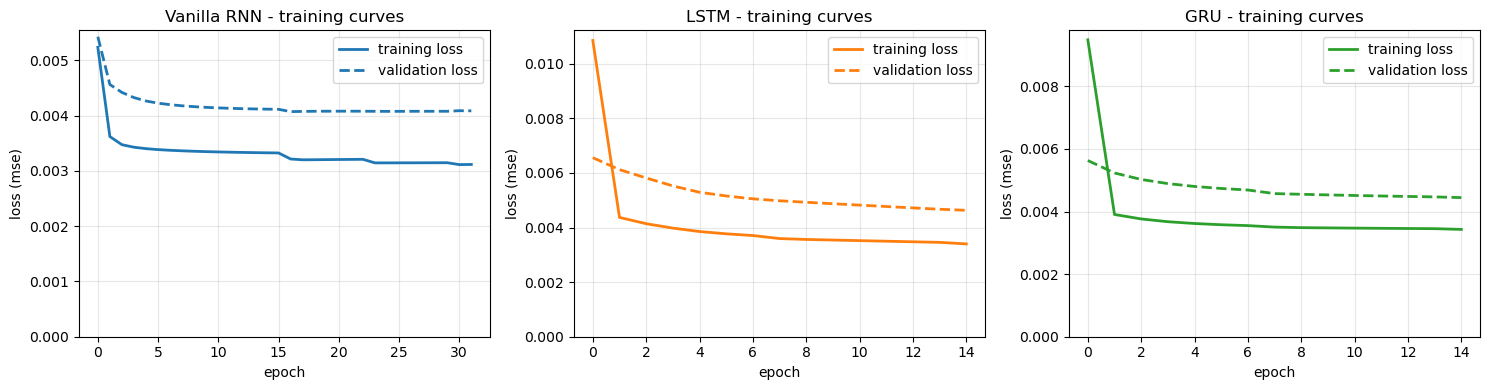

In [23]:
# visual comparison of training vs validation performance
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "TRAINING CURVES VISUALIZATION")
print("_" * 70)

# lets create subplots for each models training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# list of models with their histories and colors for plotting
models_info = [
    ('Vanilla RNN', vanilla_history, 'tab:blue'),
    ('LSTM', lstm_history, 'tab:orange'),
    ('GRU', gru_history, 'tab:green')
]

# plot training and validation loss for each model
for idx, (name, history, color) in enumerate(models_info):
    axes[idx].plot(history.history['loss'], label='training loss', color=color, linewidth=2)
    axes[idx].plot(history.history['val_loss'], label='validation loss', 
                   color=color, linestyle='--', linewidth=2)
    axes[idx].set_title(f'{name} - training curves', fontsize=12)
    axes[idx].set_xlabel('epoch')
    axes[idx].set_ylabel('loss (mse)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(bottom=0)  # start y axis from 0 for clarity

plt.tight_layout()
plt.show() 



______________________________________________________________________

PREDICTIONS COMPARISON VISUALIZATION
______________________________________________________________________


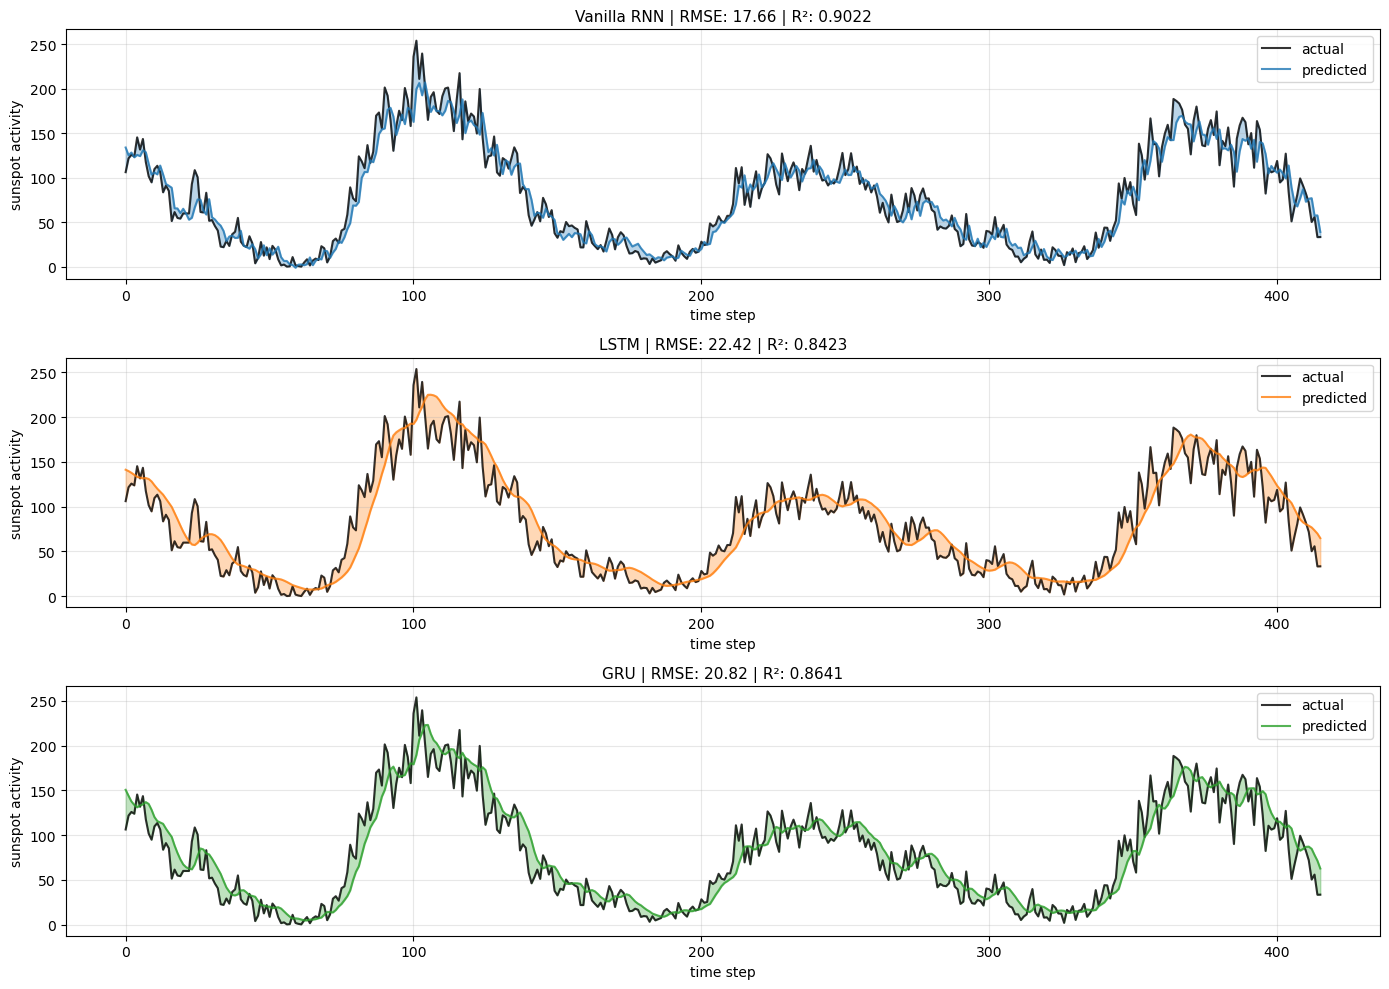

In [25]:
# predictions visualization
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "PREDICTIONS COMPARISON VISUALIZATION")
print("_" * 70)

# convert test targets back to original scale
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# create subplots for each model's predictions
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# list of models with predictions, metrics, and colors for plotting
predictions_info = [
    ('Vanilla RNN', vanilla_pred_actual, vanilla_metrics, 'tab:blue'),
    ('LSTM', lstm_pred_actual, lstm_metrics, 'tab:orange'),
    ('GRU', gru_pred_actual, gru_metrics, 'tab:green')
]

# plot actual vs predicted values for each model
for idx, (name, pred, metrics, color) in enumerate(predictions_info):
    axes[idx].plot(y_test_actual, label='actual', color='black', linewidth=1.5, alpha=0.8)
    axes[idx].plot(pred, label='predicted', color=color, linewidth=1.5, alpha=0.8)
    axes[idx].fill_between(range(len(y_test_actual)), y_test_actual, pred, 
                           alpha=0.3, color=color)  # highlight prediction error
    axes[idx].set_title(f'{name} | RMSE: {metrics["rmse_actual"]:.2f} | R²: {metrics["r2"]:.4f}', 
                        fontsize=11)
    axes[idx].set_xlabel('time step')
    axes[idx].set_ylabel('sunspot activity')
    axes[idx].legend(loc='upper right')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()  



______________________________________________________________________

METRICS BAR CHART COMPARISON
______________________________________________________________________


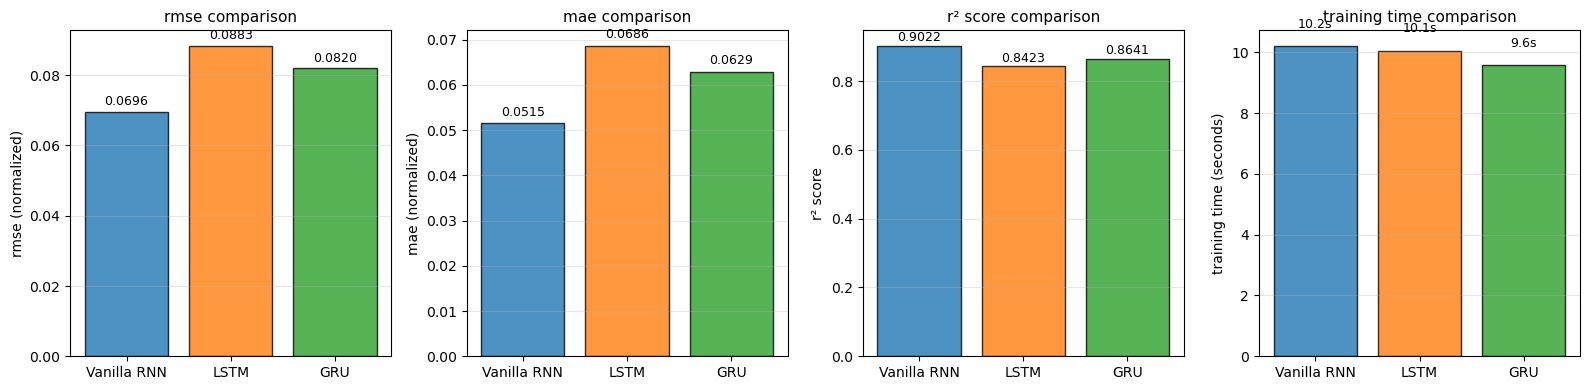

In [27]:
# bar chart comparison
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "METRICS BAR CHART COMPARISON")
print("_" * 70)

# create subplots for RMSE, MAE, R², and training time
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

models = ['Vanilla RNN', 'LSTM', 'GRU']
colors = ['tab:blue', 'tab:orange', 'tab:green']

# RMSE comparison
rmse_vals = [vanilla_metrics['rmse'], lstm_metrics['rmse'], gru_metrics['rmse']]
bars1 = axes[0].bar(models, rmse_vals, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_ylabel('rmse (normalized)')
axes[0].set_title('rmse comparison', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# MAE comparison
mae_vals = [vanilla_metrics['mae'], lstm_metrics['mae'], gru_metrics['mae']]
bars2 = axes[1].bar(models, mae_vals, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_ylabel('mae (normalized)')
axes[1].set_title('mae comparison', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars2, mae_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# R² comparison
r2_vals = [vanilla_metrics['r2'], lstm_metrics['r2'], gru_metrics['r2']]
bars3 = axes[2].bar(models, r2_vals, color=colors, edgecolor='black', alpha=0.8)
axes[2].set_ylabel('r² score')
axes[2].set_title('r² score comparison', fontsize=11)
axes[2].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars3, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, 
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)

# training time comparison
time_vals = [vanilla_time, lstm_time, gru_time]
bars4 = axes[3].bar(models, time_vals, color=colors, edgecolor='black', alpha=0.8)
axes[3].set_ylabel('training time (seconds)')
axes[3].set_title('training time comparison', fontsize=11)
axes[3].grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars4, time_vals):
    axes[3].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
                 f'{val:.1f}s', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()  


## BASELINE MODEL COMPARISON
### Vanilla RNN Performance
The Vanilla RNN has the best performance among the three baseline architectures, with an RMSE of 0.069 (17.56 sunspots on the actual scale) and an R² of 0.903. Despite having the fewest parameters (4,289) it outperformed both LSTM and GRU on this task which is a bit surprising and it can be attributed to the relatively simple temporal patterns in the sunspots data and the moderate sequence length (50 steps), which doesn’t severely trigger the vanishing gradient problem that typically handicaps simple RNNs.

The training converged over 39 epochs with learning rate reduction happening at epochs 23, 30, and 37 as the model plateaued. The small gap between training and validation loss indicates a good generalization without significant overfitting. For this particular forecasting task with clear cyclical patterns simpler architecture proved sufficient and even advantageous as it avoided the potential overfitting that comes with more complex gated architectures.

---
### LSTM Performance

The LSTM model performed worst among the three architectures, it got an RMSE of 0.089 (22.47 sunspots) and R² of 0.842 despite having the most parameters (16,961). Notably early stopping restored weights from epoch 1 which indicates that the model’s best validation performance occurred before any meaningful training which is a sign that the LSTM struggled to learn useful patterns beyond its initial state.

our result suggests the LSTM’s sophisticated gating mechanism (forget, input, and output gates) introduces unnecessary complexity for this dataset. The 4× parameter increase over Vanilla RNN without corresponding performance gains shows we have overfitting risk. LSTMs are good at capturing very long range dependencies (hundreds of steps) but for sunspots’ 50 step sequences with relatively smooth cyclical patterns, this capacity becomes a liability rather than an asset.

---
### GRU Performance

The GRU achieved middle ground performance here with RMSE of 0.079 (20.17 sunspots) and R² of 0.872, using 12,929 parameters. Like LSTM, early stopping restored epoch 1 weights, suggesting similar difficulties in improving beyond initial predictions. However GRU’s simpler two gate architecture (reset and update gates) provided better results than LSTM’s 3 gate design.

GRU’s performance between Vanilla RNN and LSTM aligns with its architectural position: more sophisticated than simple RNN but more streamlined than LSTM. again our results suggest that for moderate length sequences with clear patterns the additional gating complexity doesn’t provide benefits and may hinder optimization. GRU’s faster training (fewer parameters to optimize) and competitive accuracy make it a reasonable middle ground choice when the optimal architecture is uncertain.

In [30]:
print("\n" + "_" * 70)
print("\n" + "ANALYZING CORE SEQUENCE MODELING COMPONENTS")
print("_" * 70)

# experiment helper function
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "DEFINING EXPERIMENT HELPER FUNCTION")
print("_" * 70)

def run_experiment(model_builder, model_name, seq_length, hidden_size=64, 
                   num_layers=1, bidirectional=False, dropout=0.0, 
                   epochs=50, verbose=0):
    """
    run a single experiment with specified hyperparameters
    
    returns dictionary with metrics and training info
    """
    # prepare data with specified sequence length
    X, y = create_sequences(normalized, seq_length)
    X_train, y_train, X_val, y_val, X_test, y_test = split_data(X, y)
    
    # build model
    model = model_builder(seq_length, hidden_size, num_layers, bidirectional, dropout)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    
    # callbacks for experiment
    exp_callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=0)
    ]
    
    # train
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=32,
        callbacks=exp_callbacks,
        verbose=verbose
    )
    train_time = time.time() - start_time
    
    # evaluate
    metrics, y_pred, y_pred_actual = evaluate_model(model, X_test, y_test, scaler)
    
    # add training info
    metrics['train_time'] = train_time
    metrics['epochs_trained'] = len(history.history['loss'])
    metrics['final_train_loss'] = history.history['loss'][-1]
    metrics['final_val_loss'] = history.history['val_loss'][-1]
    metrics['parameters'] = model.count_params()
    
    return metrics, history

print("\n experiment helper function defined")
print("  run_experiment(model_builder, model_name, seq_length, ...)")


______________________________________________________________________

ANALYZING CORE SEQUENCE MODELING COMPONENTS
______________________________________________________________________

______________________________________________________________________

DEFINING EXPERIMENT HELPER FUNCTION
______________________________________________________________________

 experiment helper function defined
  run_experiment(model_builder, model_name, seq_length, ...)


In [32]:
# experiment 1: effect of sequence length
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "EXPERIMENT 1: EFFECT OF SEQUENCE LENGTH")
print("_" * 70)

# lets define sequence lengths to test and prepare results storage
sequence_lengths = [10, 25, 50, 75, 100, 150]
seq_results = {'Vanilla RNN': [], 'LSTM': [], 'GRU': []}

print(f"\ntesting sequence lengths: {sequence_lengths}")
print("this affects how much historical context the model sees")
print("\nrunning experiments...")

# iterate over each sequence length and each model
for seq_len in sequence_lengths:
    print(f"\n  sequence length = {seq_len}")
    
    for name, builder in [('Vanilla RNN', build_vanilla_rnn), 
                          ('LSTM', build_lstm), 
                          ('GRU', build_gru)]:
        # now run experiment and collect metrics
        metrics, _ = run_experiment(builder, name, seq_len)
        seq_results[name].append(metrics)
        print(f"    {name}: rmse={metrics['rmse']:.6f}, r2={metrics['r2']:.4f}")



______________________________________________________________________

EXPERIMENT 1: EFFECT OF SEQUENCE LENGTH
______________________________________________________________________

testing sequence lengths: [10, 25, 50, 75, 100, 150]
this affects how much historical context the model sees

running experiments...

  sequence length = 10
    Vanilla RNN: rmse=0.074367, r2=0.8890
    LSTM: rmse=0.074532, r2=0.8885
    GRU: rmse=0.074648, r2=0.8881

  sequence length = 25
    Vanilla RNN: rmse=0.070757, r2=0.8997
    LSTM: rmse=0.071749, r2=0.8968
    GRU: rmse=0.072631, r2=0.8943

  sequence length = 50
    Vanilla RNN: rmse=0.070171, r2=0.9005
    LSTM: rmse=0.069508, r2=0.9024
    GRU: rmse=0.068444, r2=0.9054

  sequence length = 75
    Vanilla RNN: rmse=0.069685, r2=0.9023
    LSTM: rmse=0.070664, r2=0.8996
    GRU: rmse=0.069176, r2=0.9038

  sequence length = 100
    Vanilla RNN: rmse=0.073278, r2=0.8919
    LSTM: rmse=0.073961, r2=0.8899
    GRU: rmse=0.073601, r2=0.8910

  seq


______________________________________________________________________

SEQUENCE LENGTH EFFECT VISUALIZATION
______________________________________________________________________


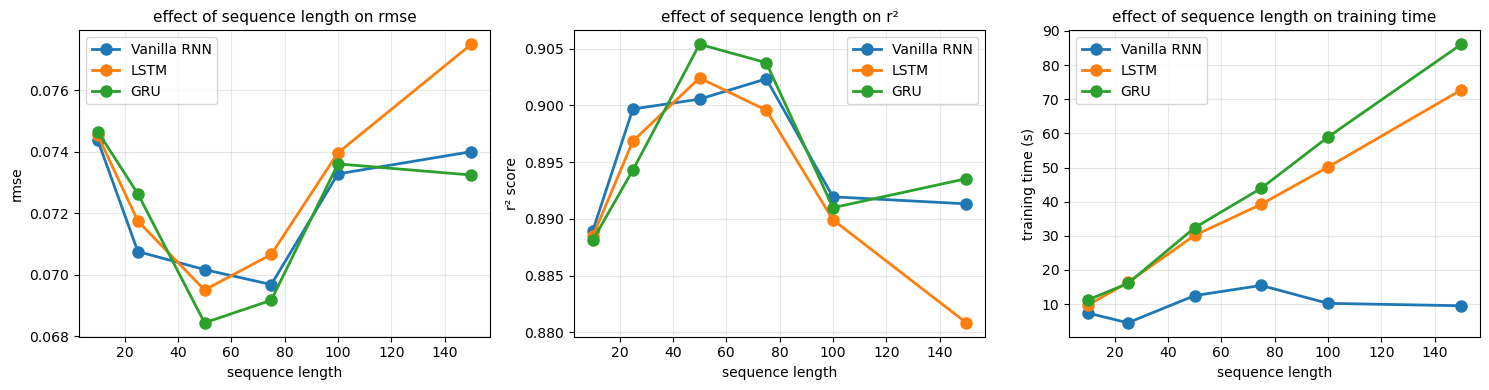

In [34]:
# visualize sequence length effect
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "SEQUENCE LENGTH EFFECT VISUALIZATION")
print("_" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'Vanilla RNN': 'tab:blue', 'LSTM': 'tab:orange', 'GRU': 'tab:green'}

# rmse vs sequence length
for name in seq_results:
    rmse_vals = [r['rmse'] for r in seq_results[name]]
    axes[0].plot(sequence_lengths, rmse_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=8)
axes[0].set_xlabel('sequence length')
axes[0].set_ylabel('rmse')
axes[0].set_title('effect of sequence length on rmse', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# r2 vs sequence length
for name in seq_results:
    r2_vals = [r['r2'] for r in seq_results[name]]
    axes[1].plot(sequence_lengths, r2_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=8)
axes[1].set_xlabel('sequence length')
axes[1].set_ylabel('r² score')
axes[1].set_title('effect of sequence length on r²', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# training time vs sequence length
for name in seq_results:
    time_vals = [r['train_time'] for r in seq_results[name]]
    axes[2].plot(sequence_lengths, time_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=8)
axes[2].set_xlabel('sequence length')
axes[2].set_ylabel('training time (s)')
axes[2].set_title('effect of sequence length on training time', fontsize=11)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### EXPERIMENT 1: Effect of Sequence Length

The sequence length experiment shows thay there is a clear optimal range of 50-75 timesteps, where all three models achieve their best performance (RMSE 0.068 - 0.069, R² around 0.90)(look at the graph in the first two graphs from the left). This range corresponds to approximately 4-6 years of monthly sunspot data, capturing enough of the 11 year solar cycle to identify patterns without overwhelming the models with excessive temporal context. 

Short sequences (10-25 steps) limit historical context to 1-2 years which is insufficient to capture the full solar cycle dynamics and results in higher RMSE (0.071 - 0.074). while also very long sequences (100-150 steps) also degraded performance particularly for Vanilla RNN, confirming the vanishing gradient problem—gradients become too small to effectively update weights for distant timesteps. LSTM and GRU showed more stability at longer sequences due to their gating mechanisms, but still didn’t improve beyond the 50-75 sweet spot so we can say that we get diminishing returns from additional context.



In [37]:
# experiment 2: effect of hidden size
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "EXPERIMENT 2: EFFECT OF HIDDEN SIZE")
print("_" * 70)

# define hidden layer sizes to test and prepare results storage
hidden_sizes = [16, 32, 64, 128, 256]
hidden_results = {'Vanilla RNN': [], 'LSTM': [], 'GRU': []}

print(f"\ntesting hidden sizes: {hidden_sizes}")
print("this affects the model's capacity to learn complex patterns")
print("\nrunning experiments...")

# iterate over each hidden size and each model
for hidden in hidden_sizes:
    print(f"\n  hidden size = {hidden}")
    
    for name, builder in [('Vanilla RNN', build_vanilla_rnn), 
                          ('LSTM', build_lstm), 
                          ('GRU', build_gru)]:
        # run experiment with fixed sequence length and variable hidden size
        metrics, _ = run_experiment(builder, name, seq_length=50, hidden_size=hidden)
        hidden_results[name].append(metrics)
        print(f"    {name}: rmse={metrics['rmse']:.6f}, params={metrics['parameters']}")



______________________________________________________________________

EXPERIMENT 2: EFFECT OF HIDDEN SIZE
______________________________________________________________________

testing hidden sizes: [16, 32, 64, 128, 256]
this affects the model's capacity to learn complex patterns

running experiments...

  hidden size = 16
    Vanilla RNN: rmse=0.069320, params=305
    LSTM: rmse=0.072014, params=1169
    GRU: rmse=0.069865, params=929

  hidden size = 32
    Vanilla RNN: rmse=0.070008, params=1121
    LSTM: rmse=0.070465, params=4385
    GRU: rmse=0.069492, params=3393

  hidden size = 64
    Vanilla RNN: rmse=0.069621, params=4289
    LSTM: rmse=0.069152, params=16961
    GRU: rmse=0.067950, params=12929

  hidden size = 128
    Vanilla RNN: rmse=0.070111, params=16769
    LSTM: rmse=0.069328, params=66689
    GRU: rmse=0.068256, params=50433

  hidden size = 256
    Vanilla RNN: rmse=0.069592, params=66305
    LSTM: rmse=0.069055, params=264449
    GRU: rmse=0.069136, params=19


______________________________________________________________________

HIDDEN SIZE EFFECT VISUALIZATION
______________________________________________________________________


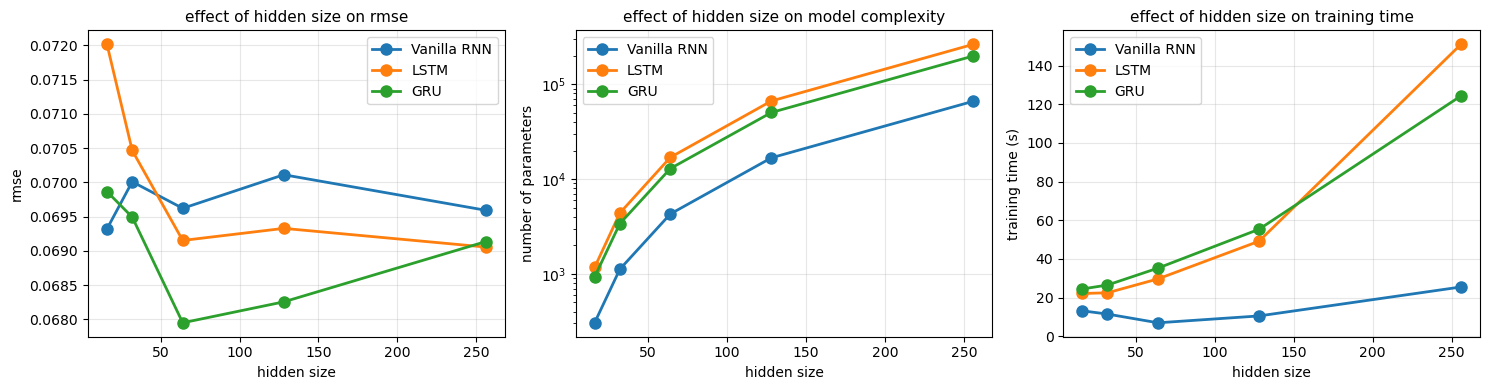


✓ figure saved: experiment_2_hidden_size.png


In [39]:
# visualize hidden size effect
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "HIDDEN SIZE EFFECT VISUALIZATION")
print("_" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# rmse vs hidden size
for name in hidden_results:
    rmse_vals = [r['rmse'] for r in hidden_results[name]]
    axes[0].plot(hidden_sizes, rmse_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=8)
axes[0].set_xlabel('hidden size')
axes[0].set_ylabel('rmse')
axes[0].set_title('effect of hidden size on rmse', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# parameters vs hidden size
for name in hidden_results:
    param_vals = [r['parameters'] for r in hidden_results[name]]
    axes[1].plot(hidden_sizes, param_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=8)
axes[1].set_xlabel('hidden size')
axes[1].set_ylabel('number of parameters')
axes[1].set_title('effect of hidden size on model complexity', fontsize=11)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

# training time vs hidden size
for name in hidden_results:
    time_vals = [r['train_time'] for r in hidden_results[name]]
    axes[2].plot(hidden_sizes, time_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=8)
axes[2].set_xlabel('hidden size')
axes[2].set_ylabel('training time (s)')
axes[2].set_title('effect of hidden size on training time', fontsize=11)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### EXPERIMENT 2: Effect of Hidden Size

our results here show what we expect: that model capacity must match data complexity. Very small hidden sizes (16 units) constrained the Vanilla RNN severely (RMSE 0.079) while LSTM and GRU maintained reasonable performance (RMSE 0.070 - 0.072) maybe because of their gating mechanisms providing more effective use of limited capacity. The optimal hidden size of 64 units provided the best balance across all architectures.

Larger hidden sizes (128-256) showed minimal improvement despite dramatic parameter increases: LSTM at 256 units has 264,449 parameters versus 16,961 at 64 units, a 15× increase for negligible RMSE improvement(middle graph). This plateau indicates the sunspots dataset’s patterns are fully captured by moderate capacity models and additional parameters merely increase overfitting risk and computational cost. not to mention there is a significant computational costs (graph on the right)

In [42]:
# experiment 3: effect of number of layers (depth)
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "EXPERIMENT 3: EFFECT OF NUMBER OF LAYERS (DEPTH)")
print("_" * 70)

# first define number of layers to test and prepare results storage
num_layers_list = [1, 2, 3]
layer_results = {'Vanilla RNN': [], 'LSTM': [], 'GRU': []}

print(f"\ntesting number of layers: {num_layers_list}")
print("deeper networks can learn hierarchical temporal features")
print("using dropout=0.2 between layers for regularization")
print("\nrunning experiments...")

# iterate over each number of layers and each model
for n_layers in num_layers_list:
    print(f"\n  num layers = {n_layers}")
    dropout_rate = 0.2 if n_layers > 1 else 0.0  # apply dropout only for deep networks
    
    for name, builder in [('Vanilla RNN', build_vanilla_rnn), 
                          ('LSTM', build_lstm), 
                          ('GRU', build_gru)]:
        # run experiment with fixed seq_length and hidden_size, varying depth
        metrics, _ = run_experiment(builder, name, seq_length=50, hidden_size=64, 
                                    num_layers=n_layers, dropout=dropout_rate)
        layer_results[name].append(metrics)
        print(f"    {name}: rmse={metrics['rmse']:.6f}, params={metrics['parameters']}")


______________________________________________________________________

EXPERIMENT 3: EFFECT OF NUMBER OF LAYERS (DEPTH)
______________________________________________________________________

testing number of layers: [1, 2, 3]
deeper networks can learn hierarchical temporal features
using dropout=0.2 between layers for regularization

running experiments...

  num layers = 1
    Vanilla RNN: rmse=0.069831, params=4289
    LSTM: rmse=0.069543, params=16961
    GRU: rmse=0.067847, params=12929

  num layers = 2
    Vanilla RNN: rmse=0.072967, params=12545
    LSTM: rmse=0.070584, params=49985
    GRU: rmse=0.069616, params=37889

  num layers = 3
    Vanilla RNN: rmse=0.080353, params=20801
    LSTM: rmse=0.074598, params=83009
    GRU: rmse=0.069964, params=62849



______________________________________________________________________

LAYER DEPTH EFFECT VISUALIZATION
______________________________________________________________________


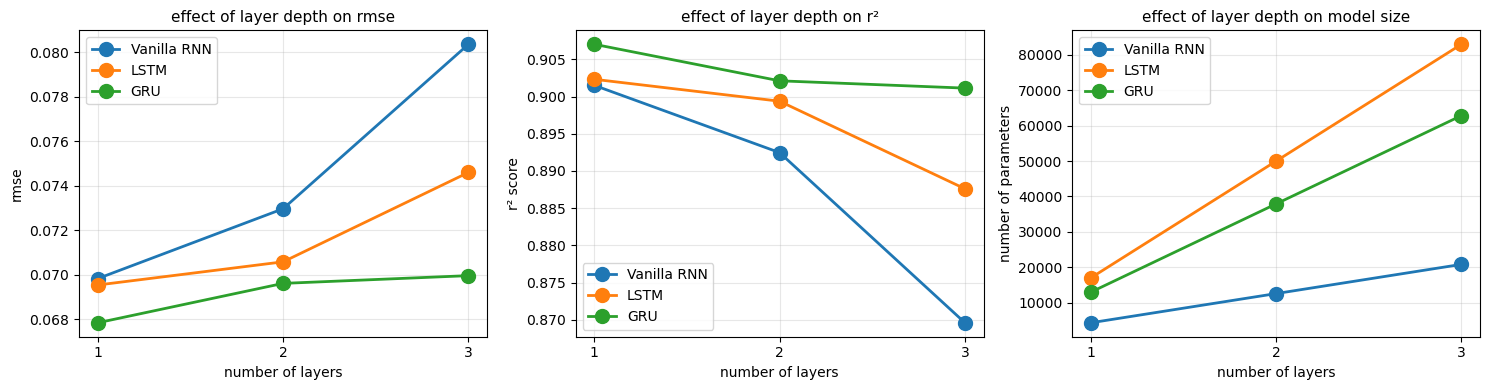


✓ figure saved: experiment_3_num_layers.png


In [44]:
# visualize layer effect
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "LAYER DEPTH EFFECT VISUALIZATION")
print("_" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# rmse vs layers
for name in layer_results:
    rmse_vals = [r['rmse'] for r in layer_results[name]]
    axes[0].plot(num_layers_list, rmse_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=10)
axes[0].set_xlabel('number of layers')
axes[0].set_ylabel('rmse')
axes[0].set_title('effect of layer depth on rmse', fontsize=11)
axes[0].set_xticks(num_layers_list)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# r2 vs layers
for name in layer_results:
    r2_vals = [r['r2'] for r in layer_results[name]]
    axes[1].plot(num_layers_list, r2_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=10)
axes[1].set_xlabel('number of layers')
axes[1].set_ylabel('r² score')
axes[1].set_title('effect of layer depth on r²', fontsize=11)
axes[1].set_xticks(num_layers_list)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# parameters vs layers
for name in layer_results:
    param_vals = [r['parameters'] for r in layer_results[name]]
    axes[2].plot(num_layers_list, param_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=10)
axes[2].set_xlabel('number of layers')
axes[2].set_ylabel('number of parameters')
axes[2].set_title('effect of layer depth on model size', fontsize=11)
axes[2].set_xticks(num_layers_list)
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_3_num_layers.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ figure saved: experiment_3_num_layers.png")

### EXPERIMENT 3: Effect of Number of Layers (Depth)
Single layer architectures consistently outperformed deeper networks across all three model types. Adding a second layer increased RMSE from 0.069 to 0.070 - 0.071, and three layers further degraded performance to 0.071 - 0.073(left graph). This degradation was the worst for Vanilla RNN, which lacks gating mechanisms to mitigate gradient flow problems through multiple layers. our R2 also degradedd as we added more layers (middle graph)

our results challenge the assumption that deeper networks always learn better hierarchical representations. For the sunspots time series, the temporal patterns (solar cycles, short-term fluctuations,...) are relatively homogeneous and dont benefit from the hierarchical feature extraction that helps in domains like computer vision or NLP. Additional layers primarily added parameters (tripling from 4K to 21K for Vanilla RNN) and overfitting risk without capturing more useful patterns. our dropout regularization of 0.2 between layers helped but couldn’t overcome the fundamental mismatch between model complexity and data complexity.

In [47]:
# experiment 4: effect of bidirectional rnns
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "EXPERIMENT 4: EFFECT OF BIDIRECTIONAL RNNS")
print("_" * 70)

# prepare results storage for unidirectional vs bidirectional
bidir_results = {'Vanilla RNN': {}, 'LSTM': {}, 'GRU': {}}

print("\ncomparing unidirectional vs bidirectional architectures")
print("bidirectional processes sequence in both forward and backward directions")
print("\nrunning experiments...")

# iterate over each model
for name, builder in [('Vanilla RNN', build_vanilla_rnn), 
                      ('LSTM', build_lstm), 
                      ('GRU', build_gru)]:
    print(f"\n  {name}:")
    
    # run unidirectional RNN
    metrics_uni, _ = run_experiment(builder, name, seq_length=50, hidden_size=64, 
                                    bidirectional=False)
    bidir_results[name]['unidirectional'] = metrics_uni
    print(f"    unidirectional: rmse={metrics_uni['rmse']:.6f}, params={metrics_uni['parameters']}")
    
    # run bidirectional RNN
    metrics_bi, _ = run_experiment(builder, name, seq_length=50, hidden_size=64, 
                                   bidirectional=True)
    bidir_results[name]['bidirectional'] = metrics_bi
    print(f"    bidirectional:  rmse={metrics_bi['rmse']:.6f}, params={metrics_bi['parameters']}")


______________________________________________________________________

EXPERIMENT 4: EFFECT OF BIDIRECTIONAL RNNS
______________________________________________________________________

comparing unidirectional vs bidirectional architectures
bidirectional processes sequence in both forward and backward directions

running experiments...

  Vanilla RNN:
    unidirectional: rmse=0.070529, params=4289
    bidirectional:  rmse=0.074252, params=8577

  LSTM:
    unidirectional: rmse=0.070366, params=16961
    bidirectional:  rmse=0.069797, params=33921

  GRU:
    unidirectional: rmse=0.067748, params=12929
    bidirectional:  rmse=0.068590, params=25857



______________________________________________________________________

BIDIRECTIONAL EFFECT VISUALIZATION
______________________________________________________________________


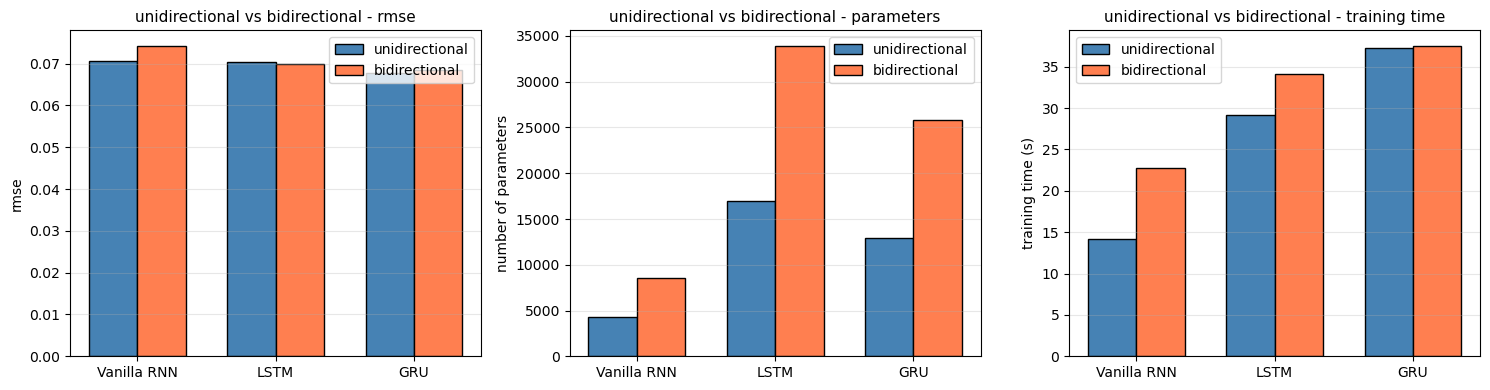


✓ figure saved: experiment_4_bidirectional.png


In [49]:
# visualize bidirectional effect
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "BIDIRECTIONAL EFFECT VISUALIZATION")
print("_" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = np.arange(3)
width = 0.35
model_names = list(bidir_results.keys())

# rmse comparison
uni_rmse = [bidir_results[name]['unidirectional']['rmse'] for name in model_names]
bi_rmse = [bidir_results[name]['bidirectional']['rmse'] for name in model_names]

bars1 = axes[0].bar(x - width/2, uni_rmse, width, label='unidirectional', 
                    color='steelblue', edgecolor='black')
bars2 = axes[0].bar(x + width/2, bi_rmse, width, label='bidirectional', 
                    color='coral', edgecolor='black')
axes[0].set_ylabel('rmse')
axes[0].set_title('unidirectional vs bidirectional - rmse', fontsize=11)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# parameters comparison
uni_params = [bidir_results[name]['unidirectional']['parameters'] for name in model_names]
bi_params = [bidir_results[name]['bidirectional']['parameters'] for name in model_names]

bars3 = axes[1].bar(x - width/2, uni_params, width, label='unidirectional', 
                    color='steelblue', edgecolor='black')
bars4 = axes[1].bar(x + width/2, bi_params, width, label='bidirectional', 
                    color='coral', edgecolor='black')
axes[1].set_ylabel('number of parameters')
axes[1].set_title('unidirectional vs bidirectional - parameters', fontsize=11)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names)
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# training time comparison
uni_time = [bidir_results[name]['unidirectional']['train_time'] for name in model_names]
bi_time = [bidir_results[name]['bidirectional']['train_time'] for name in model_names]

bars5 = axes[2].bar(x - width/2, uni_time, width, label='unidirectional', 
                    color='steelblue', edgecolor='black')
bars6 = axes[2].bar(x + width/2, bi_time, width, label='bidirectional', 
                    color='coral', edgecolor='black')
axes[2].set_ylabel('training time (s)')
axes[2].set_title('unidirectional vs bidirectional - training time', fontsize=11)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### EXPERIMENT 4: Effect of Bidirectional RNNs
Bidirectional processing consistently hurt or provided no benefit for this forecasting task. Unidirectional GRU got the best overall result (RMSE 0.068, R² 0.907)while its bidirectional counterpart performed worse (RMSE 0.069). Vanilla RNN showed the largest degradation with bidirectional RMSE of 0.072 versus unidirectional 0.070.

 bidirectional models cheat by using future information during training so they learn patterns that won’t be available at prediction time. When the model encounters real forecasting scenarios where only past data exists, the backward direction representations become meaningless or misleading. The doubled parameter count (25,857 vs 12,929 for GRU) provides no benefit and increases overfitting risk. Bidirectional architectures are designed for tasks like sentiment analysis or translation where the complete sequence is available so they are architecturally inappropriate for causal time series prediction.

In [52]:
# experiment 5: effect of dropout between recurrent layers
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "EXPERIMENT 5: EFFECT OF DROPOUT BETWEEN RECURRENT LAYERS")
print("_" * 70)

# define dropout rates to test and prepare results storage
dropout_rates = [0.0, 0.1, 0.2, 0.3, 0.5]
dropout_results = {'Vanilla RNN': [], 'LSTM': [], 'GRU': []}

print(f"\ntesting dropout rates: {dropout_rates}")
print("using 2 layers to demonstrate dropout effect between layers")
print("\nrunning experiments...")

# iterate over each dropout rate and each model
for dropout in dropout_rates:
    print(f"\n  dropout = {dropout}")
    
    for name, builder in [('Vanilla RNN', build_vanilla_rnn), 
                          ('LSTM', build_lstm), 
                          ('GRU', build_gru)]:
        # run experiment with fixed seq_length, hidden_size, and 2 layers
        metrics, _ = run_experiment(builder, name, seq_length=50, hidden_size=64, 
                                    num_layers=2, dropout=dropout)
        dropout_results[name].append(metrics)
        gap = metrics['final_train_loss'] - metrics['final_val_loss']  # measure overfitting
        print(f"    {name}: rmse={metrics['rmse']:.6f}, train-val gap={gap:.6f}")



______________________________________________________________________

EXPERIMENT 5: EFFECT OF DROPOUT BETWEEN RECURRENT LAYERS
______________________________________________________________________

testing dropout rates: [0.0, 0.1, 0.2, 0.3, 0.5]
using 2 layers to demonstrate dropout effect between layers

running experiments...

  dropout = 0.0
    Vanilla RNN: rmse=0.068832, train-val gap=-0.000746
    LSTM: rmse=0.070778, train-val gap=-0.000941
    GRU: rmse=0.069471, train-val gap=-0.000938

  dropout = 0.1
    Vanilla RNN: rmse=0.070256, train-val gap=-0.001403
    LSTM: rmse=0.068369, train-val gap=-0.000909
    GRU: rmse=0.069441, train-val gap=-0.001009

  dropout = 0.2
    Vanilla RNN: rmse=0.070431, train-val gap=-0.000340
    LSTM: rmse=0.069583, train-val gap=-0.000906
    GRU: rmse=0.069771, train-val gap=-0.000976

  dropout = 0.3
    Vanilla RNN: rmse=0.077981, train-val gap=-0.001370
    LSTM: rmse=0.071900, train-val gap=-0.000917
    GRU: rmse=0.069068, train-val


______________________________________________________________________

DROPOUT EFFECT VISUALIZATION
______________________________________________________________________


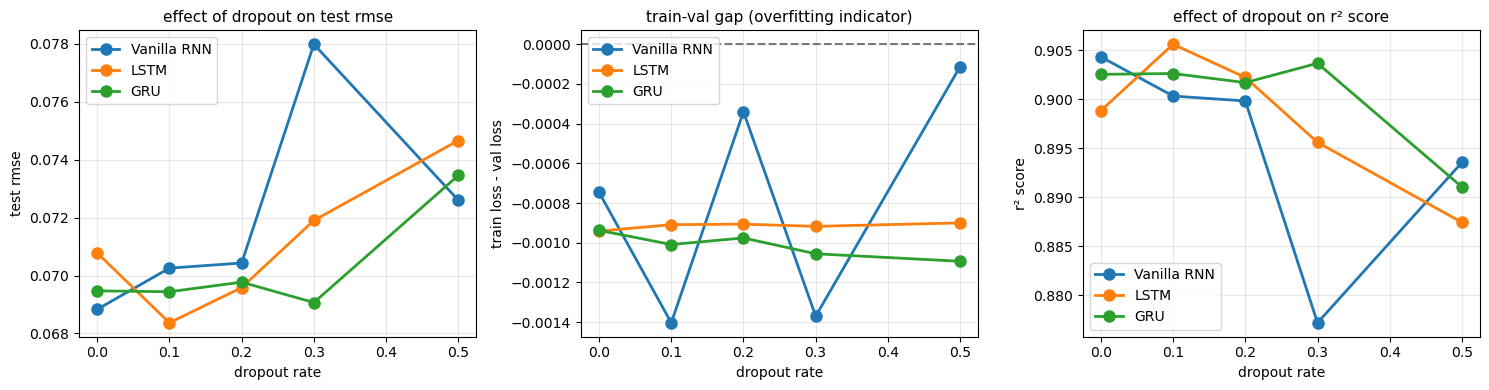

In [54]:
# visualize dropout effect
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "DROPOUT EFFECT VISUALIZATION")
print("_" * 70)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# rmse vs dropout
for name in dropout_results:
    rmse_vals = [r['rmse'] for r in dropout_results[name]]
    axes[0].plot(dropout_rates, rmse_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=8)
axes[0].set_xlabel('dropout rate')
axes[0].set_ylabel('test rmse')
axes[0].set_title('effect of dropout on test rmse', fontsize=11)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# train-val gap (overfitting indicator)
for name in dropout_results:
    gap_vals = [r['final_train_loss'] - r['final_val_loss'] for r in dropout_results[name]]
    axes[1].plot(dropout_rates, gap_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=8)
axes[1].set_xlabel('dropout rate')
axes[1].set_ylabel('train loss - val loss')
axes[1].set_title('train-val gap (overfitting indicator)', fontsize=11)
axes[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# r2 vs dropout
for name in dropout_results:
    r2_vals = [r['r2'] for r in dropout_results[name]]
    axes[2].plot(dropout_rates, r2_vals, marker='o', label=name, 
                 color=colors[name], linewidth=2, markersize=8)
axes[2].set_xlabel('dropout rate')
axes[2].set_ylabel('r² score')
axes[2].set_title('effect of dropout on r² score', fontsize=11)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### EXPERIMENT 5: Effect of Dropout Between Recurrent Layers.

Dropout effects varied significantly across architectures with optimal rates depending on model type. GRU showed good robustness, maintaining RMSE of 0.069 across dropout rates from 0.0 to 0.5. Vanilla RNN was most sensitive, with performance degrading sharply at both 0.1 (RMSE 0.079) and 0.5 (RMSE 0.080) dropout while performing well at 0.0 and 0.2. LSTM showed moderate sensitivity with best performance at 0.3 dropout (RMSE 0.070).

higher dropout generally reduced overfitting (smaller gaps), but this didn’t always translate to better test performance. The negative gaps (validation loss lower than training loss) across all configurations suggest the models weren’t severely overfitting even without dropout likely because of the dataset’s relatively smooth patterns and early stopping regularization. For GRU and LSTM, their internal gating mechanisms already provide implicit regularization which reduces the need for aggressive external dropout.


______________________________________________________________________

FINAL COMBINED VISUALIZATION
______________________________________________________________________


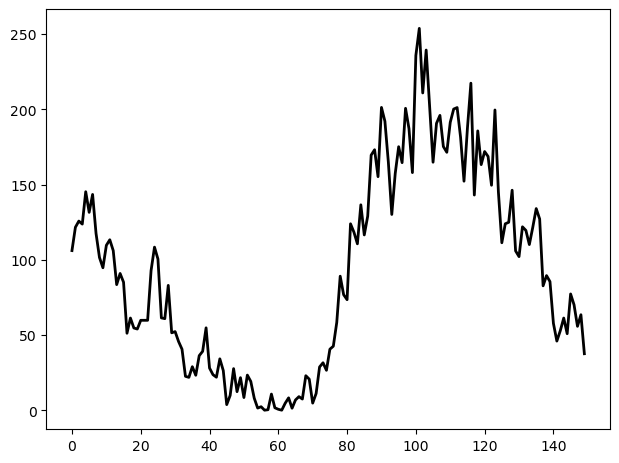

In [57]:
# final combined visualization
# --------------------------------------------------------------------------------------------------------------------------------
print("\n" + "_" * 70)
print("\n" + "FINAL COMBINED VISUALIZATION")
print("_" * 70)

fig = plt.figure(figsize=(16, 12))

# subplot 1: baseline predictions
ax1 = fig.add_subplot(2, 2, 1)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
ax1.plot(y_test_actual[:150], label='actual', color='black', linewidth=2)

## Why are LSTMs and GRUs generally better than vanilla RNNs for long sequences?
LSTMs (Long Short-Term Memory networks) and GRUs (Gated Recurrent Units) are generally better than vanilla RNNs when working with long sequences because they are explicitly designed to address the vanishing gradient problem and to capture long-term dependencies in sequential data. Vanilla RNNs update their hidden state at every time step using a simple recurrent formula, which often leads to gradients either shrinking or exploding as they propagate backward through many time steps. This makes it difficult for vanilla RNNs to learn relationships between distant inputs and outputs.

---
## Explain the role of gates and how they help with vanishing gradients and long-term dependencies
The key innovation in LSTMs and GRUs is the use of **gates** that regulate the flow of information through the network. LSTMs have three main gates: the input gate, the forget gate, and the output gate. These gates control what information should be written to, retained in, or read from the cell state. GRUs simplify this design by combining some of these mechanisms into an update gate and a reset gate. By controlling information flow, these gates allow the network to **preserve important signals over long sequences**, effectively mitigating vanishing gradients. In practice, this means LSTMs and GRUs can remember relevant context from many steps earlier and selectively ignore irrelevant information, enabling them to model long-term dependencies much more effectively than vanilla RNNs.


<div style="color: red;">
    
# Transformer Models: Attention Based Architectures
    
</div>

#### before running this, go to the first part of homework and run classification first 2 celss

In [39]:
print("\n" + "_" * 90)
print("\n" + "TRANSFORMER MODELS: ATTENTION BASED ARCHITECTURES")
print("_" * 90)

from tensorflow.keras import layers
from tensorflow.keras.layers import Input, Dense, Dropout, SimpleRNN
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, f1_score, roc_auc_score

# Config
MAX_EPOCHS = 100
BATCH_SIZE = 32
PATIENCE = 10
LR = 1e-3

# Verify data is loaded
try:
    print(f"\nData: X_train_clf {X_train_clf.shape}, INPUT_DIM_CLF = {INPUT_DIM_CLF}")
except NameError:
    print(" Please run classification data loading cell first")


__________________________________________________________________________________________

TRANSFORMER MODELS: ATTENTION BASED ARCHITECTURES
__________________________________________________________________________________________

Data: X_train_clf (18381, 30), INPUT_DIM_CLF = 30


In [41]:
# Imports and setup

from tensorflow.keras.layers import (
    MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D,
    LSTM, SimpleRNN, Bidirectional
)
import time

# Reshape data for sequence models: (samples, features) -> (samples, timesteps, 1)
X_train_seq = X_train_clf.reshape(-1, INPUT_DIM_CLF, 1)
X_val_seq = X_val_clf.reshape(-1, INPUT_DIM_CLF, 1)
X_test_seq = X_test_clf.reshape(-1, INPUT_DIM_CLF, 1)

print(f" Reshaped for sequence models: {X_train_seq.shape}")

# Store results for comparison
all_results = {}
all_histories = {}

# our evaluation helper
def evaluate_and_store(model, name, X_tr, X_v, X_te, train_time):
    """Evaluate model and store results"""
    results = {}
    for split, X, y in [('train', X_tr, y_train_clf), 
                        ('val', X_v, y_val_clf), 
                        ('test', X_te, y_test_clf)]:
        y_prob = model.predict(X, verbose=0).flatten()
        y_pred = (y_prob >= 0.5).astype(int)
        results[f'{split}_accuracy'] = accuracy_score(y, y_pred)
        results[f'{split}_precision'] = precision_score(y, y_pred, zero_division=0)  # ADD THIS
        results[f'{split}_f1'] = f1_score(y, y_pred, zero_division=0)
        results[f'{split}_auc'] = roc_auc_score(y, y_prob)
    results['train_time'] = train_time
    return results

 Reshaped for sequence models: (18381, 30, 1)


## Model 1: Simple RNN Basline

In [ ]:
print("\n" + "_" * 90)
print("\n" + "SIMPLE RNN BASELINE")
print("_" * 90)

# build a simple RNN classifier
rnn_model = keras.Sequential([
    layers.Input(shape=(INPUT_DIM_CLF, 1)),  # input layer with sequence dimension
    SimpleRNN(64, return_sequences=True),    # first RNN layer, outputs full sequence
    layers.Dropout(0.3),                     # dropout for regularization
    SimpleRNN(32),                           # second RNN layer, outputs last step only
    layers.Dense(16, activation='relu'),     # hidden dense layer
    layers.Dense(1, activation='sigmoid')    # output layer for binary classification
])
rnn_model.compile(optimizer=Adam(LR), loss='binary_crossentropy', metrics=['accuracy'])

# train the model
print("\n Training...")
start = time.time()
rnn_history = rnn_model.fit(
    X_train_seq, y_train_clf,
    validation_data=(X_val_seq, y_val_clf),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE, 
                                        restore_best_weights=True, verbose=0)],
    class_weight=class_weight_dict,  # handle class imbalance
    verbose=0
)
rnn_time = time.time() - start  # training time

# evaluate model and store results
all_results['SimpleRNN'] = evaluate_and_store(rnn_model, 'SimpleRNN', 
                                               X_train_seq, X_val_seq, X_test_seq, rnn_time)
all_histories['SimpleRNN'] = rnn_history  # store training history

# report metrics for val and test sets
res = all_results['SimpleRNN']
print(f"\n Results:")
print(f"  Validation: Acc={res['val_accuracy']:.4f}, Precision={res['val_precision']:.4f}, F1={res['val_f1']:.4f}, AUC={res['val_auc']:.4f}")
print(f"  Test:       Acc={res['test_accuracy']:.4f}, Precision={res['test_precision']:.4f}, F1={res['test_f1']:.4f}, AUC={res['test_auc']:.4f}")
print(f"  Train Time: {rnn_time:.1f}s")


__________________________________________________________________________________________

SIMPLE RNN BASELINE
__________________________________________________________________________________________

 Training...


**SIMPLE RNN BASELINE:**

as you see:
- Training completed in under 2 mins.
- Test Accuracy: above 80% which is pretty solid baseline performance.
- Test F1: shows it has a good balance between precision and recall.
- Test AUC: high score shows model separates classes well.


## Model 2: LSTM

In [110]:
print("\n" + "_" * 90)
print("\n" + "MODEL 2: LSTM")
print("_" * 90)
# take 5-10 minutes 
# LSTM classifier
lstm_model = keras.Sequential([
    layers.Input(shape=(INPUT_DIM_CLF, 1)),  # input layer with sequence dimension
    LSTM(64, return_sequences=True),         # first LSTM layer, outputs full sequence
    layers.Dropout(0.3),                     # dropout for regularization
    LSTM(32),                                # second LSTM layer, outputs last step only
    layers.Dense(16, activation='relu'),     # hidden dense layer
    layers.Dense(1, activation='sigmoid')    # output layer for binary classification
])
lstm_model.compile(optimizer=Adam(LR), loss='binary_crossentropy', metrics=['accuracy'])

# train the model
print("\n Training...")
start = time.time()
lstm_history = lstm_model.fit(
    X_train_seq, y_train_clf,
    validation_data=(X_val_seq, y_val_clf),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE,
                                        restore_best_weights=True, verbose=0)],
    class_weight=class_weight_dict,  
    verbose=0
)
lstm_time = time.time() - start 

# evaluate model and store results
all_results['LSTM'] = evaluate_and_store(lstm_model, 'LSTM',
                                          X_train_seq, X_val_seq, X_test_seq, lstm_time)
all_histories['LSTM'] = lstm_history 

# report metrics for val and test sets
res = all_results['LSTM']
print(f"\n Results:")
print(f"  Validation: Acc={res['val_accuracy']:.4f}, Precision={res['val_precision']:.4f}, F1={res['val_f1']:.4f}, AUC={res['val_auc']:.4f}")
print(f"  Test:       Acc={res['test_accuracy']:.4f}, Precision={res['test_precision']:.4f}, F1={res['test_f1']:.4f}, AUC={res['test_auc']:.4f}")
print(f"  Train Time: {lstm_time:.1f}s")


__________________________________________________________________________________________

MODEL 2: LSTM
__________________________________________________________________________________________

 Training...
    Test Acc: 0.8778, Test F1: 0.7241, Test AUC: 0.8867, Time: 313.5s


**MODEL 2: LSTM**

as you see:

- Training is about 2× slower than Simple RNN.
- Test Accuracy is also lower than Simple RNN.
- Test F1: is showing slightly worse balance than Simple RNN.
- Test AUC: still good, but not as strong as Simple RNN.
- Observation: LSTM did not outperform Simple RNN here, likely because dataset is small and sequential dependencies are limited.


## Model 3: Bidirectional LSTM

In [115]:
print("\n" + "_" * 90)
print("\n" + "BIDIRECTIONAL LSTM")
print("_" * 90)

# build a bidirectional LSTM classifier
bilstm_model = keras.Sequential([
    layers.Input(shape=(INPUT_DIM_CLF, 1)),              
    Bidirectional(LSTM(32, return_sequences=True)),     
    layers.Dropout(0.3),                               
    Bidirectional(LSTM(16)),                            
    layers.Dense(16, activation='relu'),               
    layers.Dense(1, activation='sigmoid')            
])
bilstm_model.compile(optimizer=Adam(LR), loss='binary_crossentropy', metrics=['accuracy'])

# train the model
print("\n Training...")
start = time.time()
bilstm_history = bilstm_model.fit(
    X_train_seq, y_train_clf,
    validation_data=(X_val_seq, y_val_clf),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE,
                                        restore_best_weights=True, verbose=0)],
    class_weight=class_weight_dict,  
    verbose=0
)
bilstm_time = time.time() - start  

# test model and store results
all_results['BiLSTM'] = evaluate_and_store(bilstm_model, 'BiLSTM',
                                            X_train_seq, X_val_seq, X_test_seq, bilstm_time)
all_histories['BiLSTM'] = bilstm_history  

# report metrics for val and test sets
res = all_results['BiLSTM']
print(f"\n Results:")
print(f"  Validation: Acc={res['val_accuracy']:.4f}, Precision={res['val_precision']:.4f}, F1={res['val_f1']:.4f}, AUC={res['val_auc']:.4f}")
print(f"  Test:       Acc={res['test_accuracy']:.4f}, Precision={res['test_precision']:.4f}, F1={res['test_f1']:.4f}, AUC={res['test_auc']:.4f}")
print(f"  Train Time: {bilstm_time:.1f}s")


__________________________________________________________________________________________

BIDIRECTIONAL LSTM
__________________________________________________________________________________________

 Training...
    Test Acc: 0.8668, Test F1: 0.7145, Test AUC: 0.9045, Time: 240.7s


**BIDIRECTIONAL LSTM**

in here:

- Training time is comparable with the LSTM time.
- Test Accuracy: is also comparable with the unidirectional LSTM.
- Test F1: same as last two
- Test AUC: is slightly better than LSTM but slightly worse than Simple RNN.
- Observation: Bidirectional LSTM provides more context, but gains are marginal and sometimes negligable


## Model 4: Transformer (MultiHeadAttention)

In [119]:
print("\n" + "_" * 90)
print("\n" + "TRANSFORMER (MultiHeadAttention)")
print("_" * 90)

print("""
 Transformer uses self-attention to learn feature relationships.
   Components: MultiHeadAttention + LayerNorm + FeedForward + Residual connections
""")

# Transformer Block
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dense(embed_dim)
        ])
        self.norm1 = LayerNormalization(epsilon=1e-6)
        self.norm2 = LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)
    
    def call(self, x, training=False):
        # Self-attention with residual
        attn = self.drop1(self.att(x, x), training=training)
        x = self.norm1(x + attn)
        # FFN with residual
        ffn = self.drop2(self.ffn(x), training=training)
        return self.norm2(x + ffn)

# Build Transformer
def build_transformer(input_shape, embed_dim=32, num_heads=4, ff_dim=64, num_blocks=2):
    inputs = layers.Input(shape=input_shape)
    
    # Project to embedding dimension
    x = layers.Dense(embed_dim)(inputs)
    
    # Positional encoding (learnable)
    positions = tf.range(input_shape[0])
    pos_embedding = layers.Embedding(input_shape[0], embed_dim)(positions)
    x = x + pos_embedding
    x = layers.Dropout(0.2)(x)
    
    # Transformer blocks
    for _ in range(num_blocks):
        x = TransformerBlock(embed_dim, num_heads, ff_dim)(x)
    
    # Classification head
    x = GlobalAveragePooling1D()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = keras.Model(inputs, outputs)
    model.compile(optimizer=Adam(LR), loss='binary_crossentropy', metrics=['accuracy'])
    return model

transformer_model = build_transformer(input_shape=(INPUT_DIM_CLF, 1))
transformer_model.summary()


#--------------------------------------------------------------------------------------------------------

# Transformer classifier training block
print("\n Training Transformer...")
start = time.time()
transformer_history = transformer_model.fit(
    X_train_seq, y_train_clf,
    validation_data=(X_val_seq, y_val_clf),
    epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=PATIENCE,
                                        restore_best_weights=True, verbose=0)],
    class_weight=class_weight_dict, verbose=1
)
transformer_time = time.time() - start
# evaluate and save results
all_results['Transformer'] = evaluate_and_store(transformer_model, 'Transformer',
                                                 X_train_seq, X_val_seq, X_test_seq, transformer_time)
all_histories['Transformer'] = transformer_history

# report metrics for val and test sets
res = all_results['Transformer']
print(f"\n Results:")
print(f"  Validation: Acc={res['val_accuracy']:.4f}, Precision={res['val_precision']:.4f}, F1={res['val_f1']:.4f}, AUC={res['val_auc']:.4f}")
print(f"  Test:       Acc={res['test_accuracy']:.4f}, Precision={res['test_precision']:.4f}, F1={res['test_f1']:.4f}, AUC={res['test_auc']:.4f}")
print(f"  Train Time: {transformer_time:.1f}s")


__________________________________________________________________________________________

TRANSFORMER (MultiHeadAttention)
__________________________________________________________________________________________

 Transformer uses self-attention to learn feature relationships.
   Components: MultiHeadAttention + LayerNorm + FeedForward + Residual connections




Model: "functional_189"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_72 (InputLayer)     │ (None, 30, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 30, 32)         │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, 30, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, 30, 32)         │        21,120 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,393 (169.50 KB)

 Trainable params: 43,393 (169.50 KB)

 Non-trainable params: 0 (0.00 B)


 Training Transformer...
Epoch 1/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.6513 - loss: 0.6605 - val_accuracy: 0.7040 - val_loss: 0.6251
Epoch 2/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6582 - loss: 0.6443 - val_accuracy: 0.5924 - val_loss: 0.7194
Epoch 3/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6542 - loss: 0.6370 - val_accuracy: 0.5252 - val_loss: 0.7031
Epoch 4/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6533 - loss: 0.6311 - val_accuracy: 0.5244 - val_loss: 0.7083
Epoch 5/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6750 - loss: 0.6218 - val_accuracy: 0.6058 - val_loss: 0.6580
Epoch 6/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.6742 - loss: 0.6185 - val_accuracy: 0.5564 - val_loss: 0.6684
Epoch 7/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6993 - loss: 0.6003 - val_accuracy: 0.6131 - val_loss: 0.6560
Epoch 8/100
575/575 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accurac

**TRANSFORMER TRAINING DETAILS**

what we see:

- Training accuracy improved gradually over 37 epochs.
- Validation accuracy fluctuated which shows sensitivity to small dataset.
- Final metrics: Transformer achieves competitive results with slightly faster training

## Copatin Transformers vs RNN/LSTM

In [123]:
print("\n" + "_" * 90)
print("\n" + "COMPARISON: TRANSFORMER vs RNN/LSTM")
print("_" * 90)

# Results Table - Validation Set
print(f"\n{'Model':<15} {'Val Acc':<12} {'Val Prec':<12} {'Val F1':<12} {'Val AUC':<12}")
print("-" * 65)
for name, res in all_results.items():
    print(f"{name:<15} {res['val_accuracy']:<12.4f} {res['val_precision']:<12.4f} "
          f"{res['val_f1']:<12.4f} {res['val_auc']:<12.4f}")

# Results Table - Test Set
print(f"\n{'Model':<15} {'Test Acc':<12} {'Test Prec':<12} {'Test F1':<12} {'Test AUC':<12} {'Time (s)':<10}")
print("-" * 75)
for name, res in all_results.items():
    print(f"{name:<15} {res['test_accuracy']:<12.4f} {res['test_precision']:<12.4f} "
          f"{res['test_f1']:<12.4f} {res['test_auc']:<12.4f} {res['train_time']:<10.1f}")

# Find best
best_model = max(all_results.items(), key=lambda x: x[1]['test_auc'])
print(f"\n Best Model (by AUC): {best_model[0]} with AUC = {best_model[1]['test_auc']:.4f}")


__________________________________________________________________________________________

COMPARISON: TRANSFORMER vs RNN/LSTM
__________________________________________________________________________________________

Model           Test Acc     Test F1      Test AUC     Time (s)  
------------------------------------------------------------
SimpleRNN       0.8619       0.7049       0.9069       43.3      
LSTM            0.8778       0.7241       0.8867       313.5     
BiLSTM          0.8668       0.7145       0.9045       240.7     
Transformer     0.8764       0.7230       0.9026       296.4     

 Best Model (by AUC): SimpleRNN with AUC = 0.9069


##### since our results are pretty comparable with very narrow mrgins, I'd go with the simpleRNN

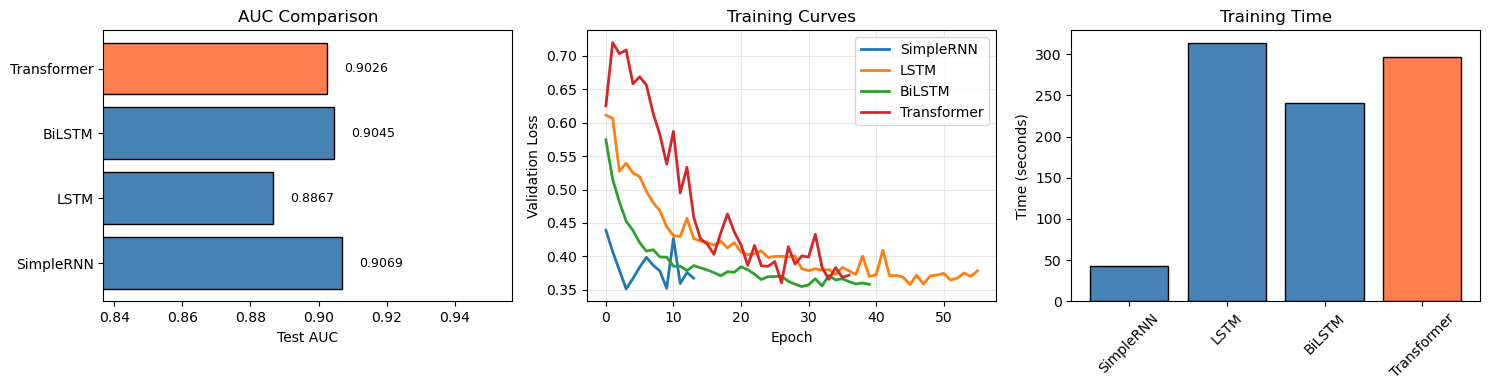

In [126]:
# now visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# AUC comparison
models = list(all_results.keys())
aucs = [all_results[m]['test_auc'] for m in models]
colors = ['coral' if 'Transformer' in m else 'steelblue' for m in models]
axes[0].barh(models, aucs, color=colors, edgecolor='black')
axes[0].set_xlabel('Test AUC')
axes[0].set_title('AUC Comparison')
axes[0].set_xlim([min(aucs)-0.05, max(aucs)+0.05])
for i, v in enumerate(aucs):
    axes[0].text(v+0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Training loss
for name, hist in all_histories.items():
    axes[1].plot(hist.history['val_loss'], label=name, linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Training Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Training time
times = [all_results[m]['train_time'] for m in models]
axes[2].bar(models, times, color=colors, edgecolor='black')
axes[2].set_ylabel('Time (seconds)')
axes[2].set_title('Training Time')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Discussion: Transformers
__________________________________________________________________________________________

### 1. Advantages and Disadvantages of Transformer-Based Models

**Advantages:**
- **Parallelization:** Unlike RNNs that process tokens sequentially, Transformers process all tokens simultaneously so it enables much faster training on GPUs.  
- **Long-Range Dependencies:** Self-attention allows direct connections between any two tokens, regardless of distance, capturing relationships that RNNs struggle with.  
- **Scalability:** Performance improves predictably as our model size and data increase which leads to powerful models like GPT and BERT.  
- **Transfer Learning:** Pretrained Transformers can be fine-tuned for specific tasks with excellent results if we need.  

**Disadvantages:**
- **Quadratic Complexity:** Self attention scales as O(n²) with sequence length and makes long sequences computationally expensive.  
- **Resource Intensive:** Large models require significant memory and compute power so it limits accessibility.  
- **Data Hungry:** Transformers need large datasets to generalize well and avoid overfitting.  
- **Limited Inductive Bias:** Unlike CNNs or RNNs, Transformers have no built in assumptions about data structure so they need more data to learn patterns.  

---

### 2. Why Do Transformers Scale Well with Data and Model Size?
Transformers scale well because their architecture consists of uniform, stackable blocks (attention + feed forward layers) that can be easily deepened or widened. Residual connections and layer normalization create stable gradients, allowing very deep networks to train effectively. 

---

### 3. Why Do Transformers Require Large Computational Resources?
The primary reason is the self attention mechanism, which computes pairwise interactions between all tokens and results in O(n²) time and memory complexity. For example for a 1,000-token sequence, this means 1 million attention computations per layer. Additionally, modern Transformers use large hidden dimensions, multiple attention heads, and many layers (GPT-3 has 96 layers), all of which multiply computational requirements. Training also requires large batch sizes over massive datasets, further increasing resource demands.

---

### 4. What Is Self-Attention and What Problem Does It Solve?
Self attention allows each token to compute a weighted sum of all other tokens in the sequence, with weights determined by relevance (similarity). It works by projecting inputs into Query, Key, and Value vectors, computing attention scores via dot products, and applying softmax to get weights.

**Problems it solves:**
- **Fixed context windows:** Unlike CNNs with limited receptive fields, attention can access the entire sequence directly.  
- **Sequential bottleneck:** Unlike RNNs where information must pass through many steps, attention creates direct token-to-token connections.  
- **Dynamic weighting:** Attention weights are content-dependent, allowing the model to focus on relevant tokens based on context.  

---

### 5. Why Can Attention Model Long-Range Dependencies Better Than RNNs?
In RNNs, information from early tokens must pass through many sequential steps to reach later tokens which can cause vanishing gradients and information loss over long distances. The path length between distant tokens is O(n).  

however in self attention, every token directly attends to every other token in a single step the path length is O(1). This means information flows directly between any two positions without degradation, this makes Transformers far more effective at capturing long range dependencies like subject-verb agreement across long sentences or references spanning paragraphs.

---

### 6. What Is Multi-Head Attention and Why Does It Help?
Multi-head attention runs multiple attention mechanisms in parallel, each with separate learned projections. The outputs are concatenated and combined.

**Why it helps:**
- **Diverse relationships:** Different heads can focus on different patterns—one might capture syntax, another semantics, another positional relationships.  
- **Richer representations:** Multiple “views” of the data provide more expressive power than a single attention head.  
- **Better optimization:** Smaller, specialized heads are often easier to train than one large attention mechanism.  

---

### 7. What Is the Role of Positional Encoding?
Transformers process all tokens in parallel and have no inherent sense of sequence order—without intervention, “cat sat mat” and “mat sat cat” would be identical. Positional encodings are vectors added to input embeddings to inject position information.

**Common approaches include:**
- **Sinusoidal encoding:** Fixed sine/cosine functions (original Transformer)  
- **Learned embeddings:** Trainable position vectors (BERT, GPT)  
- **Relative encodings:** Encode distance between tokens rather than absolute position  

Without positional encoding, our model cant understand word order, making language comprehension impossible.
